# First Implementation 


There is the pipeline
**camera.py**: builds the intrinsics for each pyramid level
**frameData.py**: stores image, derivatives, inverse depth, and pose
**pose_estimator_gauss_newton.py**: optimizes the pose
**common.py**: bilinear interpolation
**dataset/desktop_dataset/images**: input images
**Depth-Anything**: computes depth maps on the fly from the images


In this notebook, the simplest setup is now:

- you directly provide the path to the reference image
- you directly provide the path to the current image

You no longer need to use indices such as `scene_000`, `scene_001`, and so on.


In [35]:
from pathlib import Path
import copy
import hashlib
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent

PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import importlib.util
try:
    import camera
except ModuleNotFoundError:
    camera_path = SCRIPT_DIR / "camera.py"
    if camera_path.exists():
        spec = importlib.util.spec_from_file_location("camera", str(camera_path))
        camera = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(camera)
        sys.modules["camera"] = camera
    else:
        raise
import common
import frameData
import pose_estimator_gauss_newton


In [36]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"

if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything not found: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import NormalizeImage, PrepareForNet, Resize



In [37]:


DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = SCRIPT_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


--------------

### Convert to frame, create a list of these frames

In [38]:
import convert_video_frame
convert_video_frame.video_to_frames_and_save(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\output.mp4", r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel")


FPS : 30.0
Nombre total de trames : 101
101 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel


In [39]:
dossier_real = Path(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel")

In [40]:

real_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_real.rglob("*")
    if f.is_file()
)

print(f"{len(real_frame_paths)} fichiers trouvés dans {dossier_real}")


print()


101 fichiers trouvés dans C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel



In [41]:

KEYFRAME_PATH = real_frame_paths[0]
TARGET_PATH= [real_frame_paths[1]]

print(KEYFRAME_PATH)
print(TARGET_PATH)

C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel\frame_00000.png
['C:\\Users\\conqu\\Videos\\Detection_Deep_Fake\\Répo_1st_test\\Implémentaiton_1\\dataset\\Emanuel\\images\\frames_Emanuel\\frame_00001.png']


## 2. Notebook utility functions

Here we rewrite a few small helper functions to make the pipeline explicit:

- load a grayscale image from its path
- compute a depth map with Depth Anything
- convert depth -> inverse depth
- quickly display a 4x4 matrix

The depth is inferred directly from the corresponding image with the `vitb` encoder, and can optionally be cached in `depth_anything_cache/vitb` to avoid recomputing it every time.

The important conversion is:

$$
\rho = \frac{1}{d}
$$

where **d** is the depth and **rho** is the inverse depth expected by the solver.


In [42]:


#PERMET DE NORMALISER LE CHEMIN DE L'IMAGE, EN S'ASSURANT QU'IL EST ABSOLU ET QU'IL EXISTE
def normalize_image_path(path_like) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return path



#PERMET DE CONSTRUIRE LE CHEMIN DE CACHE POUR LA CARTE DE PROFONDEUR CORRESPONDANTE À UNE IMAGE, EN UTILISANT UN HASH DU CHEMIN DE L'IMAGE POUR ÉVITER LES CONFLITS
def build_depth_cache_path(image_path: Path) -> Path:
    safe_name = image_path.stem.replace(" ", "_")
    cache_key = hashlib.md5(str(image_path.resolve()).encode("utf-8")).hexdigest()[:8]
    cache_name = f"{safe_name}_{cache_key}_depth.npy"
    return DEPTH_CACHE_DIR / cache_name


#PERMET DE CHARGER UNE IMAGE EN NIVEAUX DE GRIS À PARTIR D'UN CHEMIN, EN UTILISANT OPENCV POUR LIRE LE FICHIER ET LE CONVERTIR EN UN TABLEAU NUMPY
def load_gray_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def load_rgb_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything loaded on {DEVICE} ({total_params / 1e6:.2f}M parameters)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(image_path, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    path = normalize_image_path(image_path)
    cache_path = build_depth_cache_path(path)
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(path).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


(480, 640)


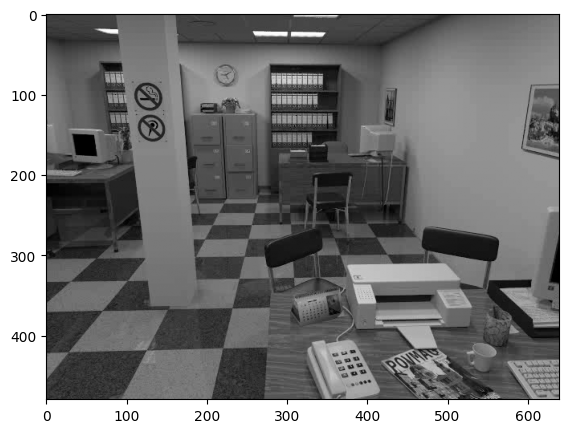

In [43]:
frame_0 = load_gray_image(KEYFRAME_PATH)
print(frame_0.shape)
plt.imshow(frame_0, cmap='gray')

## keyframe

Here we load:

- the reference image specified in `KEYFRAME_PATH`
- the depth map inferred by **Depth Anything** for this image

This image provides the base 3D geometry.


In [44]:
keyframe_image_path = normalize_image_path(KEYFRAME_PATH)
keyframe_image = load_gray_image(keyframe_image_path)
keyframe_depth = load_depth_map(keyframe_image_path)
keyframe_inv_depth, keyframe_inv_depth_var, valid_mask = depth_to_invdepth(keyframe_depth)


In [45]:

print("keyframe_image_path =", keyframe_image_path)
print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_mask.mean()))


keyframe_image_path = C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\Emanuel\images\frames_Emanuel\frame_00000.png
keyframe_image shape = (480, 640) dtype = uint8
keyframe_depth shape = (480, 640) dtype = float32
depth min/max = 1.8346056938171387 84.0458755493164
valid depth ratio = 1.0


Text(0.5, 1.0, 'Inverse depth')

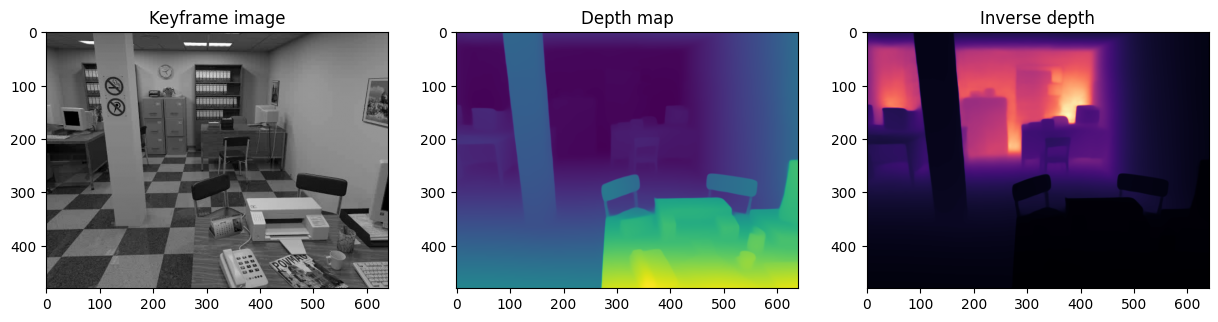

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))




axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")

axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")


axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")




## 4. Intrinsics

Dans ce notebook, les intrinseques doivent etre definies **une seule fois** dans la cellule suivante.

Idee simple :
- tu choisis `USER_FX`, `USER_FY`, `USER_CX`, `USER_CY`
- ces valeurs sont la **source de verite**
- elles sont passees a `camera.camera(...)`
- ensuite on affiche clairement ce que le pipeline utilise vraiment

Important :
- `frameData.py` et `camera.py` redimensionnent tout vers la resolution interne definie dans `params.py`
- donc on affiche a la fois :
  - `K_user` = la matrice que tu choisis
  - `K_used_lvl0` = la matrice effectivement utilisee au niveau 0 de la pyramide

Comme ca, il n'y a plus d'ambiguite sur les intrinseques utilisees dans la suite du notebook.


In [47]:
# ==================================================
# Intrinseques a definir UNE FOIS au debut
# ==================================================
loaded_height, loaded_width = keyframe_image.shape[:2]

# Mets ici les intrinseques que tu veux utiliser.
# Ce bloc est la source de verite pour tout le notebook.
USER_WIDTH = loaded_width
USER_HEIGHT = loaded_height


#Pour Emanuel
USER_FX = 481.20
USER_FY = 480.0
USER_CX = 319.5
USER_CY = 239.5


#Pour tum RGB
#USER_FX = 525.0  # focal length x
#USER_FY = 525.0  # focal length y
#USER_CX = 319.5  # optical center x
#USER_CY = 239.5  # optical center y




intrinsics_user = {
    "width": USER_WIDTH,
    "height": USER_HEIGHT,
    "fx": USER_FX,
    "fy": USER_FY,
    "cx": USER_CX,
    "cy": USER_CY,
}

K_user = np.array([
    [USER_FX, 0.0, USER_CX],
    [0.0, USER_FY, USER_CY],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    USER_WIDTH,
    USER_HEIGHT,
)

intrinsics_used_lvl0 = {
    "width": cam.width[0],
    "height": cam.height[0],
    "fx": cam.fx[0],
    "fy": cam.fy[0],
    "cx": cam.cx[0],
    "cy": cam.cy[0],
}

K_used_lvl0 = np.array([
    [cam.fx[0], 0.0, cam.cx[0]],
    [0.0, cam.fy[0], cam.cy[0]],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

print("Loaded keyframe size:")
print("  width  =", loaded_width)
print("  height =", loaded_height)
print()
print("USER intrinsics chosen at the beginning of the notebook:")
print(intrinsics_user)
print()
print("K_user =")
print(K_user)
print()
print("Internal working resolution used by the pipeline (level 0):")
print("  width  =", intrinsics_used_lvl0["width"])
print("  height =", intrinsics_used_lvl0["height"])
print()
print("K_used_lvl0 =")
print(K_used_lvl0)


Loaded keyframe size:
  width  = 640
  height = 480

USER intrinsics chosen at the beginning of the notebook:
{'width': 640, 'height': 480, 'fx': 481.2, 'fy': 480.0, 'cx': 319.5, 'cy': 239.5}

K_user =
[[481.2   0.  319.5]
 [  0.  480.  239.5]
 [  0.    0.    1. ]]

Internal working resolution used by the pipeline (level 0):
  width  = 640
  height = 480

K_used_lvl0 =
[[481.2   0.  319.5]
 [  0.  480.  239.5]
 [  0.    0.    1. ]]


In [48]:
scale_x = cam.width[0] / USER_WIDTH
scale_y = cam.height[0] / USER_HEIGHT

print("Check that the pipeline camera really comes from the USER intrinsics above:")
print("  scale_x =", scale_x)
print("  scale_y =", scale_y)
print()
print("  USER_FX -> cam.fx[0] :", USER_FX, "->", cam.fx[0])
print("  USER_FY -> cam.fy[0] :", USER_FY, "->", cam.fy[0])
print("  USER_CX -> cam.cx[0] :", USER_CX, "->", cam.cx[0])
print("  USER_CY -> cam.cy[0] :", USER_CY, "->", cam.cy[0])
print()
print("Expected level-0 values after internal resize:")
print("  expected fx =", USER_FX * scale_x)
print("  expected fy =", USER_FY * scale_y)
print("  expected cx =", USER_CX * scale_x)
print("  expected cy =", USER_CY * scale_y)

assert np.isclose(cam.fx[0], USER_FX * scale_x)
assert np.isclose(cam.fy[0], USER_FY * scale_y)
assert np.isclose(cam.cx[0], USER_CX * scale_x)
assert np.isclose(cam.cy[0], USER_CY * scale_y)

print()
print("Assertion passed: the notebook is using the intrinsics defined above.")


Check that the pipeline camera really comes from the USER intrinsics above:
  scale_x = 1.0
  scale_y = 1.0

  USER_FX -> cam.fx[0] : 481.2 -> 481.2
  USER_FY -> cam.fy[0] : 480.0 -> 480.0
  USER_CX -> cam.cx[0] : 319.5 -> 319.5
  USER_CY -> cam.cy[0] : 239.5 -> 239.5

Expected level-0 values after internal resize:
  expected fx = 481.2
  expected fy = 480.0
  expected cx = 319.5
  expected cy = 239.5

Assertion passed: the notebook is using the intrinsics defined above.


### Verification for every pyramid level

On affiche maintenant les intrinseques utilisees a **chaque niveau** de la pyramide, et on verifie qu elles correspondent bien a la regle automatique du code : division par `2**lvl` a partir du niveau 0.

In [49]:
intrinsics_per_level = []
base_fx = cam.fx[0]
base_fy = cam.fy[0]
base_cx = cam.cx[0]
base_cy = cam.cy[0]
base_width = cam.width[0]
base_height = cam.height[0]

print("Intrinsics used for each pyramid level:")
print()

for lvl in range(len(cam.fx)):
    scale = 2 ** lvl
    expected_fx = base_fx / scale
    expected_fy = base_fy / scale
    expected_cx = base_cx / scale
    expected_cy = base_cy / scale
    expected_width = int(base_width / scale)
    expected_height = int(base_height / scale)

    K_lvl = np.array([
        [cam.fx[lvl], 0.0, cam.cx[lvl]],
        [0.0, cam.fy[lvl], cam.cy[lvl]],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    assert np.isclose(cam.fx[lvl], expected_fx)
    assert np.isclose(cam.fy[lvl], expected_fy)
    assert np.isclose(cam.cx[lvl], expected_cx)
    assert np.isclose(cam.cy[lvl], expected_cy)
    assert cam.width[lvl] == expected_width
    assert cam.height[lvl] == expected_height

    intrinsics_per_level.append({
        "level": lvl,
        "scale": scale,
        "width": cam.width[lvl],
        "height": cam.height[lvl],
        "fx": cam.fx[lvl],
        "fy": cam.fy[lvl],
        "cx": cam.cx[lvl],
        "cy": cam.cy[lvl],
        "K": K_lvl,
    })

    print(f"LEVEL {lvl}")
    print(f"  scale  = 1 / {scale}")
    print(f"  size   = {cam.width[lvl]} x {cam.height[lvl]}")
    print(f"  fx, fy = {cam.fx[lvl]:.6f}, {cam.fy[lvl]:.6f}")
    print(f"  cx, cy = {cam.cx[lvl]:.6f}, {cam.cy[lvl]:.6f}")
    print("  K =")
    print(K_lvl)
    print()

print("All assertions passed: each level uses the expected intrinsics.")


Intrinsics used for each pyramid level:

LEVEL 0
  scale  = 1 / 1
  size   = 640 x 480
  fx, fy = 481.200000, 480.000000
  cx, cy = 319.500000, 239.500000
  K =
[[481.2   0.  319.5]
 [  0.  480.  239.5]
 [  0.    0.    1. ]]

LEVEL 1
  scale  = 1 / 2
  size   = 320 x 240
  fx, fy = 240.600000, 240.000000
  cx, cy = 159.750000, 119.750000
  K =
[[240.6    0.   159.75]
 [  0.   240.   119.75]
 [  0.     0.     1.  ]]

LEVEL 2
  scale  = 1 / 4
  size   = 160 x 120
  fx, fy = 120.300000, 120.000000
  cx, cy = 79.875000, 59.875000
  K =
[[120.3     0.     79.875]
 [  0.    120.     59.875]
 [  0.      0.      1.   ]]

LEVEL 3
  scale  = 1 / 8
  size   = 80 x 60
  fx, fy = 60.150000, 60.000000
  cx, cy = 39.937500, 29.937500
  K =
[[60.15    0.     39.9375]
 [ 0.     60.     29.9375]
 [ 0.      0.      1.    ]]

LEVEL 4
  scale  = 1 / 16
  size   = 40 x 30
  fx, fy = 30.075000, 30.000000
  cx, cy = 19.968750, 14.968750
  K =
[[30.075    0.      19.96875]
 [ 0.      30.      14.96875]
 [ 0.  

In [50]:

keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(480, 640), invDepth=(480, 640), grad=(480, 640, 2)
level 1: image=(240, 320), invDepth=(240, 320), grad=(240, 320, 2)
level 2: image=(120, 160), invDepth=(120, 160), grad=(120, 160, 2)
level 3: image=(60, 80), invDepth=(60, 80), grad=(60, 80, 2)
level 4: image=(30, 40), invDepth=(30, 40), grad=(30, 40, 2)


## 5. Loading the current image

Now we take a second image, specified in `TARGET_PATH`.

This is the image whose relative pose with respect to the keyframe we want to estimate.
At first, its pose is the identity, and then the solver updates it.


In [51]:
# TARGET_PATH can be a list (from earlier cells) or a single path string.
if isinstance(TARGET_PATH, (list, tuple)):
	if len(TARGET_PATH) == 0:
		raise ValueError("TARGET_PATH is empty")
	selected_target = TARGET_PATH[0]
else:
	selected_target = TARGET_PATH

current_image_path = normalize_image_path(selected_target)
current_image = load_gray_image(current_image_path)

current_frame = frameData.frameData()
current_frame.setImage(current_image)



### Recap

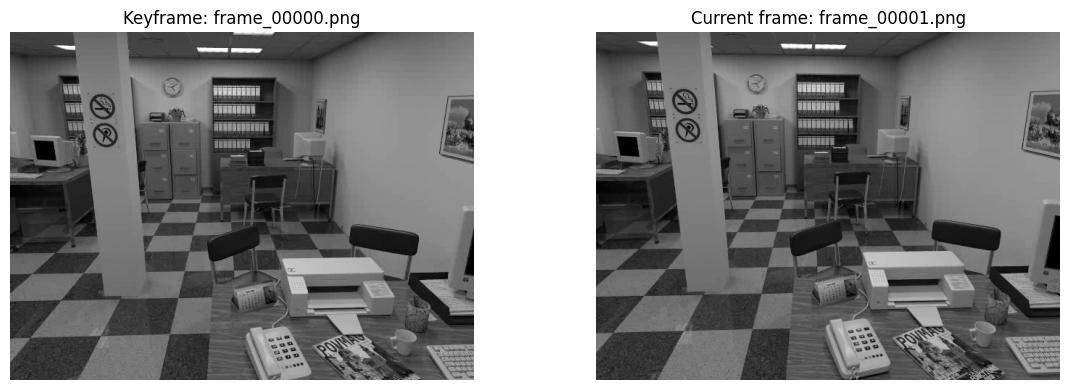

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe: {keyframe_image_path.name}")


axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame: {current_image_path.name}")


for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Initial pose and optimization updates

Dans la cellule suivante, `pose_solver` est cree avec `cam`.
Donc les intrinseques utilisees pour l'estimation de pose sont bien celles affichees juste au-dessus.


In [53]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

print("Proof before optimization:")
print("  pose_solver.camera is cam ->", pose_solver.camera is cam)
print("  pose_solver.camera.fx[0] =", pose_solver.camera.fx[0])
print("  pose_solver.camera.fy[0] =", pose_solver.camera.fy[0])
print("  pose_solver.camera.cx[0] =", pose_solver.camera.cx[0])
print("  pose_solver.camera.cy[0] =", pose_solver.camera.cy[0])
print()
print("Reference level-0 intrinsics that should match:")
print(intrinsics_used_lvl0)
print()

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)


Proof before optimization:
  pose_solver.camera is cam -> True
  pose_solver.camera.fx[0] = 481.2
  pose_solver.camera.fy[0] = 480.0
  pose_solver.camera.cx[0] = 319.5
  pose_solver.camera.cy[0] = 239.5

Reference level-0 intrinsics that should match:
{'width': 640, 'height': 480, 'fx': 481.2, 'fy': 480.0, 'cx': 319.5, 'cy': 239.5}

Initial photometric errors before optimization:
  level 4 = 1007.1387832699616
  level 3 = 1041.9444813094444
  level 2 = 1022.2308724832209


**optPose(...)** performs several updates:

- it computes an error
- it locally linearizes the problem
- it computes a pose increment
- it accepts or rejects this update depending on the error improvement

At the end, **current_frame.pose** contains the estimated extrinsic matrix of the current frame relative to the keyframe.


In [54]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)


lvl:  4  initial error:  1007.1387832699616
 error improvement too small, level converged! it:  4  error:  585.1014530129994  lambda:  0.2
lvl:  3  initial error:  448.2220693776136
 error improvement too small, level converged! it:  4  error:  324.033469627339  lambda:  102.4
lvl:  2  initial error:  200.48167851828276
 error improvement too small, level converged! it:  3  error:  181.15468151584903  lambda:  0.4
Final photometric errors after optimization:
  level 4 = 581.0235512498151
  level 3 = 348.029187457652
  level 2 = 181.15468151584903


### Sanity check on pose estimation

Ici on verifie que le resultat a du sens :
- les erreurs photometriques doivent baisser apres optimisation
- la pose finale doit contenir des valeurs finies
- on veut aussi garder une trace interpretable du gain obtenu a chaque niveau.

In [55]:
optimization_summary = {
    "lvl4_initial": float(initial_error_lvl4),
    "lvl4_final": float(final_error_lvl4),
    "lvl3_initial": float(initial_error_lvl3),
    "lvl3_final": float(final_error_lvl3),
    "lvl2_initial": float(initial_error_lvl2),
    "lvl2_final": float(final_error_lvl2),
}

error_improvement = {
    "lvl4": float(initial_error_lvl4 - final_error_lvl4),
    "lvl3": float(initial_error_lvl3 - final_error_lvl3),
    "lvl2": float(initial_error_lvl2 - final_error_lvl2),
}

print("Optimization summary:")
for lvl in [4, 3, 2]:
    initial_value = optimization_summary[f"lvl{lvl}_initial"]
    final_value = optimization_summary[f"lvl{lvl}_final"]
    improvement = error_improvement[f"lvl{lvl}"]
    print(f"  level {lvl}: initial={initial_value:.6f}, final={final_value:.6f}, improvement={improvement:.6f}")

pose_matrix_now = current_frame.pose.as_matrix()
pose_is_finite = bool(np.isfinite(pose_matrix_now).all())
errors_improved = {lvl: (error_improvement[f"lvl{lvl}"] > 0.0) for lvl in [4, 3, 2]}

print()
print("Pose matrix finite ->", pose_is_finite)
print("Errors improved by level ->", errors_improved)

assert pose_is_finite, "Pose matrix contains non-finite values."
assert all(errors_improved.values()), "At least one pyramid level did not improve after optimization."

print()
print("Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.")


Optimization summary:
  level 4: initial=1007.138783, final=581.023551, improvement=426.115232
  level 3: initial=1041.944481, final=348.029187, improvement=693.915294
  level 2: initial=1022.230872, final=181.154682, improvement=841.076191

Pose matrix finite -> True
Errors improved by level -> {4: True, 3: True, 2: True}

Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.


### Output matrix: the final extrinsic matrix

This is the most important output of the notebook.

This 4x4 matrix represents the estimated relative pose of the current image with respect to the keyframe.

In block form:

$$
T =
\begin{bmatrix}
R & t \\
0 & 1
\end{bmatrix}
$$


In [56]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for {current_image_path.name} relative to {keyframe_image_path.name}:",
    current_frame.pose,
)


Extrinsic matrix for frame_00001.png relative to frame_00000.png:
[[ 0.999935  0.001714 -0.011253  0.022111]
 [-0.00189   0.999877 -0.015591  0.020602]
 [ 0.011225  0.015612  0.999815  0.032443]
 [ 0.        0.        0.        1.      ]]


--
Comparaison avec le GT

In [57]:
GT_Pose = np.array([
    [0.999994773, -0.001180835, -0.002703893, -0.017635176],
    [0.001167188,  0.999986898, -0.005040318, -0.021989598],
    [0.002709795,  0.005037578,  0.999983107,  0.000817620],
    [0.0,          0.0,          0.0,          1.0],
], dtype=np.float64)


Difference = extrinsic_matrix - GT_Pose
A = np.round(Difference, 2)  # 1 chiffre après la virgule

print(A)

[[-0.    0.   -0.01  0.04]
 [-0.   -0.   -0.01  0.04]
 [ 0.01  0.01 -0.    0.03]
 [ 0.    0.    0.    0.  ]]


----------- 

## Evaluation

On garde maintenant **une seule metrique** : la **photometric error**.

Definition :
- on reprojecte chaque pixel valide du keyframe dans l image courante
- on compare l intensite du keyframe a l intensite observee apres reprojection
- on prend la difference au carre
- on somme sur tous les pixels valides



In [58]:
def compute_photometric_error(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    squared_error_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)

    for y in range(height):
        for x in range(width):
            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue

            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            pointFrame = relativePose.dot(pointKeyframe)

            if pointFrame[2] <= 0.0:
                continue

            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue

            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))
            squared_error = (key_intensity - observed_intensity) ** 2

            squared_error_map[y, x] = squared_error
            valid_mask[y, x] = True

    photometric_error = float(np.nansum(squared_error_map[valid_mask]))

    return {
        "photometric_error": photometric_error,
        "squared_error_map": squared_error_map,
        "valid_mask": valid_mask,
        "level": lvl,
    }


In [59]:
evaluation = compute_photometric_error(current_frame, keyframe, cam, lvl=0)

In [60]:
photometric_error = evaluation["photometric_error"]

print("Photometric error =", photometric_error)


Photometric error = 79315344.0


In [61]:
abs_error_map = np.sqrt(evaluation["squared_error_map"])
valid_mask = evaluation["valid_mask"]

valid_abs_errors = abs_error_map[valid_mask]

total_valid_pixels = int(valid_abs_errors.size)
num_gt_200 = int(np.sum(valid_abs_errors > 200))
num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))





num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))








print("Pixel count by absolute difference range:")
print("  total valid pixels       =", total_valid_pixels)
print("  difference > 200         =", num_gt_200)
print("  150 <= difference <= 200 =", num_150_200)
print("  100 <= difference < 150  =", num_100_150)
print("   50 <= difference < 100  =", num_50_100)
print("   30 <= difference < 50   =", num_30_50)
print("   10 <= difference < 30   =", num_10_30)
print("    0 <= difference < 10   =", num_0_10)


Pixel count by absolute difference range:
  total valid pixels       = 297907
  difference > 200         = 3
  150 <= difference <= 200 = 115
  100 <= difference < 150  = 878
   50 <= difference < 100  = 7086
   30 <= difference < 50   = 10773
   10 <= difference < 30   = 36850
    0 <= difference < 10   = 242202


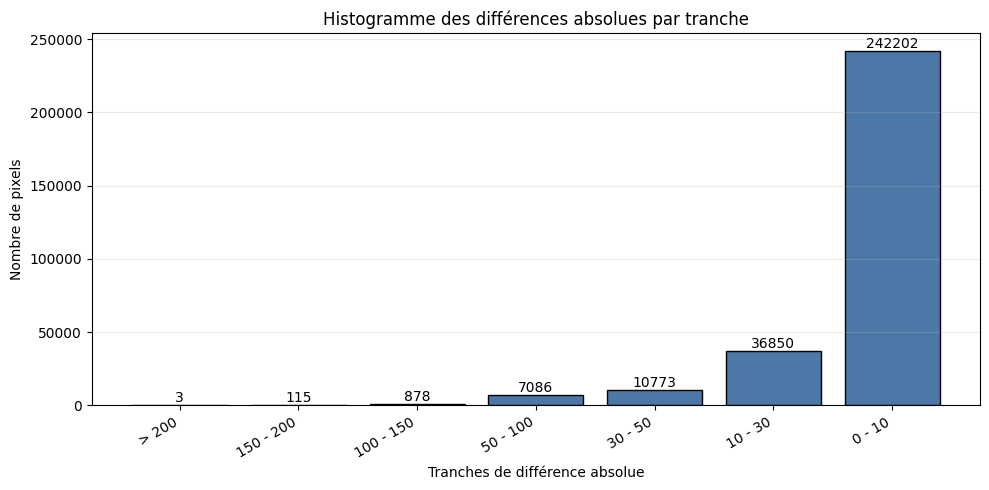

In [62]:
range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

range_counts = [
    num_gt_200,
    num_150_200,
    num_100_150,
    num_50_100,
    num_30_50,
    num_10_30,
    num_0_10,
]

plt.figure(figsize=(10, 5))
bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
plt.title("Histogramme des différences absolues par tranche")
plt.xlabel("Tranches de différence absolue")
plt.ylabel("Nombre de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, range_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


### Squared photometric error map

Cette figure n ajoute pas une nouvelle metrique.
Elle sert seulement a voir **ou** l erreur photometrique se concentre dans l image.


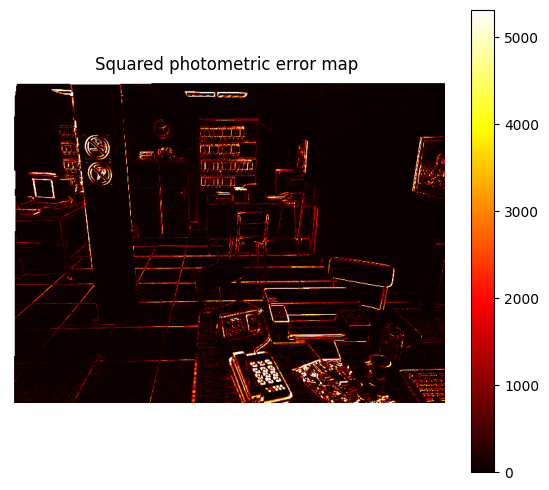

In [63]:
squared_error_map = evaluation["squared_error_map"]
valid_mask = evaluation["valid_mask"]

valid_values = squared_error_map[valid_mask]
vmax_sq = float(np.nanpercentile(valid_values, 99)) if valid_values.size > 0 else 1.0

plt.figure(figsize=(7, 6))
plt.imshow(squared_error_map, cmap="hot", vmin=0, vmax=vmax_sq)
plt.title("Squared photometric error map")
plt.axis("off")
plt.colorbar()
plt.show()


In [64]:
print("Only evaluation metric used in this notebook:")
print("  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels")


Only evaluation metric used in this notebook:
  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels


------
## Scale sur toutes les images

In [65]:


print(len(real_frame_paths))

101


Sequence real:
  source size = 640 x 480
  working size level-0 = 640 x 480
  fx level-0 = 481.2
  fy level-0 = 480.0

[real] frame 0 -> keyframe de reference: frame_00000.png
lvl:  4  initial error:  1007.1387832699616
 error improvement too small, level converged! it:  4  error:  585.1014530129994  lambda:  0.2
lvl:  3  initial error:  448.2220693776136
 error improvement too small, level converged! it:  4  error:  324.033469627339  lambda:  102.4
lvl:  2  initial error:  200.48167851828276
 error improvement too small, level converged! it:  3  error:  181.15468151584903  lambda:  0.4
[real] frame 1 -> frame_00001.png | sum error = 79315344.00 | mean abs error = 7.4799 | valid pixels = 297907


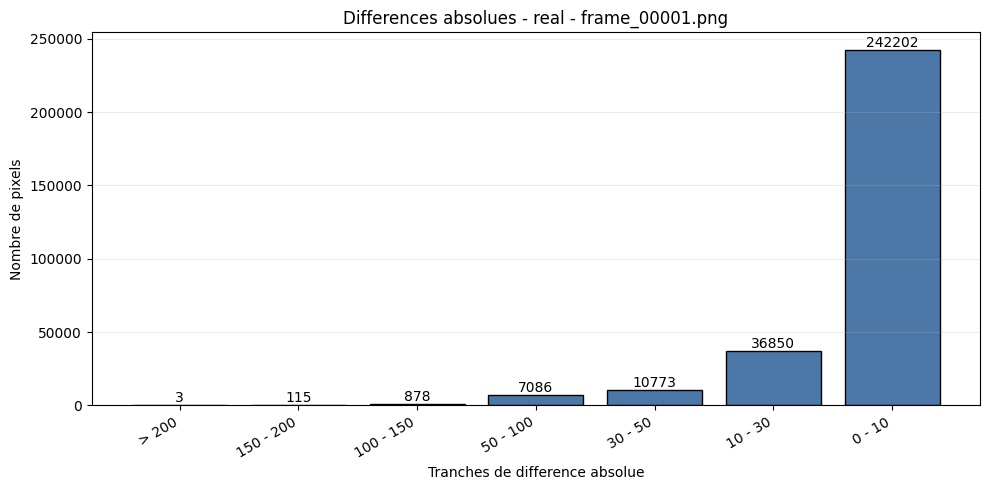

lvl:  4  initial error:  1535.7956273764255
 error improvement too small, level converged! it:  7  error:  533.507974257411  lambda:  28147497671065.6
lvl:  3  initial error:  386.6787381952081
update too small, level converged! it:  4  error:  317.48435731656696  lambda:  28147497671065.6
lvl:  2  initial error:  321.30347762293695
 error improvement too small, level converged! it:  2  error:  301.68116223519604  lambda:  0.0
[real] frame 2 -> frame_00002.png | sum error = 139825552.00 | mean abs error = 10.6888 | valid pixels = 292913


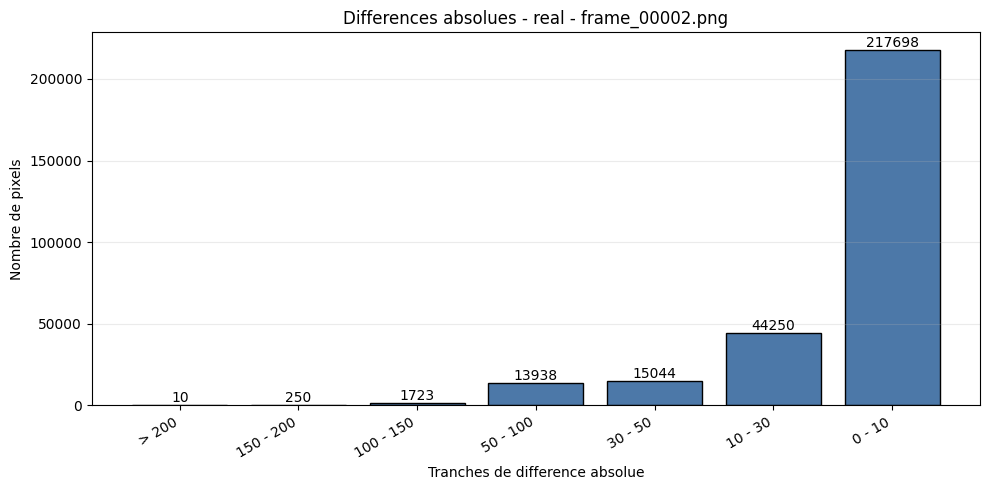

lvl:  4  initial error:  2179.5779467680604
update too small, level converged! it:  5  error:  555.5601155583761  lambda:  225179981368524.8
lvl:  3  initial error:  665.6870536689881
 error improvement too small, level converged! it:  3  error:  441.09056652707073  lambda:  204.8
lvl:  2  initial error:  510.92674369123057
 error improvement too small, level converged! it:  5  error:  473.58356811590346  lambda:  0.0
[real] frame 3 -> frame_00003.png | sum error = 194417760.00 | mean abs error = 13.4230 | valid pixels = 286559


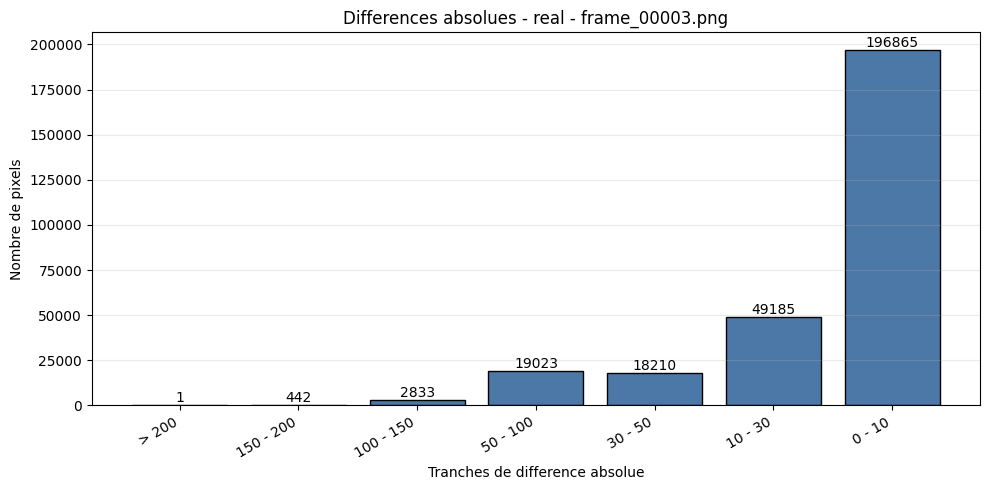

lvl:  4  initial error:  2435.9629277566537
 error improvement too small, level converged! it:  3  error:  576.5176398585543  lambda:  7036874417766.4
lvl:  3  initial error:  647.8887043042804
 error improvement too small, level converged! it:  2  error:  639.8829949532152  lambda:  0.1
lvl:  2  initial error:  717.9712260718376
 error improvement too small, level converged! it:  3  error:  715.5886797455724  lambda:  0.0
[real] frame 4 -> frame_00004.png | sum error = 253378768.00 | mean abs error = 17.1035 | valid pixels = 273653


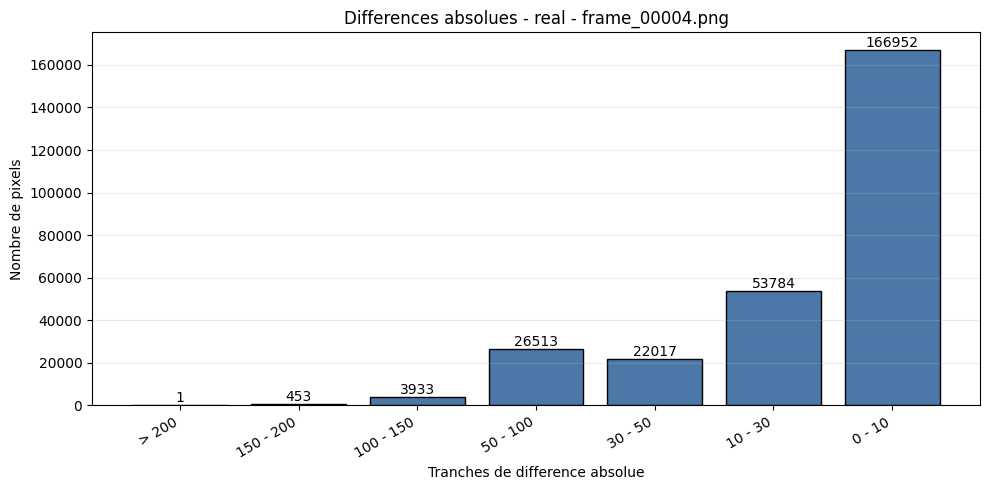

lvl:  4  initial error:  2494.0285171102655
 error improvement too small, level converged! it:  5  error:  634.0206728669997  lambda:  0.0
lvl:  3  initial error:  740.0418667461357
 error improvement too small, level converged! it:  3  error:  704.6965672038044  lambda:  879609302220.8
lvl:  2  initial error:  803.2498422972008
 error improvement too small, level converged! it:  5  error:  786.8252324340477  lambda:  0.0
[real] frame 5 -> frame_00005.png | sum error = 271951104.00 | mean abs error = 18.4936 | valid pixels = 268421


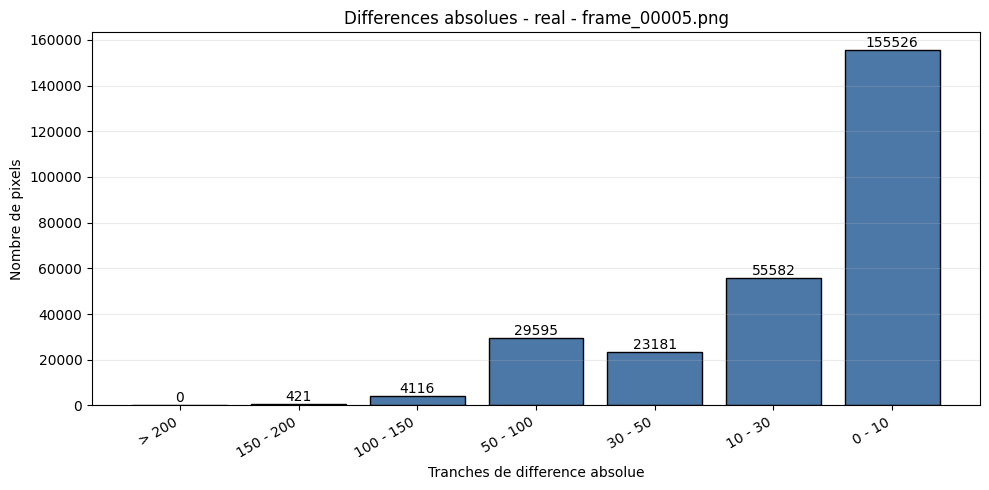

lvl:  4  initial error:  2943.403992395437
 error improvement too small, level converged! it:  4  error:  782.4265296762143  lambda:  0.1
lvl:  3  initial error:  928.0210648604351
 error improvement too small, level converged! it:  8  error:  785.7334257834541  lambda:  3.2
lvl:  2  initial error:  865.3533092197283
 error improvement too small, level converged! it:  7  error:  842.6041405000318  lambda:  12.8
[real] frame 6 -> frame_00006.png | sum error = 295846144.00 | mean abs error = 19.5854 | valid pixels = 268184


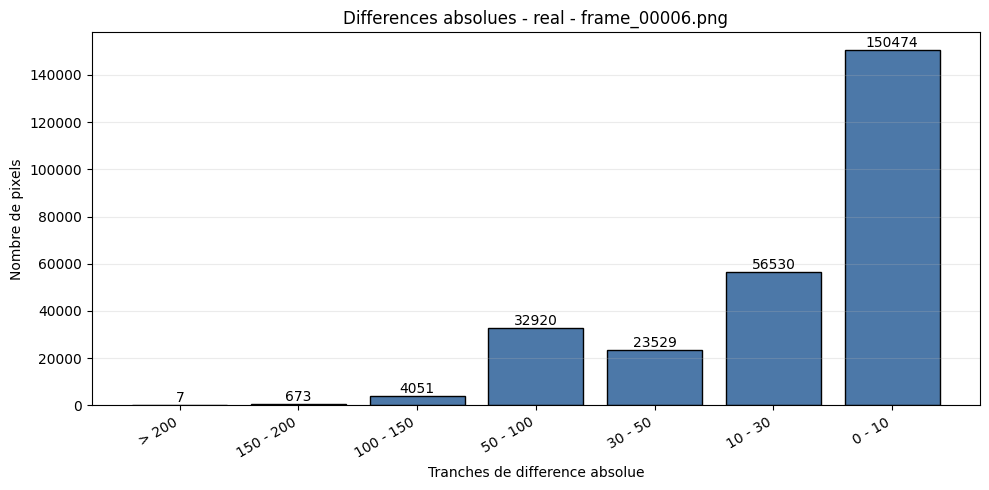

lvl:  4  initial error:  2802.2110266159693
 error improvement too small, level converged! it:  4  error:  759.6927459762495  lambda:  0.0
lvl:  3  initial error:  952.7982619402713
 error improvement too small, level converged! it:  7  error:  800.0385094893965  lambda:  0.0
lvl:  2  initial error:  884.2456177710816
 error improvement too small, level converged! it:  5  error:  856.3406858879198  lambda:  3.2
[real] frame 7 -> frame_00007.png | sum error = 297221728.00 | mean abs error = 19.5278 | valid pixels = 269475


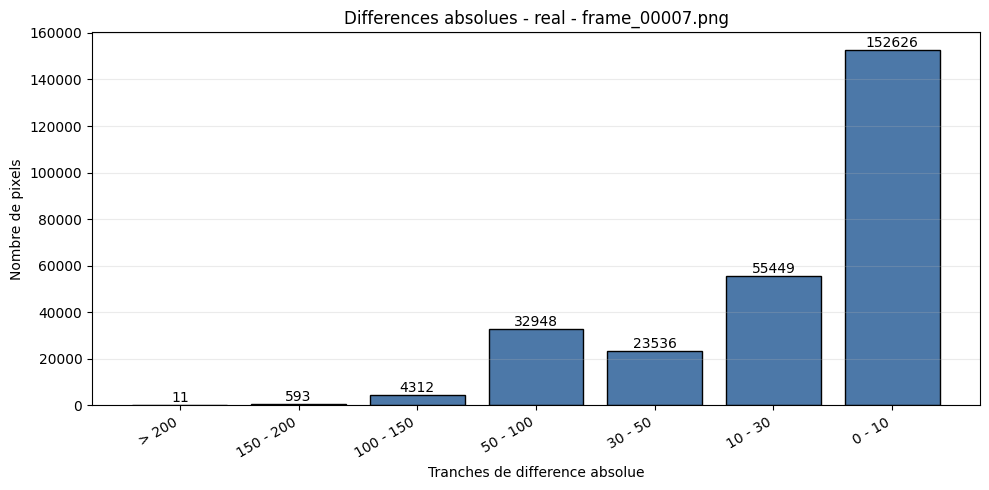

lvl:  4  initial error:  2648.5313688212923
 error improvement too small, level converged! it:  4  error:  772.9956144077742  lambda:  3518437208883.2
lvl:  3  initial error:  842.2794690787728
 error improvement too small, level converged! it:  8  error:  781.2114752644184  lambda:  0.0
lvl:  2  initial error:  862.3222608239942
 error improvement too small, level converged! it:  4  error:  847.2368601809964  lambda:  0.0
[real] frame 8 -> frame_00008.png | sum error = 287992064.00 | mean abs error = 19.0734 | valid pixels = 270674


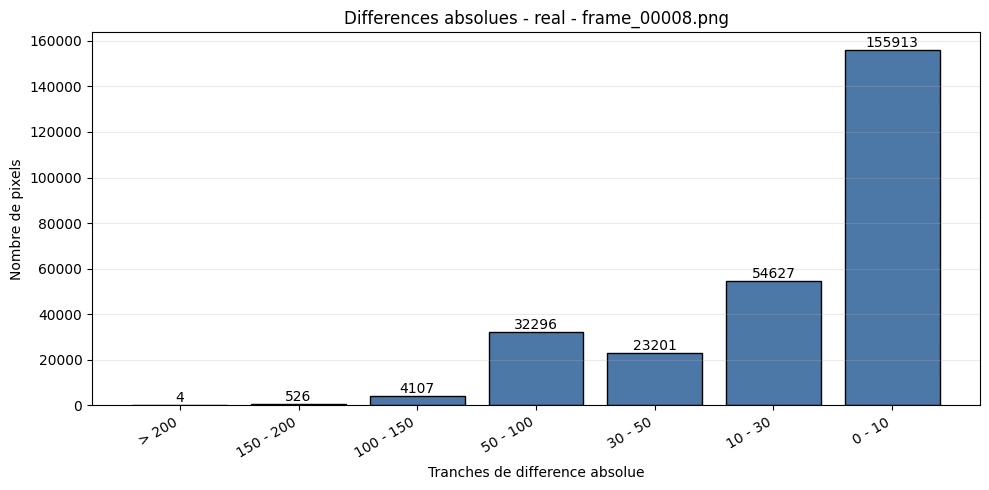

lvl:  4  initial error:  2294.252851711027
 error improvement too small, level converged! it:  5  error:  579.5373088408926  lambda:  0.1
lvl:  3  initial error:  689.2963234123841
 error improvement too small, level converged! it:  6  error:  630.9698293963104  lambda:  0.0
lvl:  2  initial error:  693.3205174483495
 error improvement too small, level converged! it:  3  error:  685.6825761563981  lambda:  0.0
[real] frame 9 -> frame_00009.png | sum error = 246497760.00 | mean abs error = 16.4727 | valid pixels = 278197


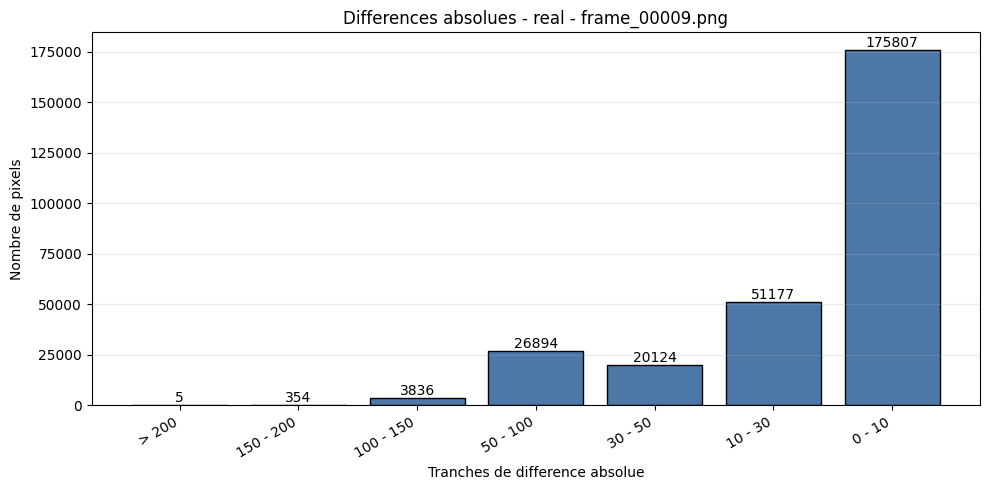

lvl:  4  initial error:  2005.4106463878327
update too small, level converged! it:  6  error:  624.4173918110164  lambda:  14073748835532.8
lvl:  3  initial error:  551.6964192359729
 error improvement too small, level converged! it:  3  error:  537.3632103804107  lambda:  0.0
lvl:  2  initial error:  584.9726798200187
 error improvement too small, level converged! it:  3  error:  565.7171210803909  lambda:  0.4
[real] frame 10 -> frame_00010.png | sum error = 212971072.00 | mean abs error = 14.4007 | valid pixels = 283382


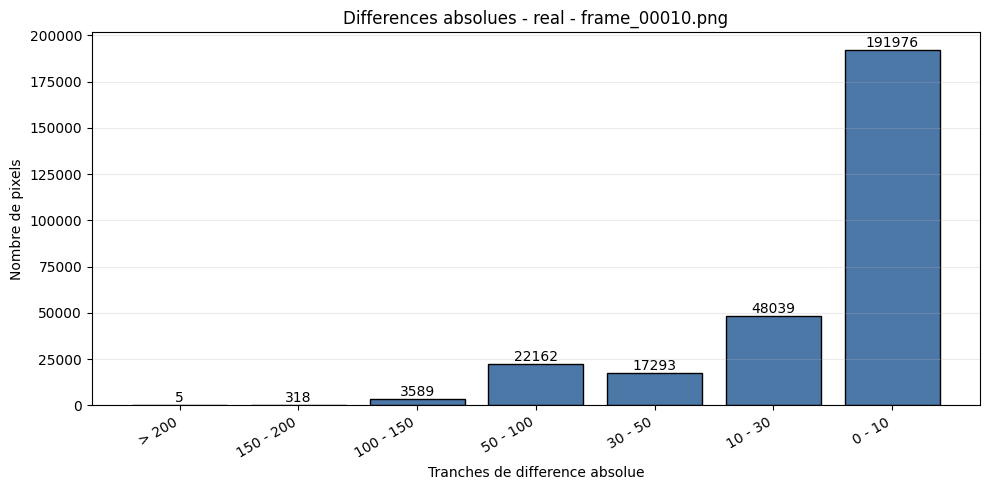

lvl:  4  initial error:  1360.9752851711023
update too small, level converged! it:  1  error:  1360.9752851711023  lambda:  3602879701896397.0
lvl:  3  initial error:  1436.659463445822
 error improvement too small, level converged! it:  6  error:  365.36876177761775  lambda:  7036874417766.4
lvl:  2  initial error:  317.35415590695504
 error improvement too small, level converged! it:  2  error:  315.111404720623  lambda:  3518437208883.2
[real] frame 11 -> frame_00011.png | sum error = 142657664.00 | mean abs error = 10.5312 | valid pixels = 293229


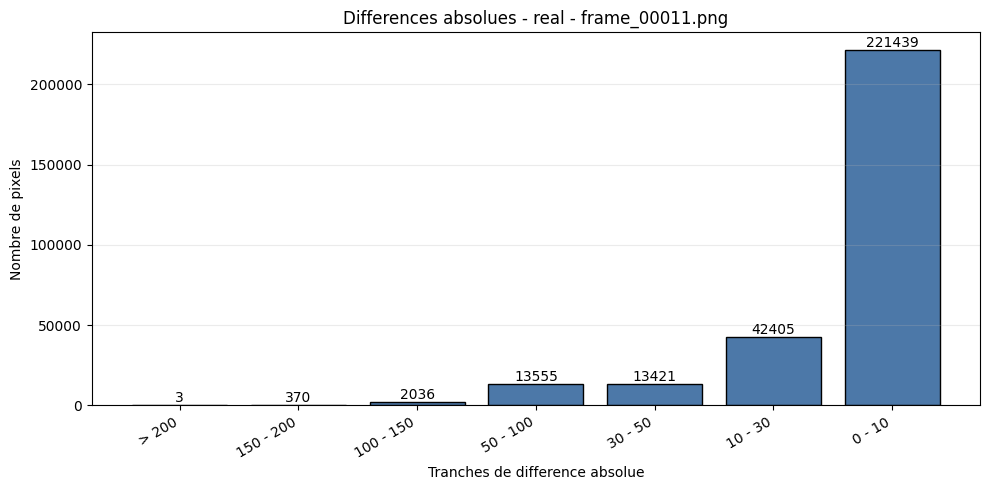

lvl:  4  initial error:  1186.857414448669
update too small, level converged! it:  5  error:  620.0074784371673  lambda:  900719925474099.2
lvl:  3  initial error:  491.06582262007134
 error improvement too small, level converged! it:  4  error:  267.37404711428775  lambda:  1.6
lvl:  2  initial error:  264.58531602525
 error improvement too small, level converged! it:  2  error:  250.06125497482606  lambda:  3.2
[real] frame 12 -> frame_00012.png | sum error = 114089376.00 | mean abs error = 8.9387 | valid pixels = 296033


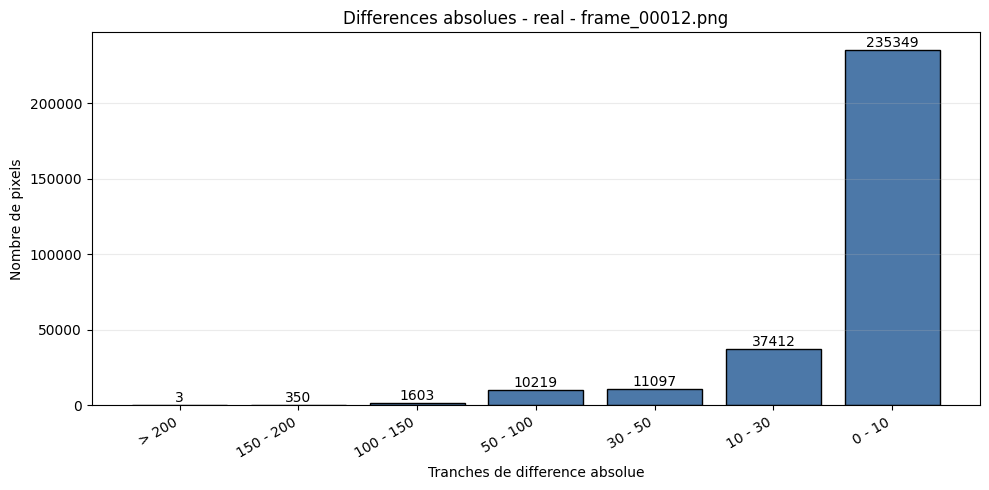

lvl:  4  initial error:  1485.1863117870719
 error improvement too small, level converged! it:  5  error:  660.8859064863695  lambda:  0.0
lvl:  3  initial error:  565.9597372391661
 error improvement too small, level converged! it:  6  error:  277.2037013112375  lambda:  0.4
lvl:  2  initial error:  276.90866972787836
 error improvement too small, level converged! it:  3  error:  261.64181079785624  lambda:  0.0
[real] frame 13 -> frame_00013.png | sum error = 117959064.00 | mean abs error = 9.3724 | valid pixels = 290003


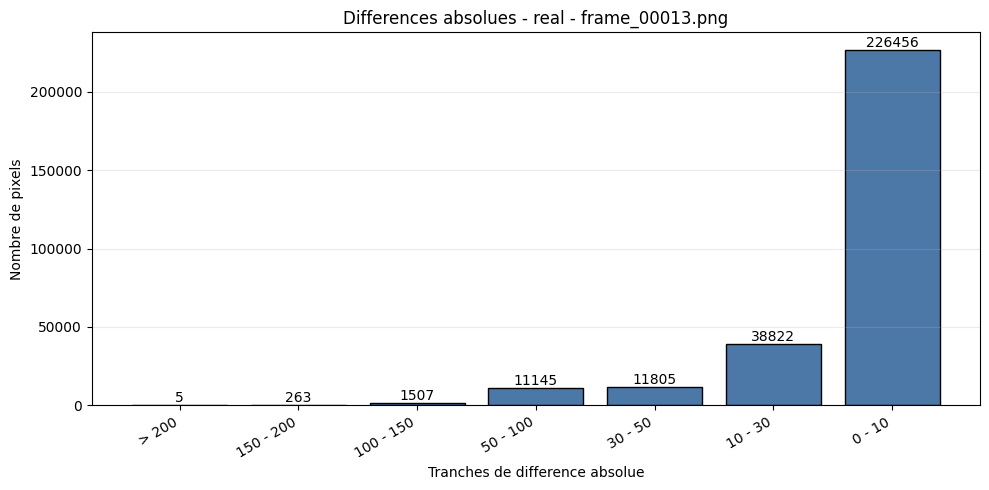

lvl:  4  initial error:  1980.7395437262353
 error improvement too small, level converged! it:  5  error:  839.7219960849395  lambda:  1759218604441.6
lvl:  3  initial error:  587.9087368059977
 error improvement too small, level converged! it:  3  error:  465.15978098423506  lambda:  0.0
lvl:  2  initial error:  442.3013108796827
 error improvement too small, level converged! it:  4  error:  426.7198388401584  lambda:  0.0
[real] frame 14 -> frame_00014.png | sum error = 164745392.00 | mean abs error = 11.8933 | valid pixels = 281743


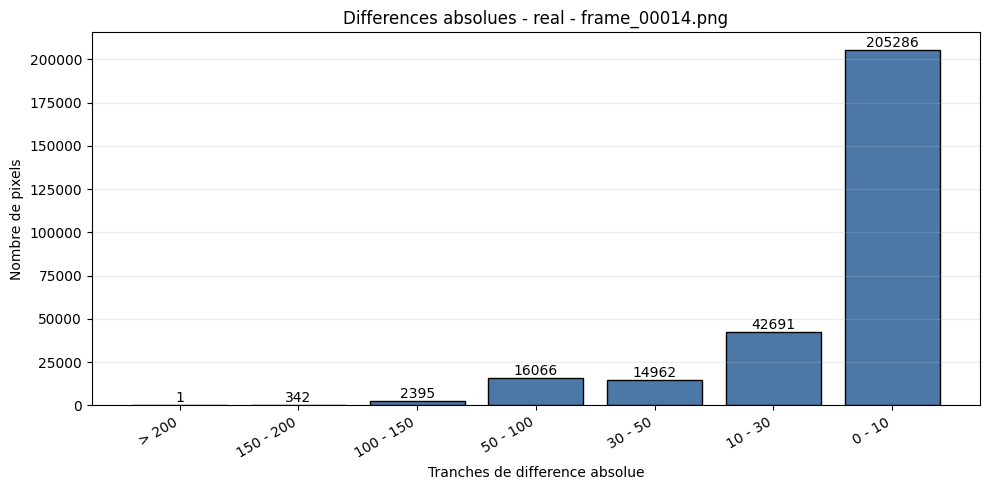

xFormers not available
xFormers not available


Depth Anything loaded on cpu (97.47M parameters)
lvl:  4  initial error:  2083.7956273764257
update too small, level converged! it:  5  error:  609.9606006610624  lambda:  28147497671065.6
lvl:  3  initial error:  534.1223496473343
 error improvement too small, level converged! it:  6  error:  509.8819144124472  lambda:  0.0
lvl:  2  initial error:  518.3091503251297
 error improvement too small, level converged! it:  8  error:  488.20338710404707  lambda:  0.0
[real] frame 15 -> frame_00015.png | sum error = 178076496.00 | mean abs error = 12.6149 | valid pixels = 278972


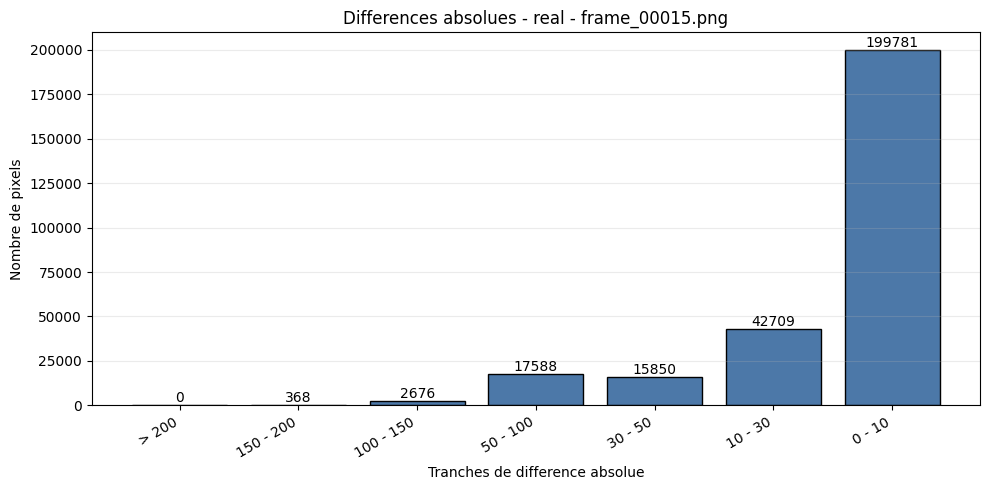

lvl:  4  initial error:  2377.184410646387
 error improvement too small, level converged! it:  5  error:  760.7667643685518  lambda:  12.8
lvl:  3  initial error:  751.073988348447
 error improvement too small, level converged! it:  5  error:  661.9819253083344  lambda:  0.0
lvl:  2  initial error:  676.2217287614051
 error improvement too small, level converged! it:  7  error:  629.8735592865307  lambda:  0.0
[real] frame 16 -> frame_00016.png | sum error = 217490784.00 | mean abs error = 14.7510 | valid pixels = 271136


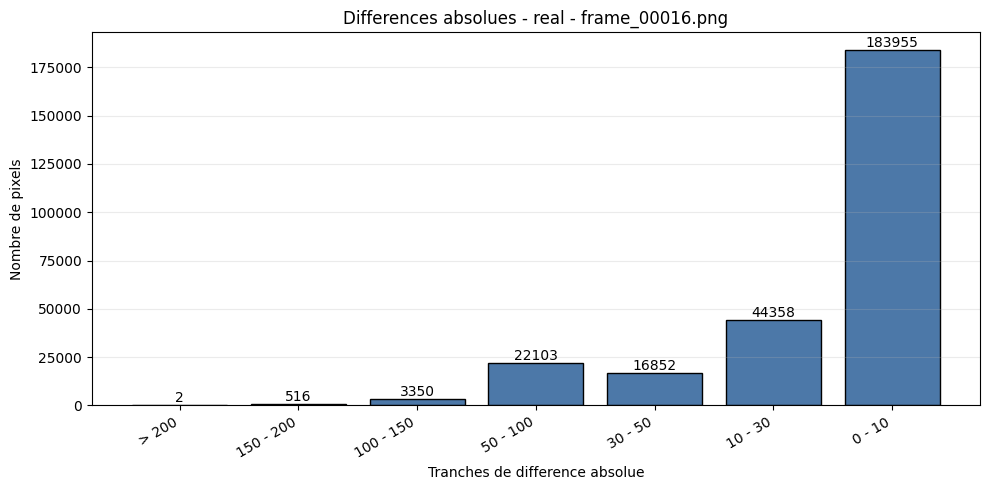

lvl:  4  initial error:  2672.6406844106455
 error improvement too small, level converged! it:  4  error:  791.023341249067  lambda:  1638.4
lvl:  3  initial error:  848.5654231489012
 error improvement too small, level converged! it:  5  error:  713.1475003280339  lambda:  0.0
lvl:  2  initial error:  742.9299146960348
 error improvement too small, level converged! it:  4  error:  704.0248330723447  lambda:  0.0
[real] frame 17 -> frame_00017.png | sum error = 239324800.00 | mean abs error = 16.1893 | valid pixels = 265581


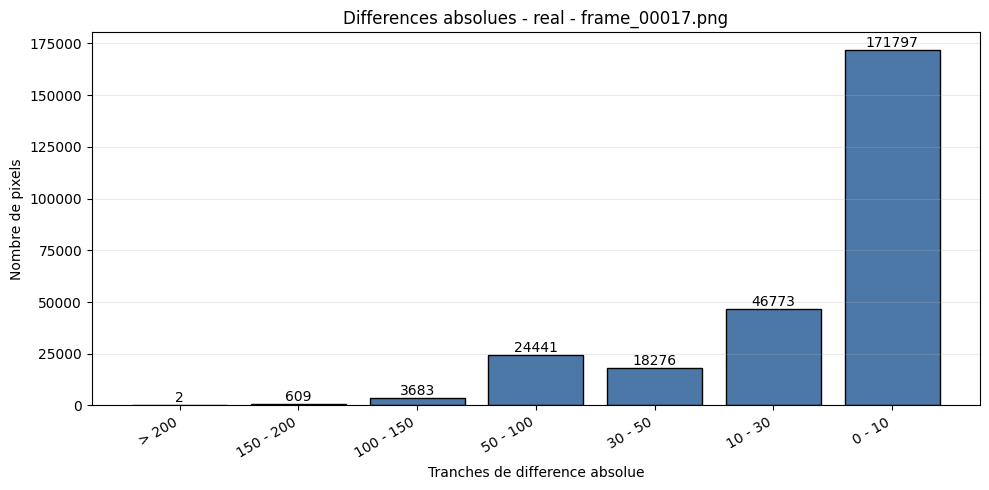

lvl:  4  initial error:  2660.761406844106
update too small, level converged! it:  4  error:  793.1153080820803  lambda:  112589990684262.4
lvl:  3  initial error:  901.5115413363603
 error improvement too small, level converged! it:  5  error:  765.305855089246  lambda:  7036874417766.4
lvl:  2  initial error:  770.90694005124
 error improvement too small, level converged! it:  2  error:  764.9759662580067  lambda:  51.2
[real] frame 18 -> frame_00018.png | sum error = 264786208.00 | mean abs error = 17.6425 | valid pixels = 261842


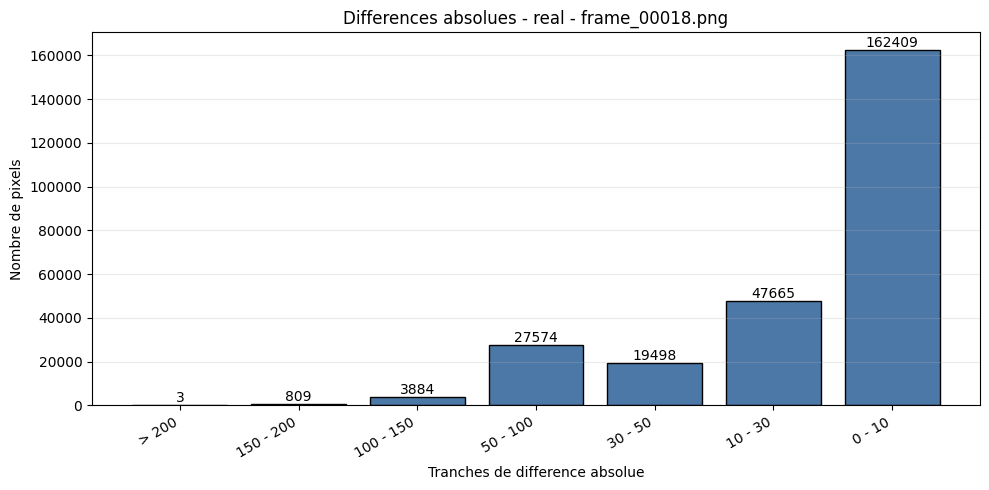

lvl:  4  initial error:  2637.615969581749
 error improvement too small, level converged! it:  7  error:  838.588180566886  lambda:  51.2
lvl:  3  initial error:  864.5207511780276
 error improvement too small, level converged! it:  6  error:  766.0299355612091  lambda:  25.6
lvl:  2  initial error:  843.4627387492515
 error improvement too small, level converged! it:  7  error:  812.0678703072897  lambda:  0.0
[real] frame 19 -> frame_00019.png | sum error = 267079840.00 | mean abs error = 18.3502 | valid pixels = 258653


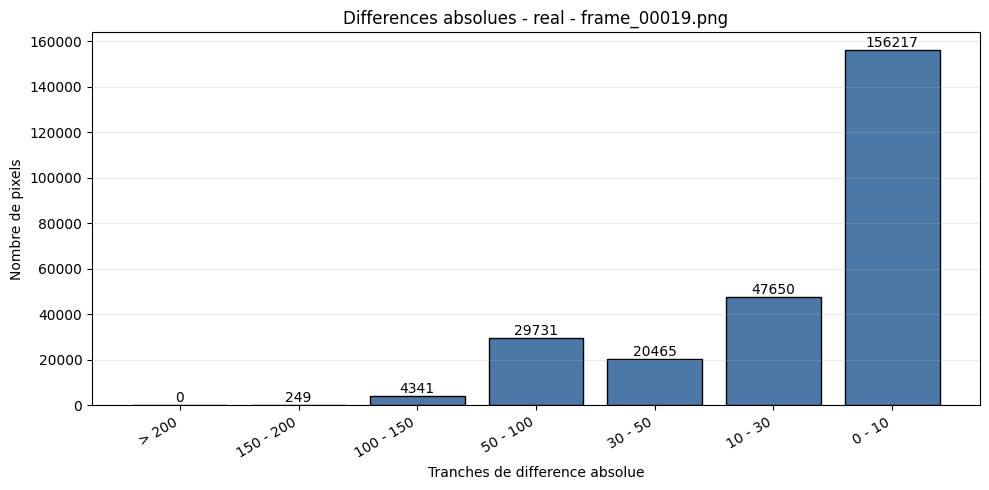

lvl:  4  initial error:  2529.234790874524
 error improvement too small, level converged! it:  4  error:  810.6409087210349  lambda:  7036874417766.4
lvl:  3  initial error:  1005.3303202383559
 error improvement too small, level converged! it:  5  error:  848.0707385510949  lambda:  0.1
lvl:  2  initial error:  868.6750229879433
 error improvement too small, level converged! it:  6  error:  845.5184782459576  lambda:  409.6
[real] frame 20 -> frame_00020.png | sum error = 271550944.00 | mean abs error = 18.7669 | valid pixels = 257430


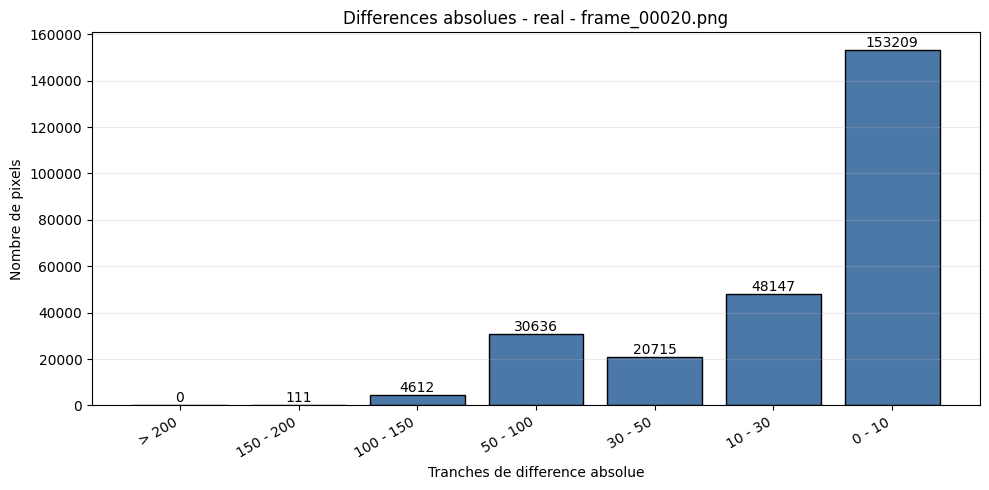

lvl:  4  initial error:  2311.3326996197716
update too small, level converged! it:  4  error:  827.606973992163  lambda:  450359962737049.6
lvl:  3  initial error:  902.3741355478243
 error improvement too small, level converged! it:  4  error:  876.7609799842951  lambda:  109951162777.6
lvl:  2  initial error:  938.9396409616477
 error improvement too small, level converged! it:  5  error:  930.1442144730732  lambda:  0.0
[real] frame 21 -> frame_00021.png | sum error = 292581920.00 | mean abs error = 20.1714 | valid pixels = 256681


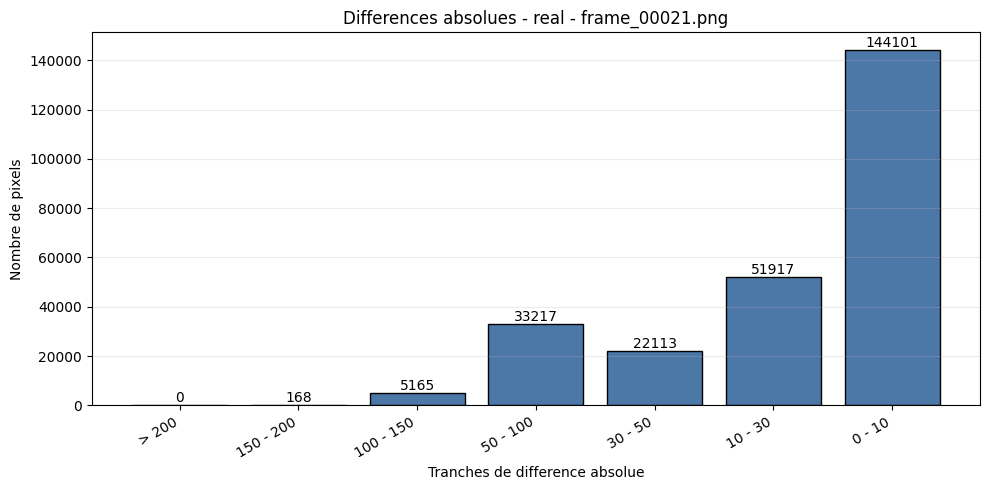

lvl:  4  initial error:  2441.2138783269957
 error improvement too small, level converged! it:  4  error:  805.1498991456156  lambda:  25.6
lvl:  3  initial error:  920.872344837609
 error improvement too small, level converged! it:  3  error:  815.5348961404469  lambda:  1.6
lvl:  2  initial error:  898.7554650727523
 error improvement too small, level converged! it:  8  error:  870.4209141621825  lambda:  0.0
[real] frame 22 -> frame_00022.png | sum error = 282993472.00 | mean abs error = 19.3875 | valid pixels = 263796


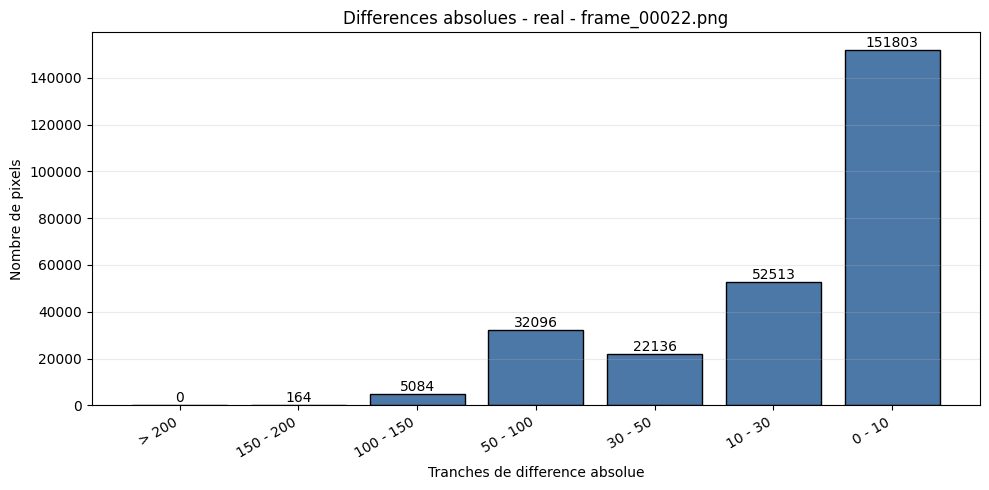

lvl:  4  initial error:  2492.3811787072245
 error improvement too small, level converged! it:  4  error:  814.8609176889883  lambda:  0.8
lvl:  3  initial error:  857.5895526649787
 error improvement too small, level converged! it:  4  error:  827.8790441073304  lambda:  0.0
lvl:  2  initial error:  875.3338720335628
 error improvement too small, level converged! it:  4  error:  868.5532366614859  lambda:  0.0
[real] frame 23 -> frame_00023.png | sum error = 288339712.00 | mean abs error = 19.3490 | valid pixels = 270146


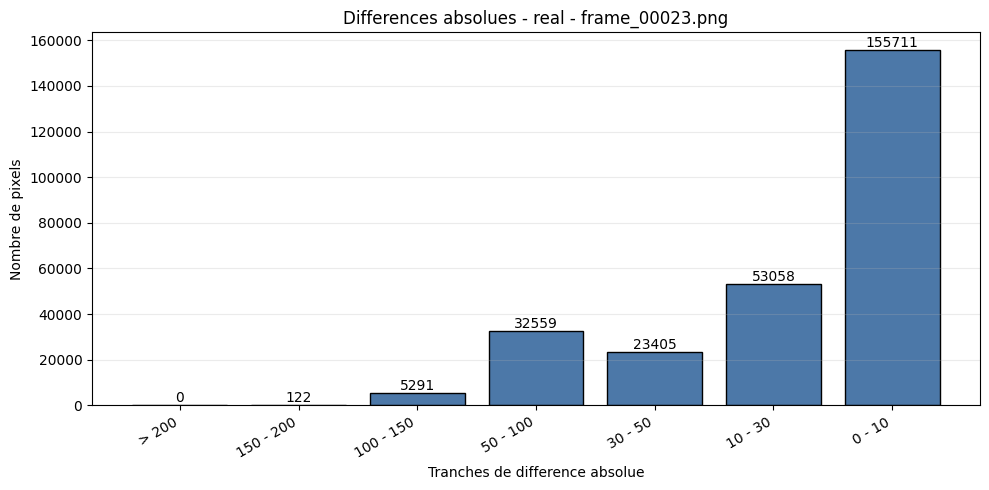

lvl:  4  initial error:  2852.2813688212923
update too small, level converged! it:  6  error:  926.8086297026605  lambda:  450359962737049.6
lvl:  3  initial error:  1060.5347953965943
 error improvement too small, level converged! it:  5  error:  990.0110872457982  lambda:  0.0
lvl:  2  initial error:  1046.078298236809
 error improvement too small, level converged! it:  1  error:  1045.8843313741888  lambda:  0.0
[real] frame 24 -> frame_00024.png | sum error = 327903136.00 | mean abs error = 22.3038 | valid pixels = 259200


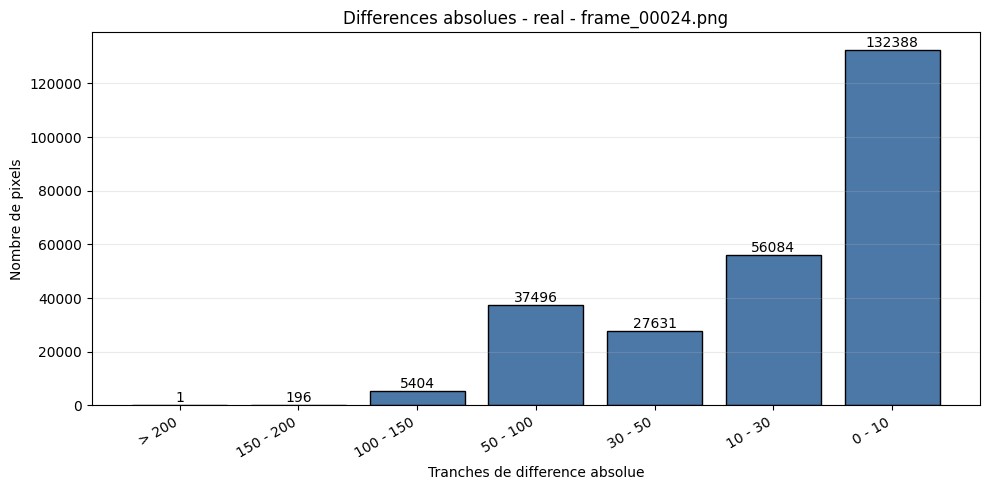

lvl:  4  initial error:  2953.4781368821286
 error improvement too small, level converged! it:  4  error:  913.3073354198161  lambda:  1.6
lvl:  3  initial error:  1197.7934784135844
 error improvement too small, level converged! it:  5  error:  1090.8185514933905  lambda:  0.0
lvl:  2  initial error:  1178.013688697094
 error improvement too small, level converged! it:  8  error:  1152.9747285830058  lambda:  0.0
[real] frame 25 -> frame_00025.png | sum error = 345985024.00 | mean abs error = 24.0940 | valid pixels = 251499


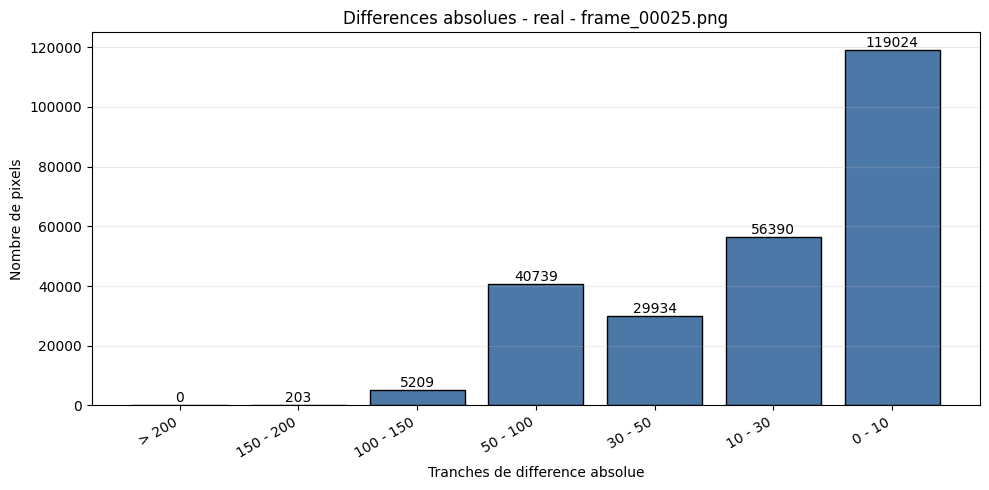

lvl:  4  initial error:  3399.4220532319387
 error improvement too small, level converged! it:  8  error:  1229.2140756936872  lambda:  0.4
lvl:  3  initial error:  1473.9391809081749
 error improvement too small, level converged! it:  16  error:  1280.9055883044691  lambda:  0.0
lvl:  2  initial error:  1397.869113829338
 error improvement too small, level converged! it:  7  error:  1337.6958292953443  lambda:  0.0
[real] frame 26 -> frame_00026.png | sum error = 366211680.00 | mean abs error = 27.4360 | valid pixels = 228909


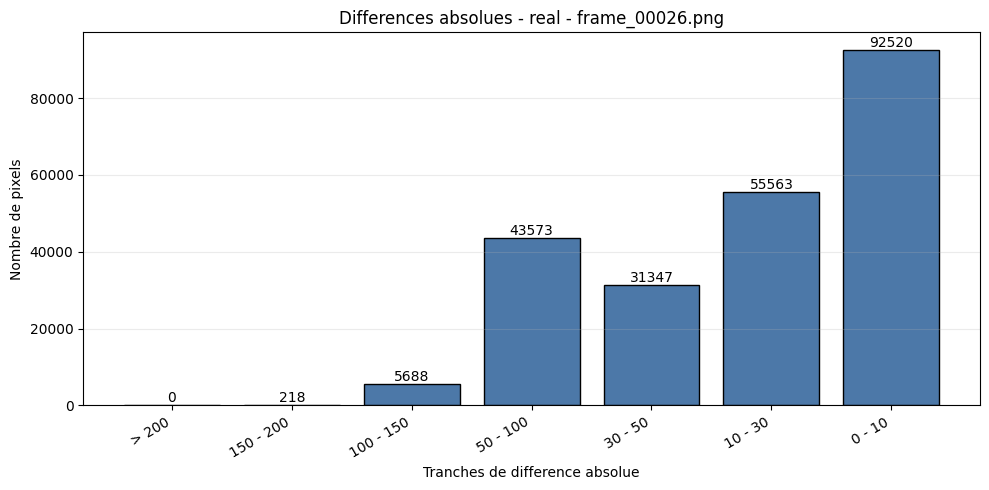

lvl:  4  initial error:  3433.764258555133
 error improvement too small, level converged! it:  6  error:  1300.6193686388926  lambda:  25.6
lvl:  3  initial error:  1401.5123154718312
 error improvement too small, level converged! it:  8  error:  1321.223478729802  lambda:  0.0
lvl:  2  initial error:  1389.2738123058712
 error improvement too small, level converged! it:  1  error:  1388.870456634349  lambda:  0.0
[real] frame 27 -> frame_00027.png | sum error = 354481696.00 | mean abs error = 27.8306 | valid pixels = 216045


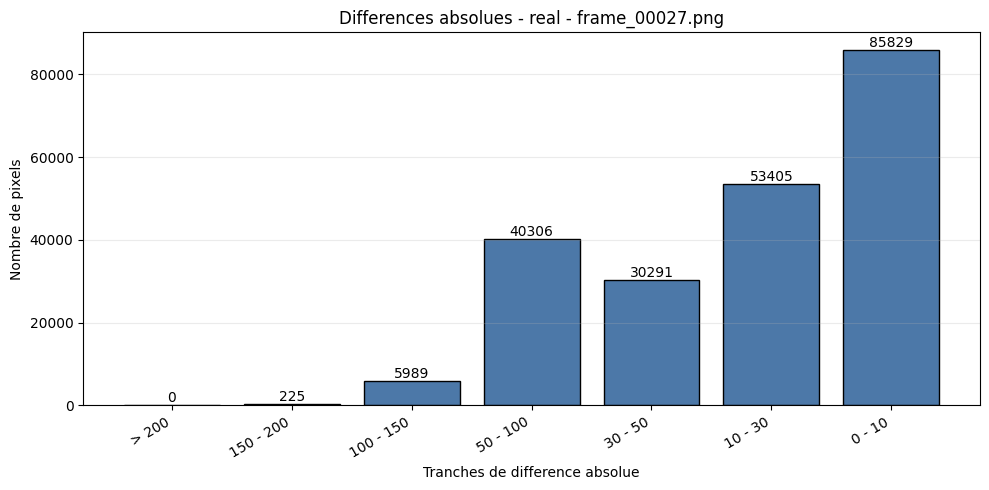

lvl:  4  initial error:  3419.429657794676
update too small, level converged! it:  12  error:  1396.4259737497923  lambda:  450359962737049.6
lvl:  3  initial error:  1490.2316803615493
 error improvement too small, level converged! it:  8  error:  1431.4944042504821  lambda:  0.0
lvl:  2  initial error:  1542.3577854047492
 error improvement too small, level converged! it:  11  error:  1468.3519292347908  lambda:  0.0
[real] frame 28 -> frame_00028.png | sum error = 353841504.00 | mean abs error = 28.7472 | valid pixels = 207656


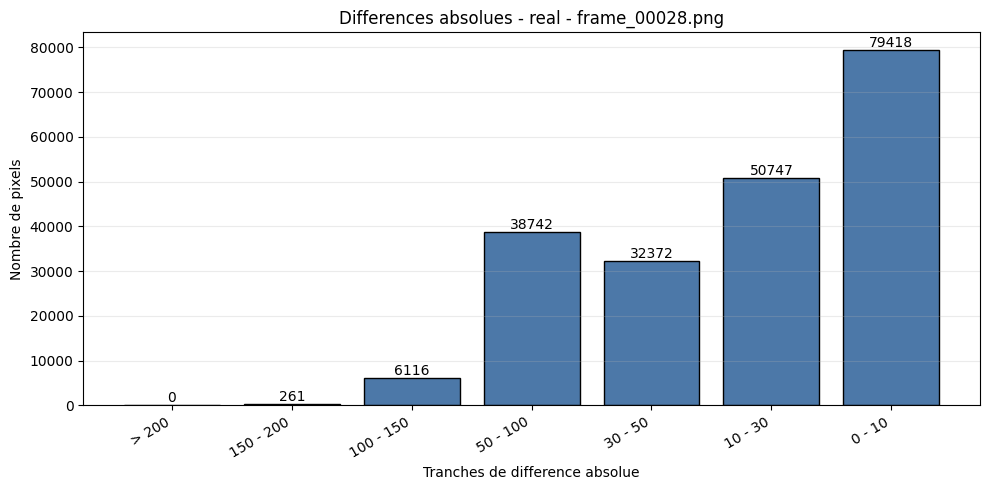

lvl:  4  initial error:  3467.180608365019
 error improvement too small, level converged! it:  15  error:  1563.5571575695933  lambda:  12.8
lvl:  3  initial error:  1708.4366368932747
 error improvement too small, level converged! it:  8  error:  1649.2729163924826  lambda:  0.0
lvl:  2  initial error:  1733.4236275691176
 error improvement too small, level converged! it:  10  error:  1649.488646227776  lambda:  0.0
[real] frame 29 -> frame_00029.png | sum error = 379766240.00 | mean abs error = 31.2875 | valid pixels = 198122


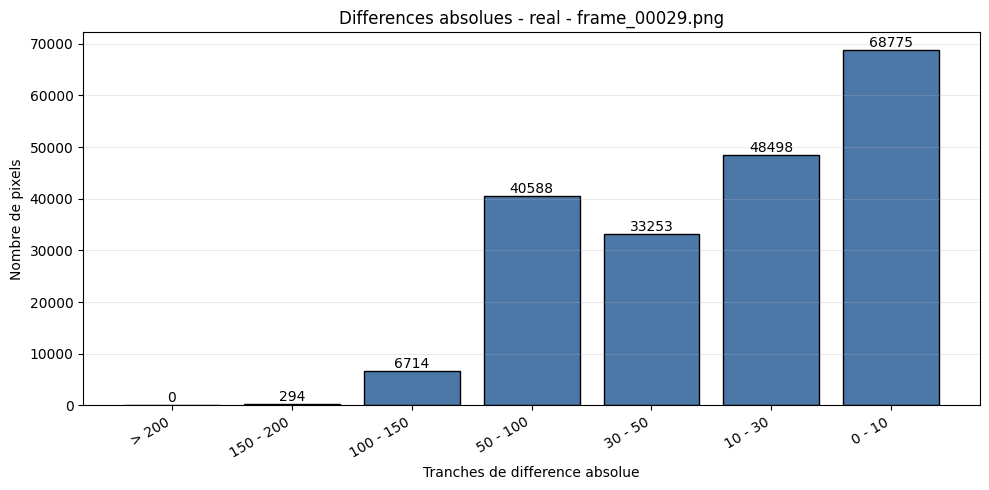

lvl:  4  initial error:  3409.1815589353614
 error improvement too small, level converged! it:  4  error:  1807.168039493915  lambda:  0.0
lvl:  3  initial error:  1831.684054733129
 error improvement too small, level converged! it:  7  error:  1700.8333302776825  lambda:  0.0
lvl:  2  initial error:  1788.6167266191442
 error improvement too small, level converged! it:  7  error:  1751.4819833061229  lambda:  0.1
[real] frame 30 -> frame_00030.png | sum error = 384396736.00 | mean abs error = 32.1210 | valid pixels = 193558


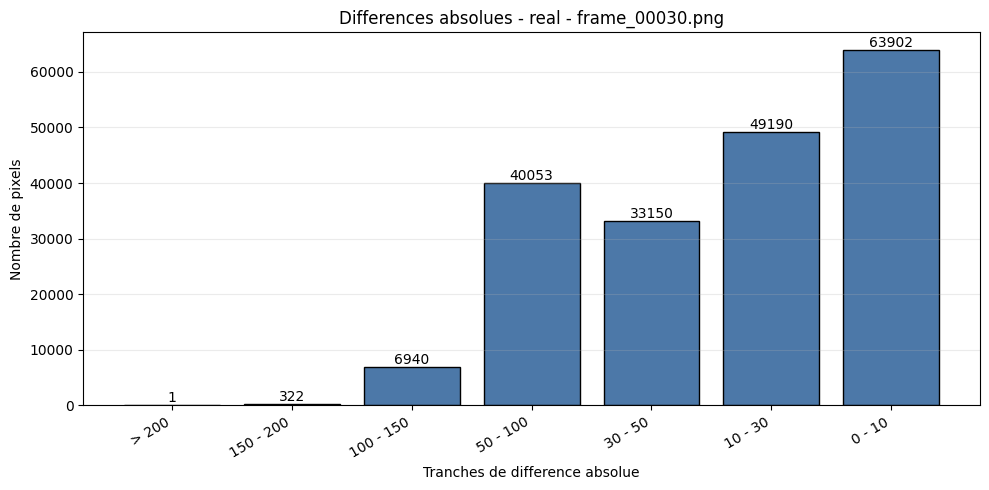

lvl:  4  initial error:  3466.8450570342206
 error improvement too small, level converged! it:  7  error:  1751.6647719061011  lambda:  12.8
lvl:  3  initial error:  2030.0959070852082
 error improvement too small, level converged! it:  12  error:  1848.4943683572312  lambda:  0.0
lvl:  2  initial error:  1892.152378557161
 error improvement too small, level converged! it:  3  error:  1871.4374037367902  lambda:  0.1
[real] frame 31 -> frame_00031.png | sum error = 395692128.00 | mean abs error = 33.4954 | valid pixels = 187154


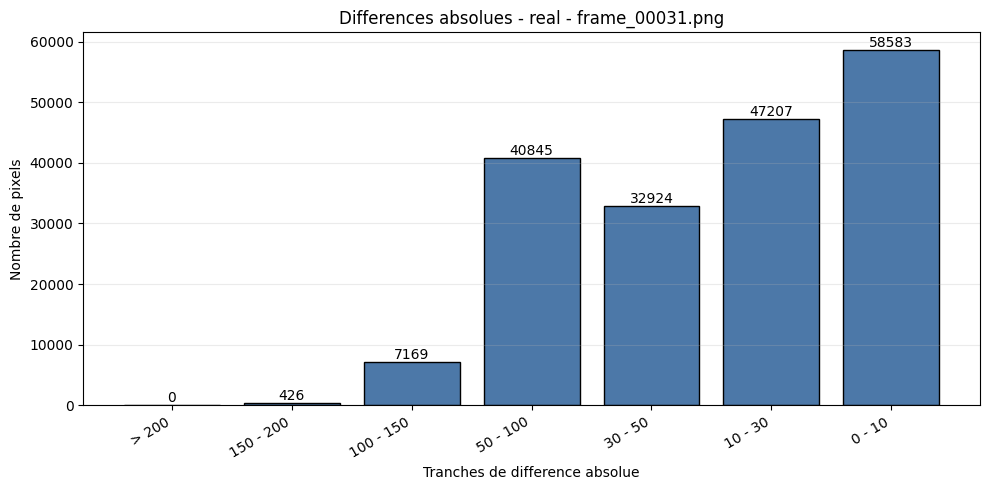

lvl:  4  initial error:  3563.9619771863117
 error improvement too small, level converged! it:  3  error:  1837.7766801936982  lambda:  102.4
lvl:  3  initial error:  1824.6405659915192
 error improvement too small, level converged! it:  2  error:  1807.0254209505233  lambda:  0.1
lvl:  2  initial error:  1915.3150761518386
 error improvement too small, level converged! it:  9  error:  1862.4937896377032  lambda:  0.0
[real] frame 32 -> frame_00032.png | sum error = 395558496.00 | mean abs error = 33.6111 | valid pixels = 186653


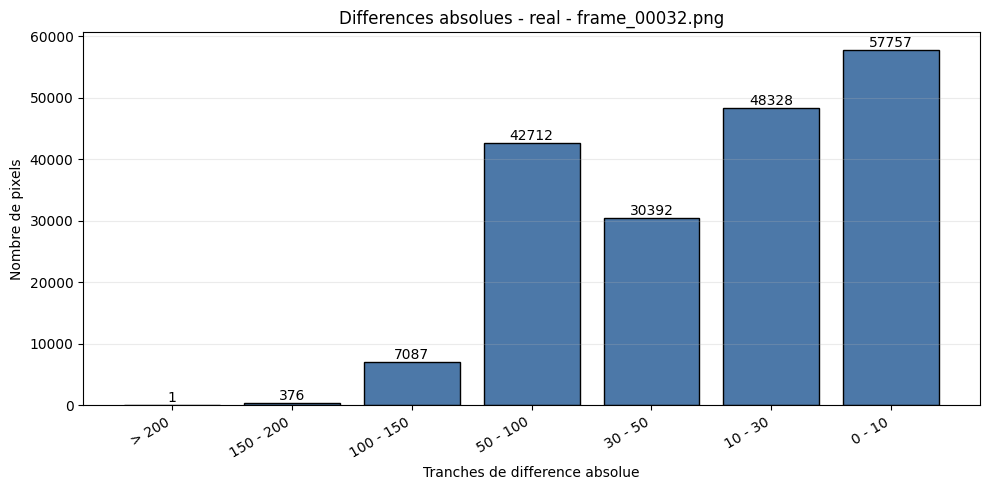

lvl:  4  initial error:  3483.050380228137
 error improvement too small, level converged! it:  3  error:  1727.76554429244  lambda:  0.2
lvl:  3  initial error:  1901.7126518650957
 error improvement too small, level converged! it:  2  error:  1842.0454898983617  lambda:  0.2
lvl:  2  initial error:  1894.032668355197
 error improvement too small, level converged! it:  1  error:  1893.8269036747301  lambda:  0.8
[real] frame 33 -> frame_00033.png | sum error = 409174464.00 | mean abs error = 33.7751 | valid pixels = 189890


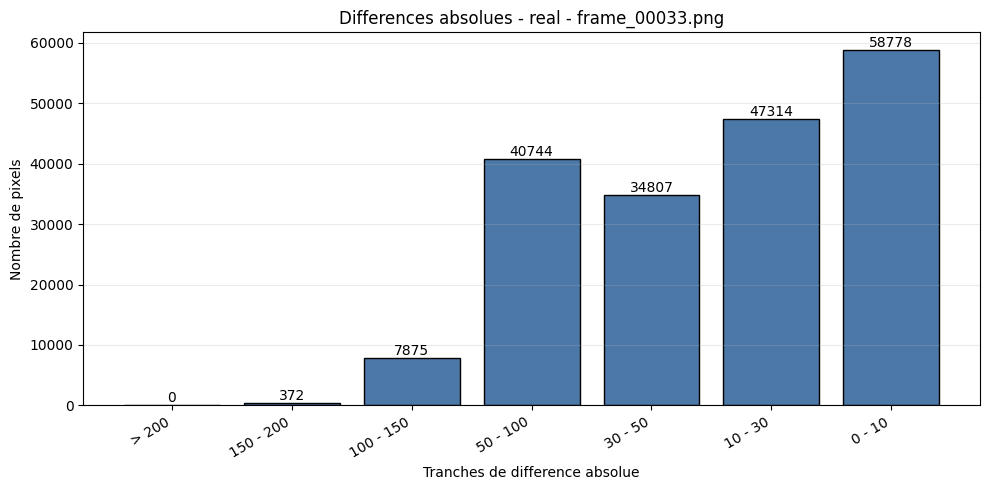

lvl:  4  initial error:  3407.9467680608363
 error improvement too small, level converged! it:  6  error:  1738.7982054286244  lambda:  25.6
lvl:  3  initial error:  1816.976109610594
 error improvement too small, level converged! it:  12  error:  1686.962758268534  lambda:  0.0
lvl:  2  initial error:  1819.9974708765901
 error improvement too small, level converged! it:  9  error:  1749.8687673712593  lambda:  0.0
[real] frame 34 -> frame_00034.png | sum error = 380471200.00 | mean abs error = 32.2854 | valid pixels = 190601


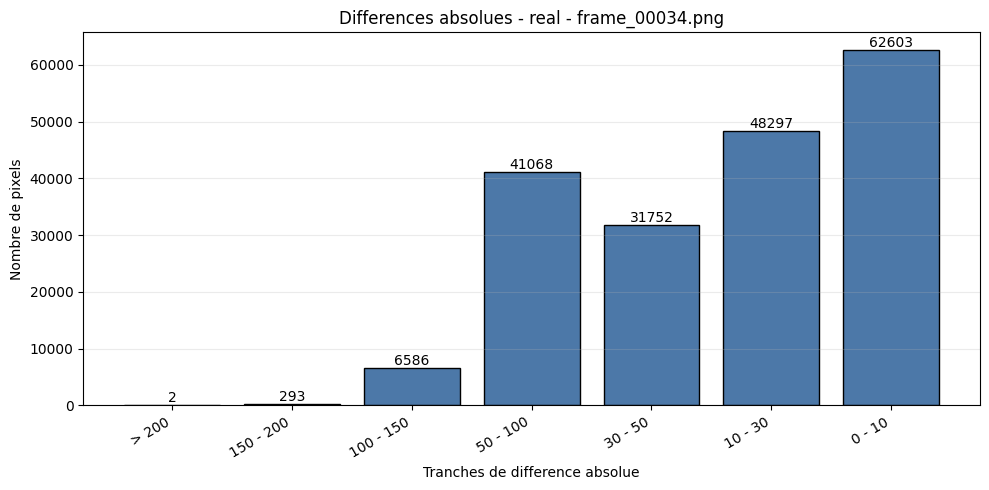

lvl:  4  initial error:  3389.5494296577945
 error improvement too small, level converged! it:  7  error:  1552.2570535463535  lambda:  3.2
lvl:  3  initial error:  1766.1391627052867
 error improvement too small, level converged! it:  2  error:  1676.406166944753  lambda:  0.0
lvl:  2  initial error:  1777.6499310021204
 error improvement too small, level converged! it:  23  error:  1582.2834073571426  lambda:  0.0
[real] frame 35 -> frame_00035.png | sum error = 368577440.00 | mean abs error = 30.2862 | valid pixels = 201255


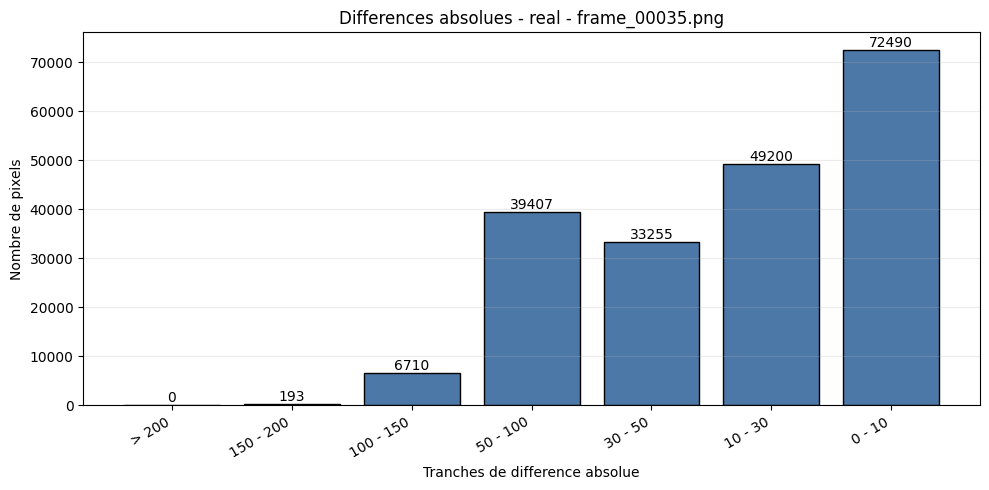

lvl:  4  initial error:  3327.479087452471
 error improvement too small, level converged! it:  6  error:  1456.1426432526341  lambda:  51.2
lvl:  3  initial error:  1663.7578894406397
 error improvement too small, level converged! it:  8  error:  1463.216764574749  lambda:  0.0
lvl:  2  initial error:  1573.1619946227718
 error improvement too small, level converged! it:  10  error:  1499.8469029962218  lambda:  0.0
[real] frame 36 -> frame_00036.png | sum error = 355878080.00 | mean abs error = 29.0719 | valid pixels = 205269


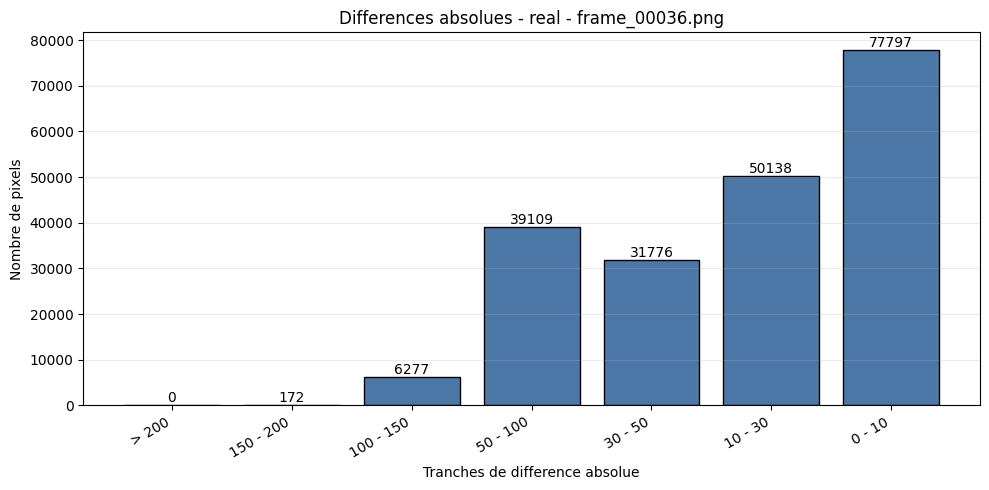

lvl:  4  initial error:  3361.1330798479084
 error improvement too small, level converged! it:  8  error:  1365.9197076418375  lambda:  3.2
lvl:  3  initial error:  1411.125652559013
 error improvement too small, level converged! it:  10  error:  1251.417480137289  lambda:  0.1
lvl:  2  initial error:  1402.218728638192
 error improvement too small, level converged! it:  13  error:  1352.0894390600417  lambda:  0.0
[real] frame 37 -> frame_00037.png | sum error = 333874496.00 | mean abs error = 27.3505 | valid pixels = 210580


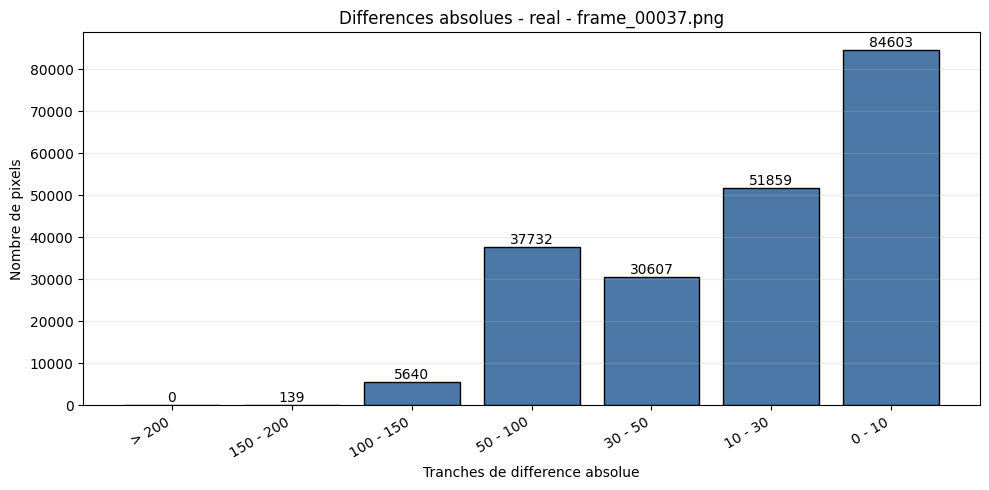

lvl:  4  initial error:  3389.8231939163493
 error improvement too small, level converged! it:  12  error:  1068.3136095558045  lambda:  28147497671065.6
lvl:  3  initial error:  1275.5286523674233
 error improvement too small, level converged! it:  7  error:  1127.986815736535  lambda:  0.0
lvl:  2  initial error:  1267.0929933851814
 error improvement too small, level converged! it:  18  error:  1193.5934121964617  lambda:  0.0
[real] frame 38 -> frame_00038.png | sum error = 327811296.00 | mean abs error = 25.0876 | valid pixels = 229280


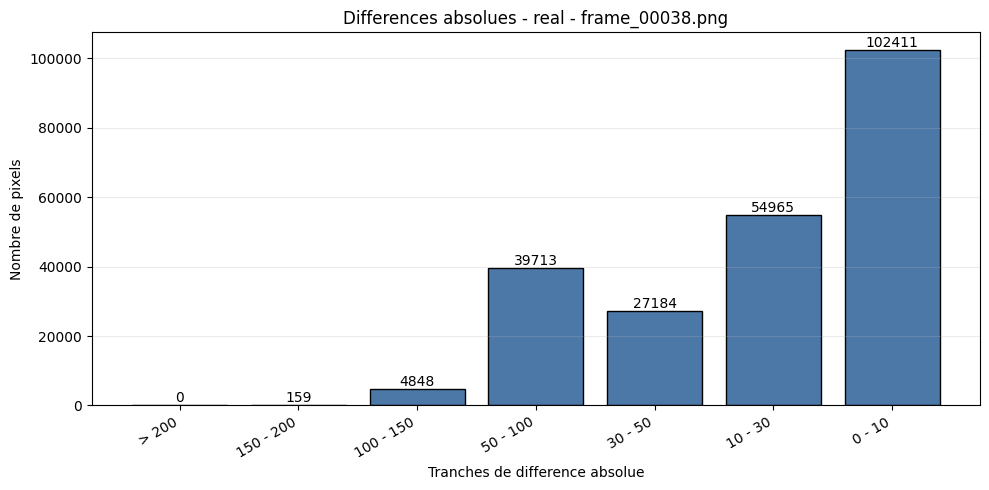

lvl:  4  initial error:  3185.7642585551325
 error improvement too small, level converged! it:  4  error:  997.2467855999114  lambda:  12.8
lvl:  3  initial error:  1200.8891405536888
 error improvement too small, level converged! it:  4  error:  1030.8995192175923  lambda:  0.0
lvl:  2  initial error:  1126.4983793763508
 error improvement too small, level converged! it:  4  error:  1110.1904149105033  lambda:  0.0
[real] frame 39 -> frame_00039.png | sum error = 326241504.00 | mean abs error = 24.0073 | valid pixels = 241270


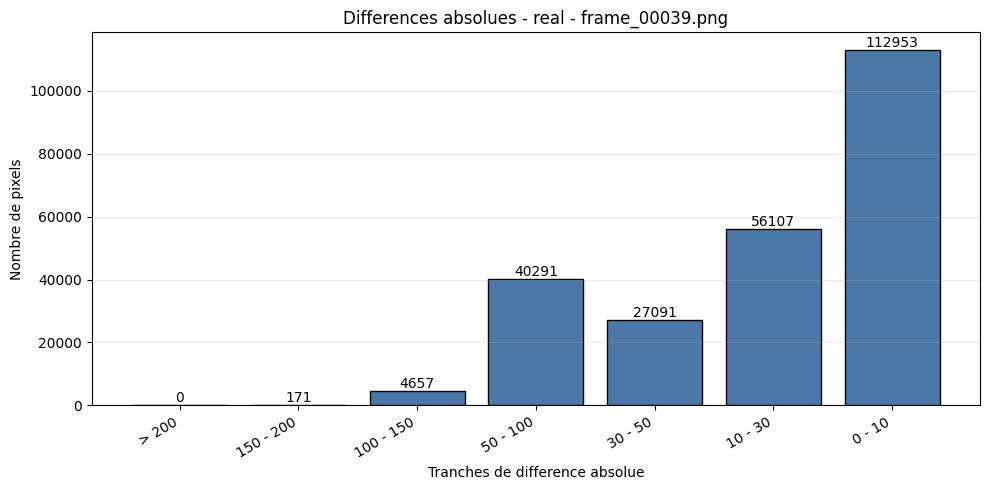

lvl:  4  initial error:  2690.884030418251
 error improvement too small, level converged! it:  12  error:  825.3247581445723  lambda:  0.0
lvl:  3  initial error:  1055.259481743264
update too small, level converged! it:  4  error:  795.8478335051044  lambda:  225179981368524.8
lvl:  2  initial error:  870.1641490101433
 error improvement too small, level converged! it:  8  error:  845.2713451978329  lambda:  0.0
[real] frame 40 -> frame_00040.png | sum error = 280590880.00 | mean abs error = 19.6242 | valid pixels = 262647


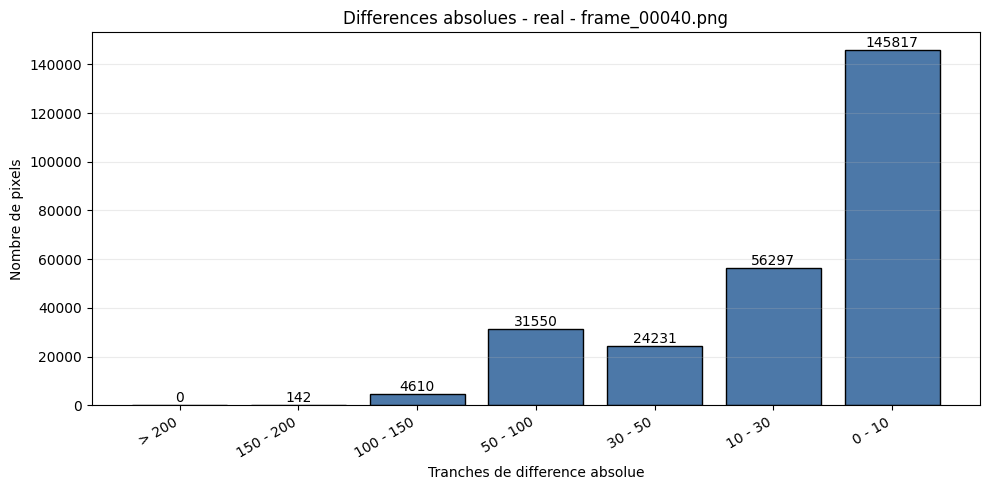

lvl:  4  initial error:  2438.201520912547
 error improvement too small, level converged! it:  7  error:  755.6370381365114  lambda:  0.0
lvl:  3  initial error:  711.0718303338068
 error improvement too small, level converged! it:  4  error:  666.0950879191556  lambda:  0.0
lvl:  2  initial error:  699.4941662939077
 error improvement too small, level converged! it:  4  error:  688.8628108376558  lambda:  0.0
[real] frame 41 -> frame_00041.png | sum error = 241641984.00 | mean abs error = 16.9564 | valid pixels = 270919


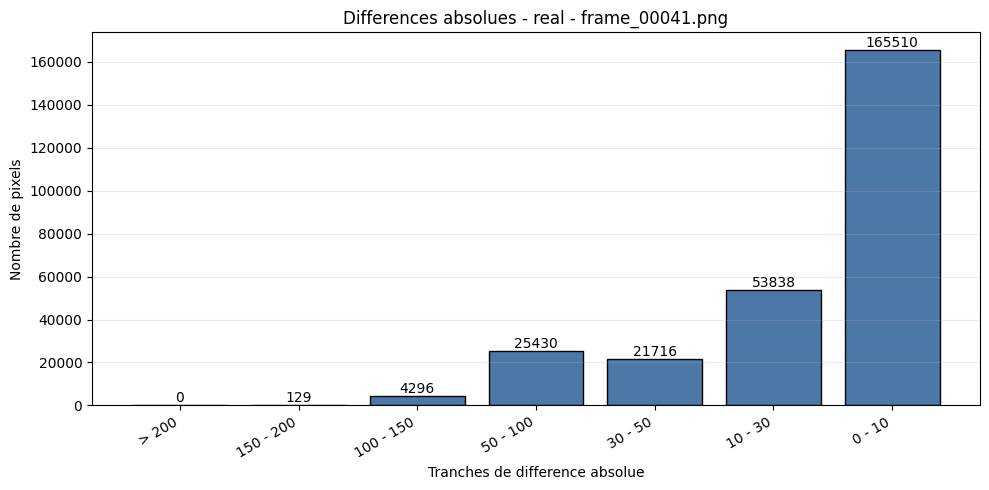

lvl:  4  initial error:  2176.759505703422
 error improvement too small, level converged! it:  6  error:  602.545470517115  lambda:  0.2
lvl:  3  initial error:  633.3545274412264
 error improvement too small, level converged! it:  5  error:  551.2149738043622  lambda:  0.2
lvl:  2  initial error:  599.3011372082382
 error improvement too small, level converged! it:  5  error:  590.0937788585857  lambda:  0.0
[real] frame 42 -> frame_00042.png | sum error = 218342000.00 | mean abs error = 15.2433 | valid pixels = 278859


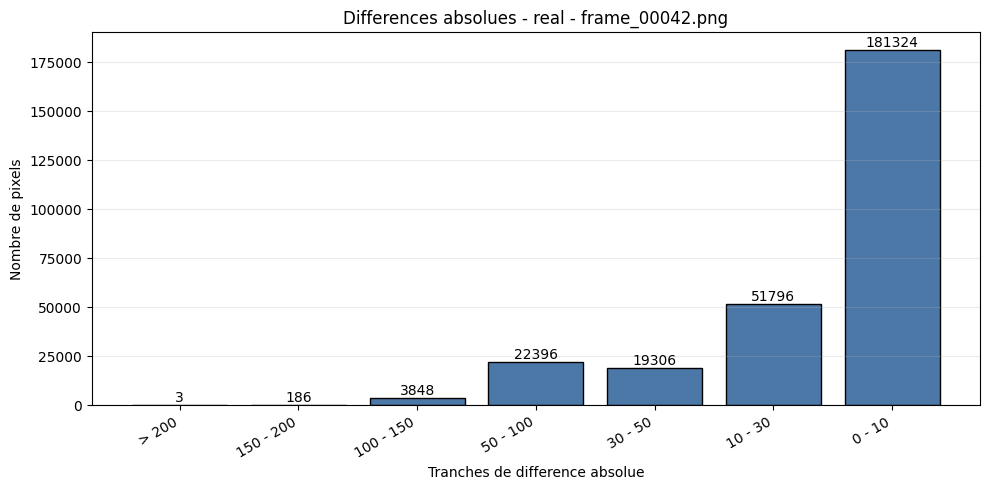

lvl:  4  initial error:  2096.981939163498
 error improvement too small, level converged! it:  5  error:  658.8818702560702  lambda:  25.6
lvl:  3  initial error:  605.1777399152983
 error improvement too small, level converged! it:  3  error:  580.1374056765693  lambda:  0.0
lvl:  2  initial error:  605.3803175686871
 error improvement too small, level converged! it:  4  error:  598.3256571759268  lambda:  879609302220.8
[real] frame 43 -> frame_00043.png | sum error = 223251264.00 | mean abs error = 15.6543 | valid pixels = 274933


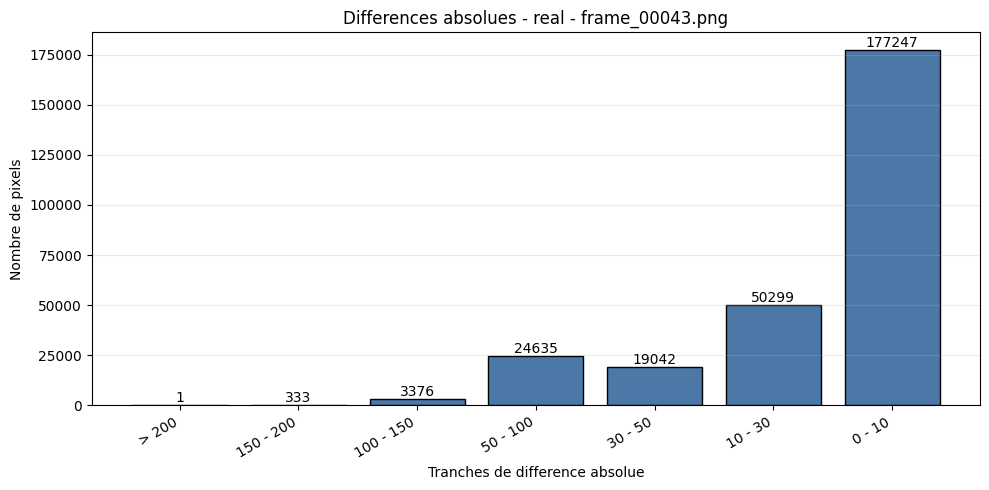

lvl:  4  initial error:  2285.4458174904935
 error improvement too small, level converged! it:  4  error:  755.7047413417591  lambda:  0.1
lvl:  3  initial error:  696.2785022352272
 error improvement too small, level converged! it:  4  error:  663.8050328294285  lambda:  0.0
lvl:  2  initial error:  677.9240025056429
 error improvement too small, level converged! it:  2  error:  673.8122533402922  lambda:  0.0
[real] frame 44 -> frame_00044.png | sum error = 239924240.00 | mean abs error = 16.6955 | valid pixels = 269108


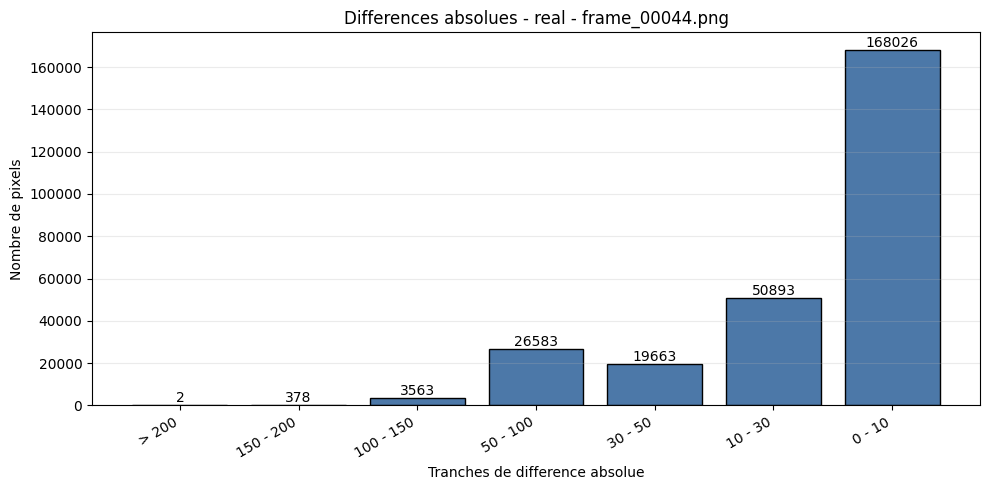

lvl:  4  initial error:  2521.5503802281364
 error improvement too small, level converged! it:  4  error:  826.9935340250447  lambda:  0.4
lvl:  3  initial error:  788.017374214613
 error improvement too small, level converged! it:  4  error:  768.1479034019909  lambda:  0.0
lvl:  2  initial error:  809.827269984572
 error improvement too small, level converged! it:  3  error:  806.1942633297747  lambda:  0.4
[real] frame 45 -> frame_00045.png | sum error = 270223008.00 | mean abs error = 18.1953 | valid pixels = 262498


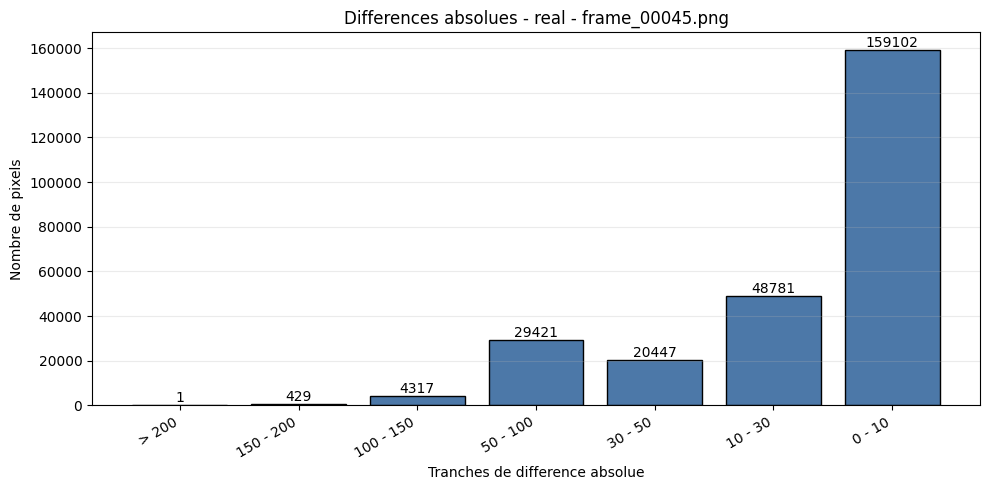

lvl:  4  initial error:  2554.854562737642
 error improvement too small, level converged! it:  4  error:  892.4206513903797  lambda:  28147497671065.6
lvl:  3  initial error:  843.8201430120898
 error improvement too small, level converged! it:  3  error:  839.513819966279  lambda:  3435973836.8
lvl:  2  initial error:  872.6483473938157
 error improvement too small, level converged! it:  6  error:  862.2808690890238  lambda:  1.6
[real] frame 46 -> frame_00046.png | sum error = 281989216.00 | mean abs error = 18.8639 | valid pixels = 259954


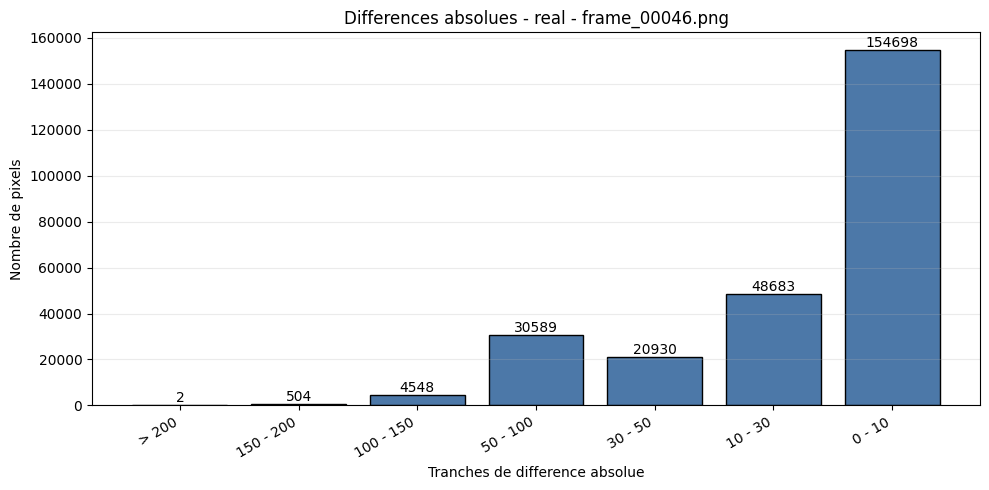

lvl:  4  initial error:  2717.463878326996
 error improvement too small, level converged! it:  4  error:  880.6606998505403  lambda:  56294995342131.2
lvl:  3  initial error:  895.3175045664962
 error improvement too small, level converged! it:  4  error:  864.0045042579832  lambda:  0.0
lvl:  2  initial error:  927.1266432800355
 error improvement too small, level converged! it:  2  error:  924.9227799824027  lambda:  6.4
[real] frame 47 -> frame_00047.png | sum error = 297102272.00 | mean abs error = 19.7576 | valid pixels = 256566


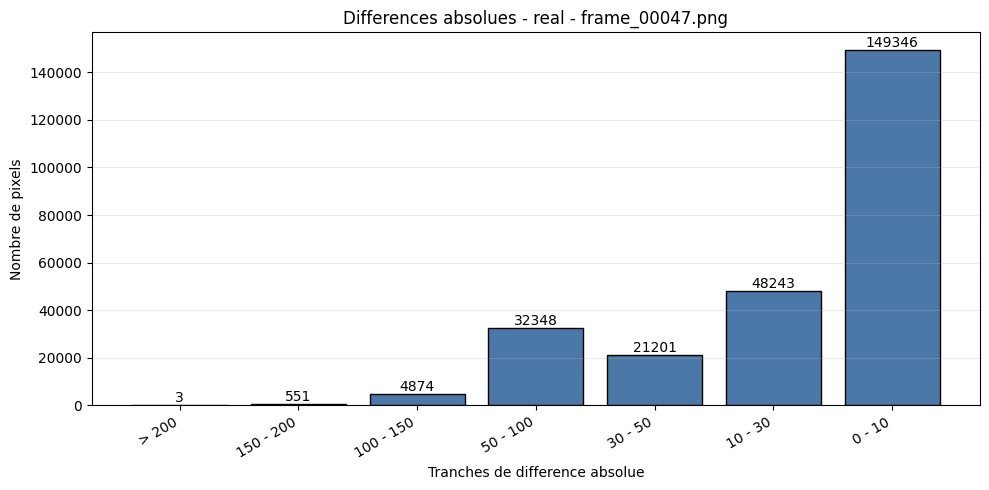

lvl:  4  initial error:  2650.0741444866917
 error improvement too small, level converged! it:  5  error:  902.6470101498  lambda:  0.0
lvl:  3  initial error:  910.5048311970297
 error improvement too small, level converged! it:  4  error:  855.7708612982979  lambda:  0.1
lvl:  2  initial error:  920.3607950784588
 error improvement too small, level converged! it:  4  error:  914.3248718219269  lambda:  12.8
[real] frame 48 -> frame_00048.png | sum error = 295468288.00 | mean abs error = 19.5254 | valid pixels = 258622


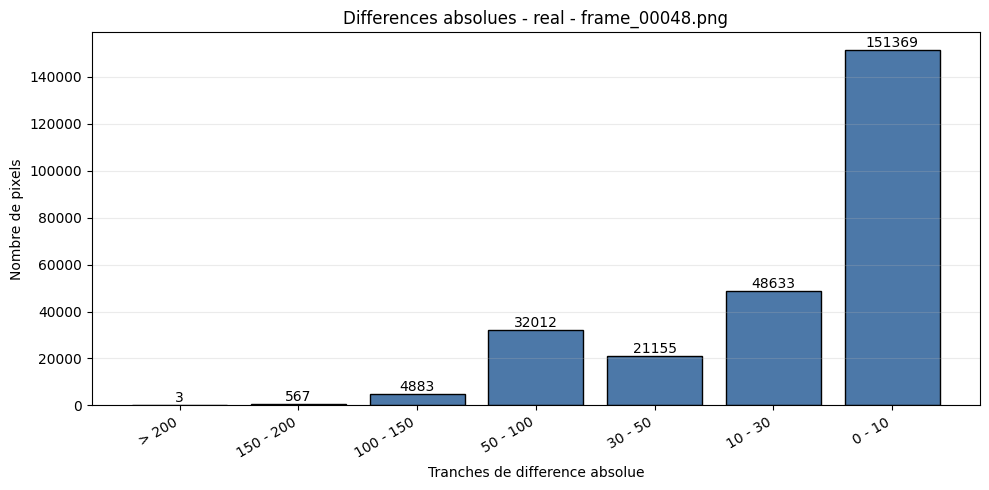

lvl:  4  initial error:  2512.5
 error improvement too small, level converged! it:  7  error:  859.2536040190429  lambda:  0.0
lvl:  3  initial error:  873.6329491922221
 error improvement too small, level converged! it:  3  error:  815.6656913852817  lambda:  0.0
lvl:  2  initial error:  869.3812916517975
 error improvement too small, level converged! it:  9  error:  842.1449322074955  lambda:  3.2
[real] frame 49 -> frame_00049.png | sum error = 279190336.00 | mean abs error = 18.4160 | valid pixels = 262925


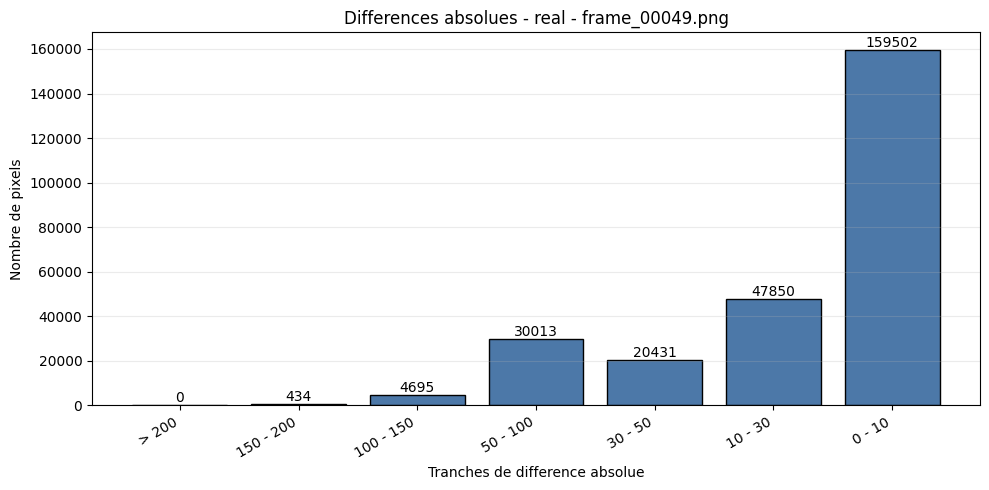

lvl:  4  initial error:  2272.225285171102
 error improvement too small, level converged! it:  8  error:  743.3182763389569  lambda:  0.0
lvl:  3  initial error:  713.1259187802189
 error improvement too small, level converged! it:  4  error:  699.1099237795063  lambda:  109951162777.6
lvl:  2  initial error:  730.3833375631633
 error improvement too small, level converged! it:  7  error:  719.153214201202  lambda:  0.0
[real] frame 50 -> frame_00050.png | sum error = 250468448.00 | mean abs error = 17.1046 | valid pixels = 268855


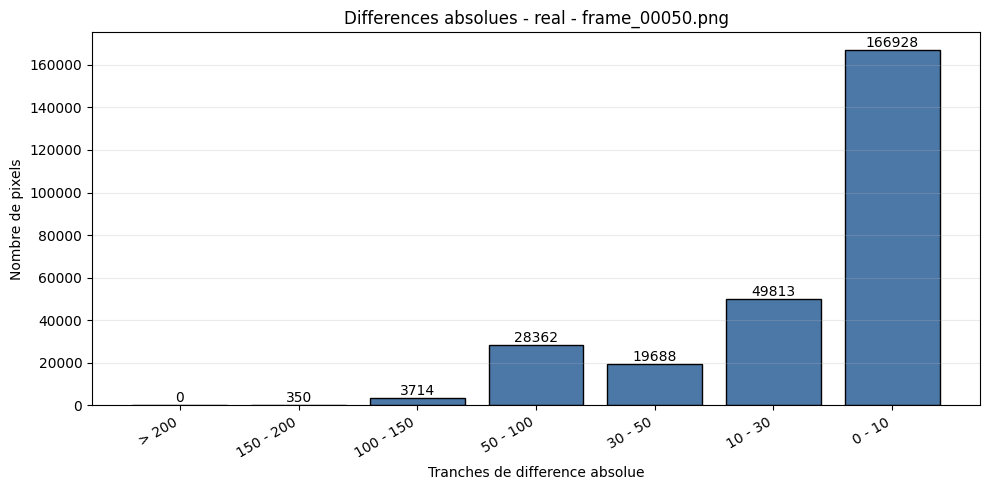

lvl:  4  initial error:  2076.3051330798476
 error improvement too small, level converged! it:  5  error:  616.4991365622114  lambda:  0.1
lvl:  3  initial error:  649.5921704110731
 error improvement too small, level converged! it:  3  error:  580.8370696764531  lambda:  7036874417766.4
lvl:  2  initial error:  614.6637252459135
 error improvement too small, level converged! it:  4  error:  606.391595754318  lambda:  0.0
[real] frame 51 -> frame_00051.png | sum error = 224731456.00 | mean abs error = 15.8715 | valid pixels = 273783


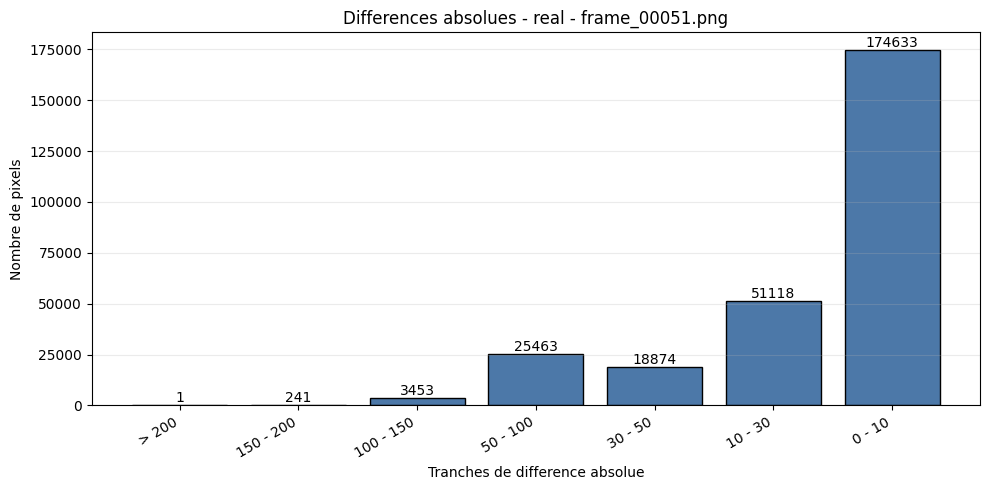

lvl:  4  initial error:  2156.1958174904944
 error improvement too small, level converged! it:  5  error:  545.7909755760091  lambda:  0.1
lvl:  3  initial error:  583.5882638294727
 error improvement too small, level converged! it:  3  error:  502.7158200965529  lambda:  0.0
lvl:  2  initial error:  523.297730039286
 error improvement too small, level converged! it:  3  error:  516.4940559462383  lambda:  6.4
[real] frame 52 -> frame_00052.png | sum error = 195282992.00 | mean abs error = 14.3513 | valid pixels = 277549


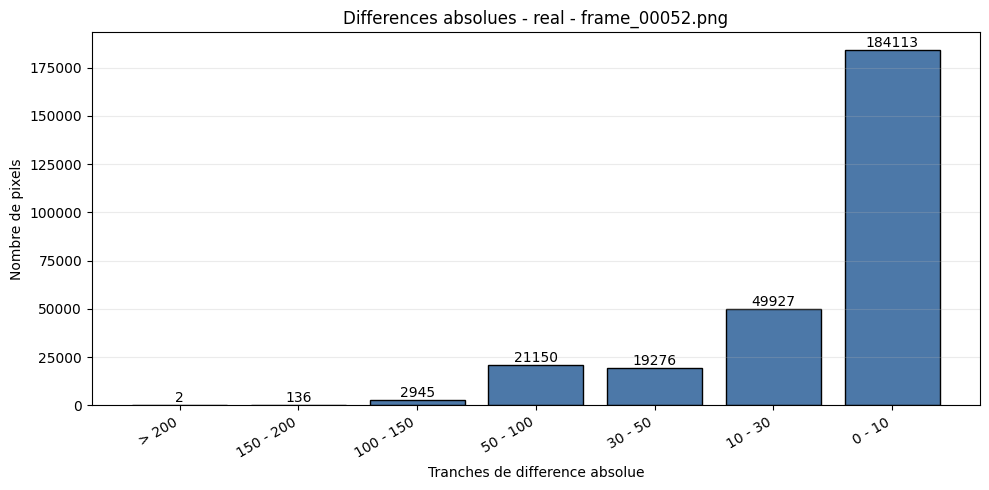

lvl:  4  initial error:  2621.817490494296
 error improvement too small, level converged! it:  4  error:  692.9712371311662  lambda:  0.2
lvl:  3  initial error:  693.6346242498577
 error improvement too small, level converged! it:  3  error:  643.7348325205606  lambda:  0.8
lvl:  2  initial error:  704.0556047578224
 error improvement too small, level converged! it:  6  error:  692.0894868533992  lambda:  0.0
[real] frame 53 -> frame_00053.png | sum error = 241106528.00 | mean abs error = 17.1026 | valid pixels = 267917


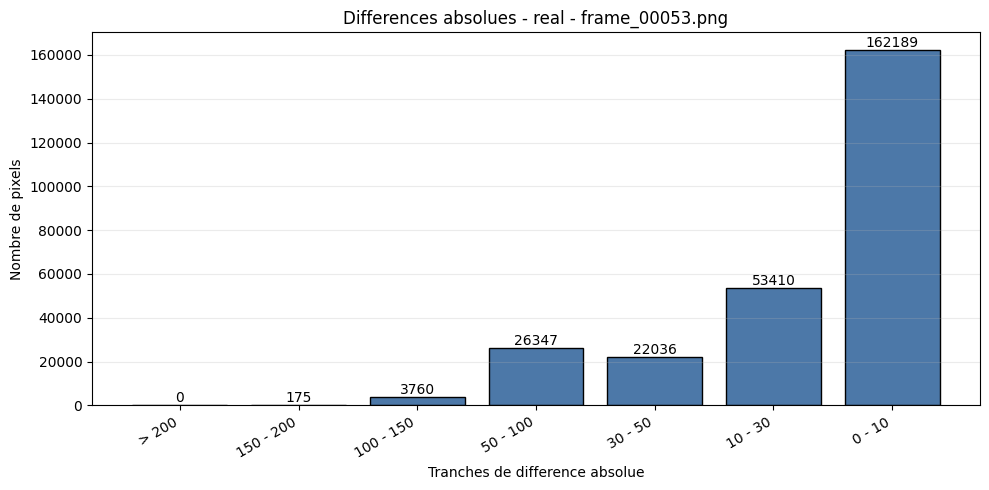

lvl:  4  initial error:  2921.2975285171096
 error improvement too small, level converged! it:  4  error:  919.3334206425095  lambda:  28147497671065.6
lvl:  3  initial error:  896.323549251173
 error improvement too small, level converged! it:  5  error:  856.5475006877635  lambda:  51.2
lvl:  2  initial error:  911.4420870360932
 error improvement too small, level converged! it:  5  error:  897.4079232776593  lambda:  0.0
[real] frame 54 -> frame_00054.png | sum error = 289704352.00 | mean abs error = 20.2687 | valid pixels = 258851


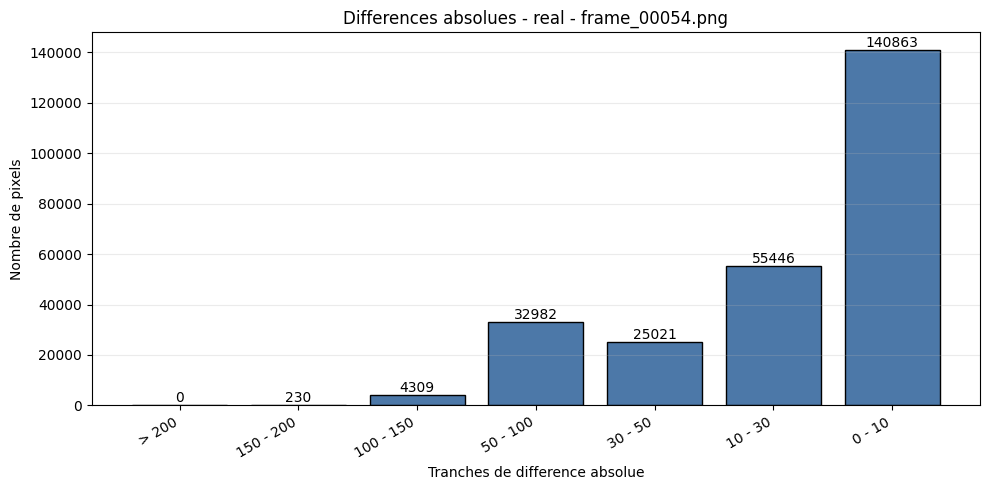

lvl:  4  initial error:  3280.9657794676805
 error improvement too small, level converged! it:  10  error:  1033.563434063425  lambda:  25.6
lvl:  3  initial error:  1398.7447420902163
 error improvement too small, level converged! it:  10  error:  1094.8017008300653  lambda:  0.0
lvl:  2  initial error:  1230.3039790015741
 error improvement too small, level converged! it:  4  error:  1212.7730125589492  lambda:  0.0
[real] frame 55 -> frame_00055.png | sum error = 341040960.00 | mean abs error = 25.2421 | valid pixels = 236491


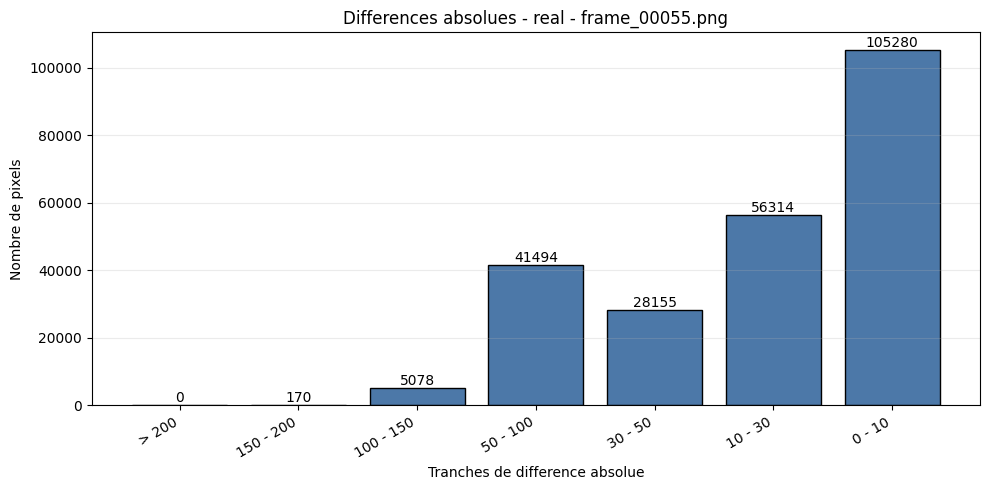

lvl:  4  initial error:  3289.762357414448
 error improvement too small, level converged! it:  5  error:  1218.871174773707  lambda:  14073748835532.8
lvl:  3  initial error:  1486.7705096603343
 error improvement too small, level converged! it:  13  error:  1137.873832645192  lambda:  0.0
lvl:  2  initial error:  1238.0545572663225
 error improvement too small, level converged! it:  2  error:  1229.89195493184  lambda:  0.0
[real] frame 56 -> frame_00056.png | sum error = 325926048.00 | mean abs error = 25.8088 | valid pixels = 221272


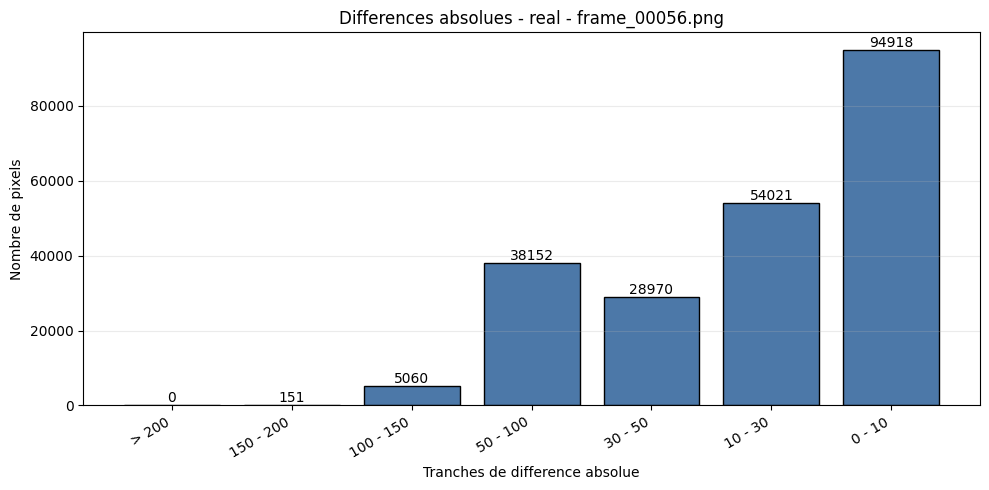

lvl:  4  initial error:  3397.553231939163
 error improvement too small, level converged! it:  4  error:  1777.3091294277135  lambda:  51.2
lvl:  3  initial error:  1809.3399427415775
 error improvement too small, level converged! it:  6  error:  1649.1589135965908  lambda:  1759218604441.6
lvl:  2  initial error:  1778.0415829013955
 error improvement too small, level converged! it:  11  error:  1712.6061223498043  lambda:  0.0
[real] frame 57 -> frame_00057.png | sum error = 405332064.00 | mean abs error = 29.9784 | valid pixels = 210017


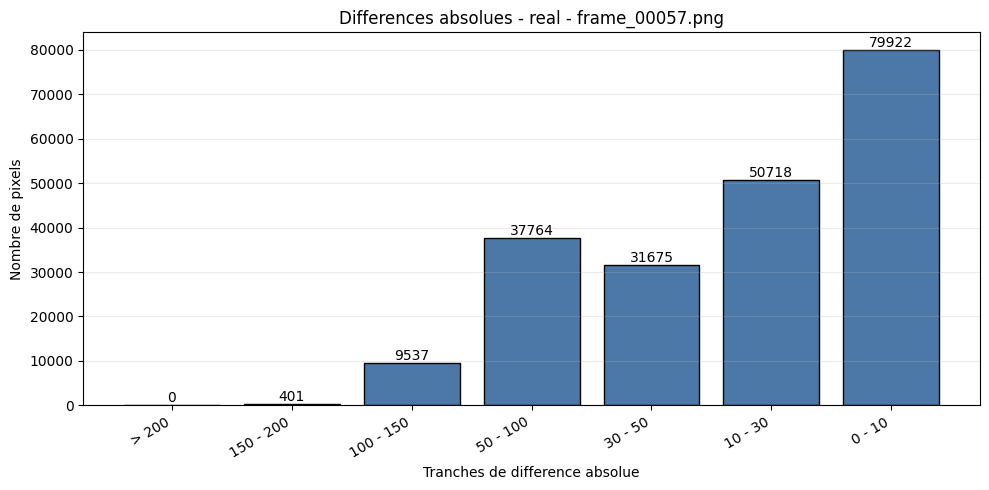

lvl:  4  initial error:  3446.5608365019007
 error improvement too small, level converged! it:  2  error:  1798.7603570732433  lambda:  0.2
lvl:  3  initial error:  1900.7234595760365
 error improvement too small, level converged! it:  1  error:  1900.4448338423251  lambda:  12.8
lvl:  2  initial error:  1917.212043072456
 error improvement too small, level converged! it:  2  error:  1914.6281239109062  lambda:  0.1
[real] frame 58 -> frame_00058.png | sum error = 446924832.00 | mean abs error = 31.4238 | valid pixels = 208763


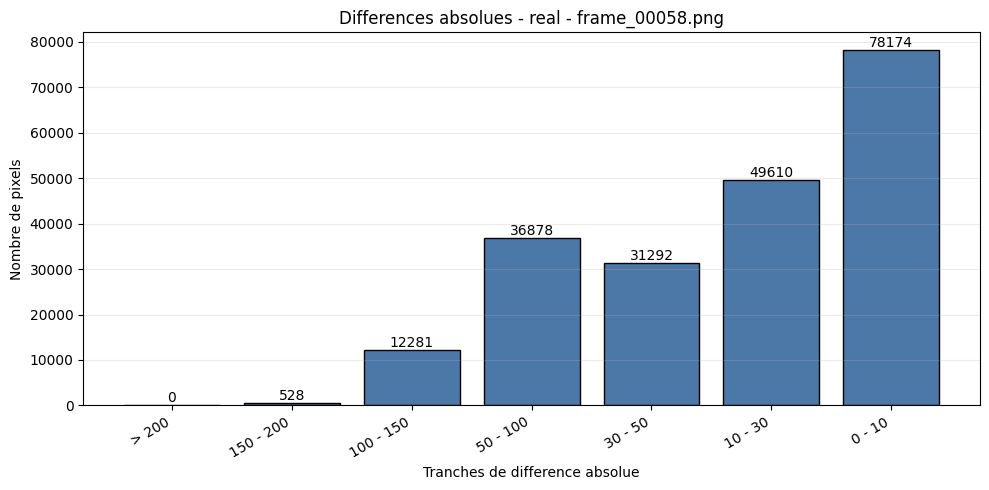

lvl:  4  initial error:  3416.9543726235743
 error improvement too small, level converged! it:  4  error:  2028.0032863116976  lambda:  0.1
lvl:  3  initial error:  1938.1287727812503
 error improvement too small, level converged! it:  2  error:  1936.0327580218172  lambda:  0.2
lvl:  2  initial error:  2021.2783179223977
 error improvement too small, level converged! it:  5  error:  2009.460103159198  lambda:  0.0
[real] frame 59 -> frame_00059.png | sum error = 467579200.00 | mean abs error = 32.2354 | valid pixels = 207536


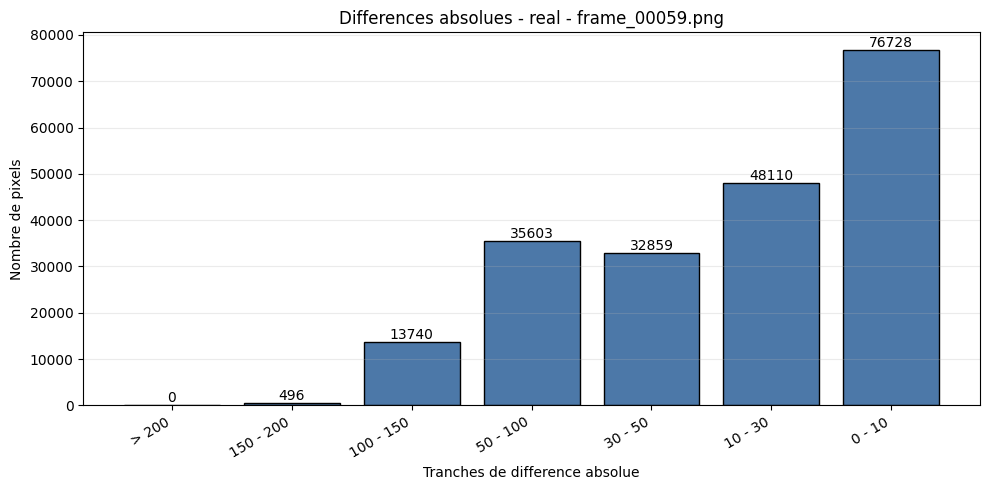

lvl:  4  initial error:  3439.9600760456274
 error improvement too small, level converged! it:  4  error:  2096.585839309462  lambda:  25.6
lvl:  3  initial error:  2089.806350047555
 error improvement too small, level converged! it:  4  error:  2026.2741882418152  lambda:  0.0
lvl:  2  initial error:  2059.663949200008
 error improvement too small, level converged! it:  2  error:  2054.3258601833477  lambda:  0.0
[real] frame 60 -> frame_00060.png | sum error = 472916960.00 | mean abs error = 32.6154 | valid pixels = 206211


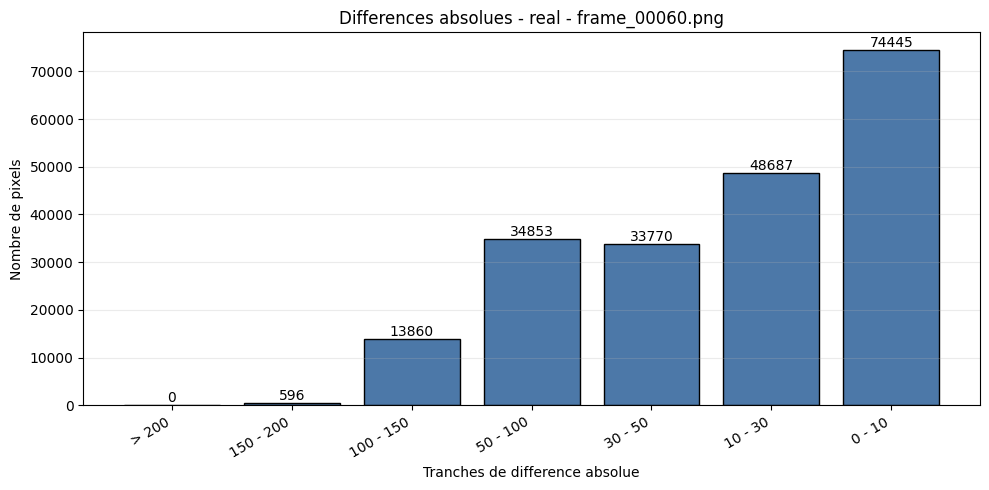

lvl:  4  initial error:  3544.733840304182
 error improvement too small, level converged! it:  5  error:  2157.8003257648575  lambda:  0.0
lvl:  3  initial error:  2218.3377403177906
 error improvement too small, level converged! it:  7  error:  2116.1485785146915  lambda:  0.0
lvl:  2  initial error:  2147.7397371746697
 error improvement too small, level converged! it:  5  error:  2134.817532495147  lambda:  0.0
[real] frame 61 -> frame_00061.png | sum error = 486409056.00 | mean abs error = 33.2397 | valid pixels = 204242


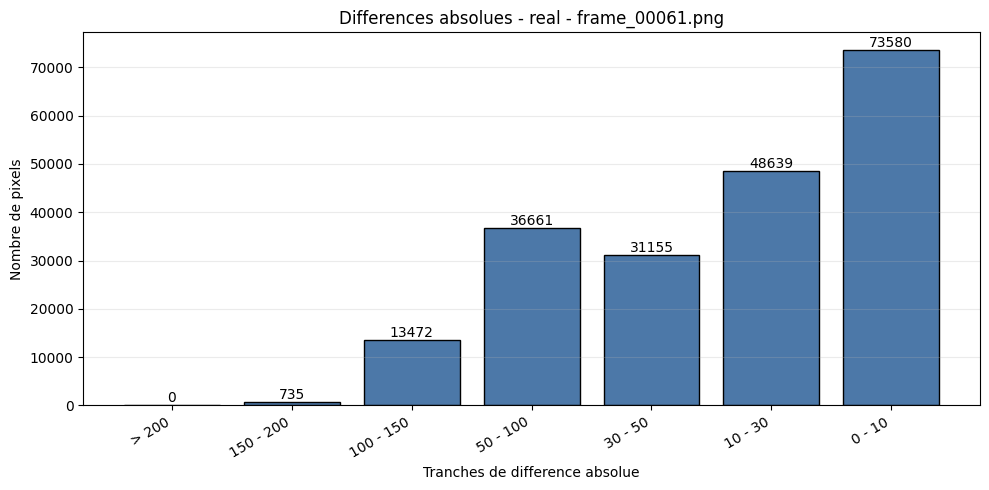

lvl:  4  initial error:  3555.773764258555
 error improvement too small, level converged! it:  4  error:  2010.1046350884974  lambda:  0.0
lvl:  3  initial error:  2082.8173584761025
 error improvement too small, level converged! it:  2  error:  2053.8247342715363  lambda:  0.4
lvl:  2  initial error:  2170.7471578300256
 error improvement too small, level converged! it:  2  error:  2166.2801616091983  lambda:  0.0
[real] frame 62 -> frame_00062.png | sum error = 491209664.00 | mean abs error = 33.7810 | valid pixels = 202380


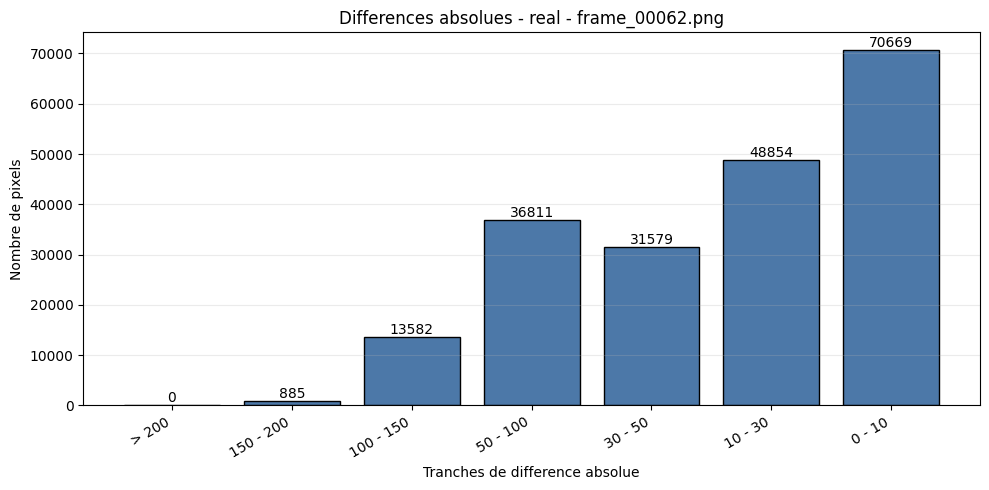

lvl:  4  initial error:  3599.6387832699616
 error improvement too small, level converged! it:  3  error:  2095.641603218813  lambda:  102.4
lvl:  3  initial error:  2104.170249415105
 error improvement too small, level converged! it:  5  error:  2037.693778825977  lambda:  0.2
lvl:  2  initial error:  2173.698401093442
 error improvement too small, level converged! it:  10  error:  2123.5334893856743  lambda:  0.0
[real] frame 63 -> frame_00063.png | sum error = 482651648.00 | mean abs error = 33.4881 | valid pixels = 201816


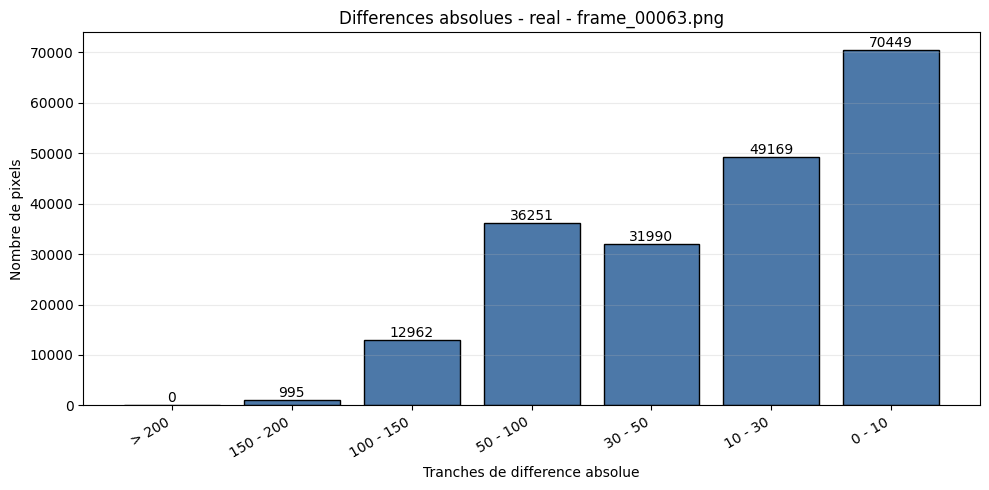

lvl:  4  initial error:  3471.5019011406844
 error improvement too small, level converged! it:  3  error:  2075.336022852334  lambda:  12.8
lvl:  3  initial error:  2166.281626860314
 error improvement too small, level converged! it:  7  error:  2041.351156732305  lambda:  0.0
lvl:  2  initial error:  2124.4491329338907
 error improvement too small, level converged! it:  7  error:  2096.964780493705  lambda:  0.0
[real] frame 64 -> frame_00064.png | sum error = 474628864.00 | mean abs error = 33.1136 | valid pixels = 202034


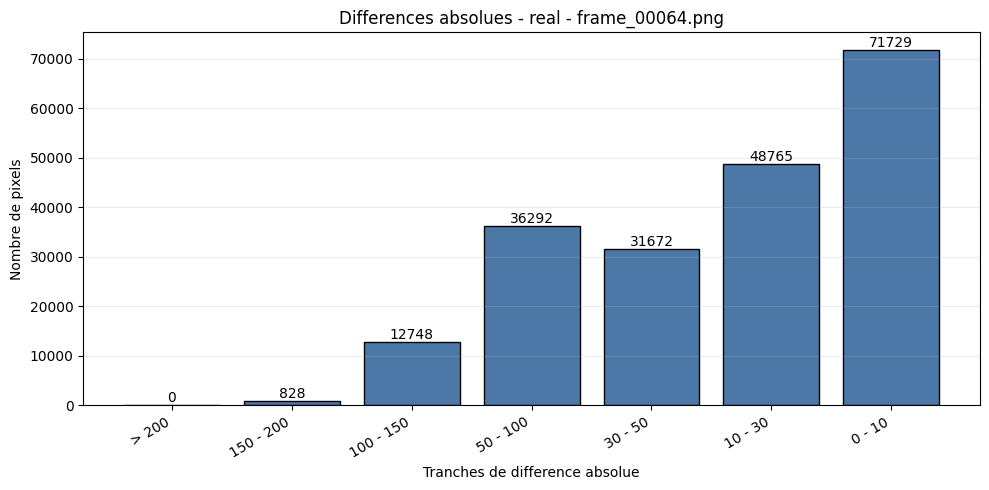

lvl:  4  initial error:  3504.554182509505
 error improvement too small, level converged! it:  8  error:  1930.7856387001211  lambda:  3.2
lvl:  3  initial error:  2202.2852642975913
 error improvement too small, level converged! it:  6  error:  1980.7640455270077  lambda:  0.0
lvl:  2  initial error:  2142.5566097302003
 error improvement too small, level converged! it:  2  error:  2135.3149797761685  lambda:  0.0
[real] frame 65 -> frame_00065.png | sum error = 482893344.00 | mean abs error = 33.4627 | valid pixels = 202639


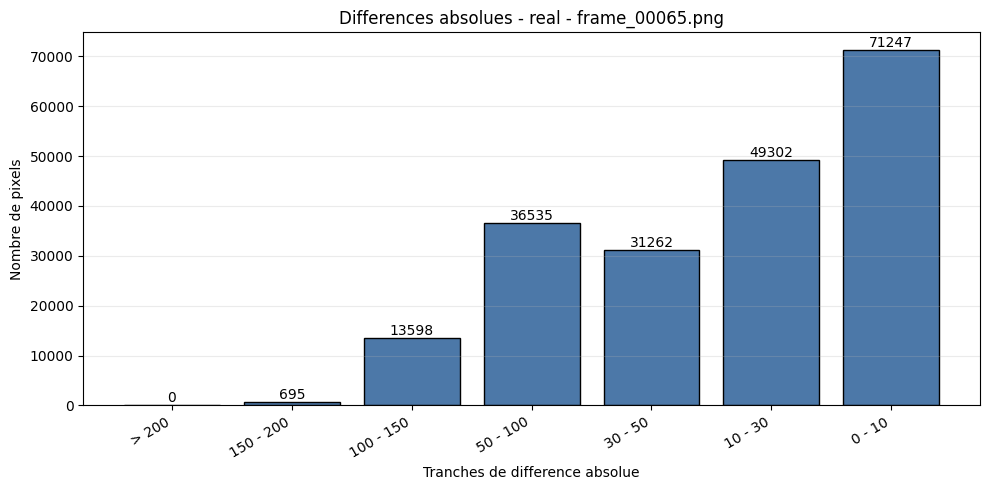

lvl:  4  initial error:  3407.3032319391637
 error improvement too small, level converged! it:  12  error:  1975.56382857187  lambda:  0.1
lvl:  3  initial error:  2160.0125603783918
 error improvement too small, level converged! it:  8  error:  1940.3528447765923  lambda:  51.2
lvl:  2  initial error:  2031.3950264063535
 error improvement too small, level converged! it:  3  error:  2018.5817126057757  lambda:  0.0
[real] frame 66 -> frame_00066.png | sum error = 467626688.00 | mean abs error = 32.6940 | valid pixels = 205909


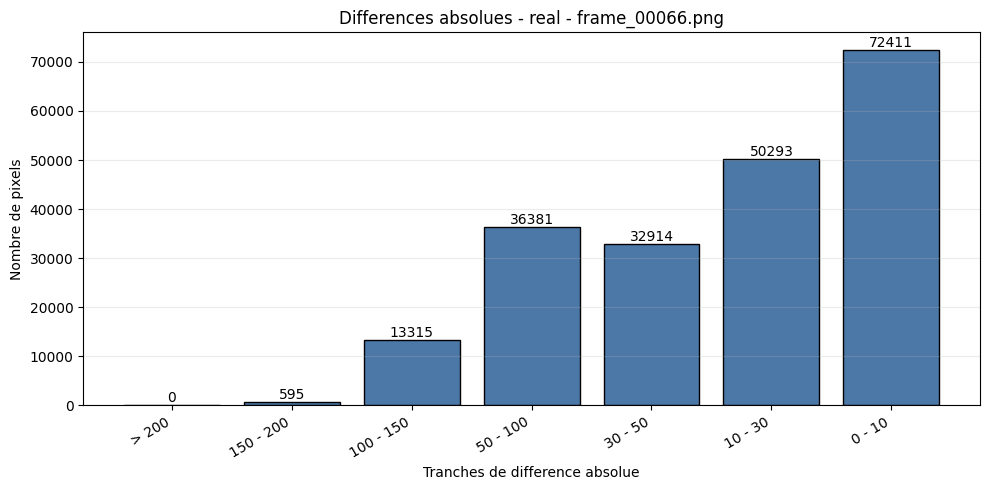

lvl:  4  initial error:  3387.4163498098856
 error improvement too small, level converged! it:  13  error:  1961.5831381797236  lambda:  0.4
lvl:  3  initial error:  1972.3876752715869
 error improvement too small, level converged! it:  4  error:  1933.9203963688644  lambda:  0.0
lvl:  2  initial error:  2037.4144007532316
 error improvement too small, level converged! it:  1  error:  2036.8023737145968  lambda:  0.0
[real] frame 67 -> frame_00067.png | sum error = 471589120.00 | mean abs error = 33.9230 | valid pixels = 204595


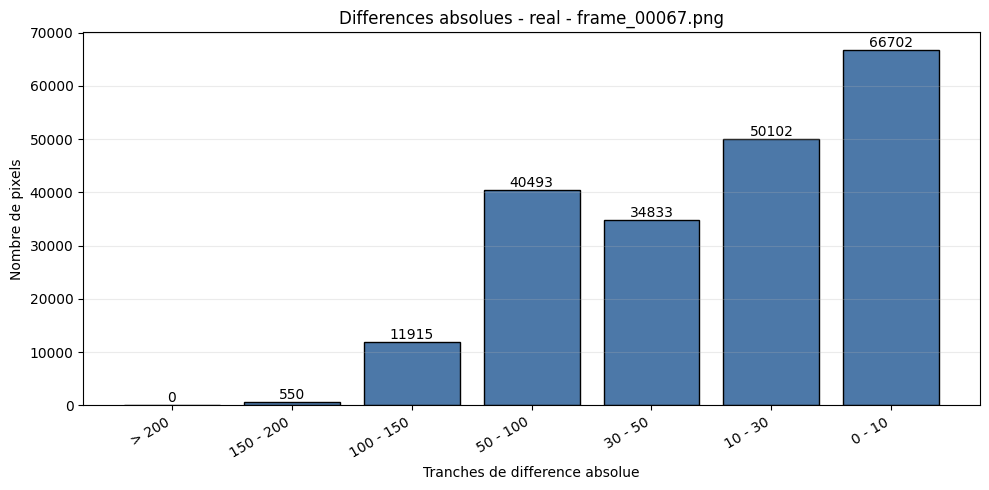

lvl:  4  initial error:  3297.009505703422
 error improvement too small, level converged! it:  7  error:  1633.7953191820918  lambda:  0.1
lvl:  3  initial error:  1673.9163877595593
 error improvement too small, level converged! it:  16  error:  1501.9471597336615  lambda:  0.0
lvl:  2  initial error:  1622.1373171902874
 error improvement too small, level converged! it:  7  error:  1566.1556477528131  lambda:  0.0
[real] frame 68 -> frame_00068.png | sum error = 371370944.00 | mean abs error = 30.0403 | valid pixels = 205574


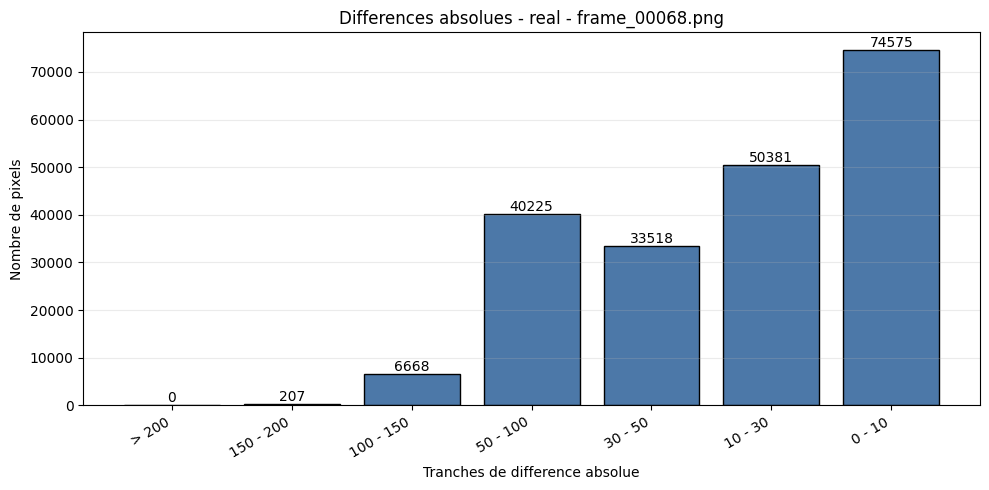

lvl:  4  initial error:  3289.0826996197716
 error improvement too small, level converged! it:  6  error:  1483.2586073966072  lambda:  0.1
lvl:  3  initial error:  1502.5529601693618
 error improvement too small, level converged! it:  11  error:  1402.926394804372  lambda:  0.0
lvl:  2  initial error:  1553.8348762806493
 error improvement too small, level converged! it:  12  error:  1471.1425826597317  lambda:  0.0
[real] frame 69 -> frame_00069.png | sum error = 359618784.00 | mean abs error = 28.8558 | valid pixels = 209503


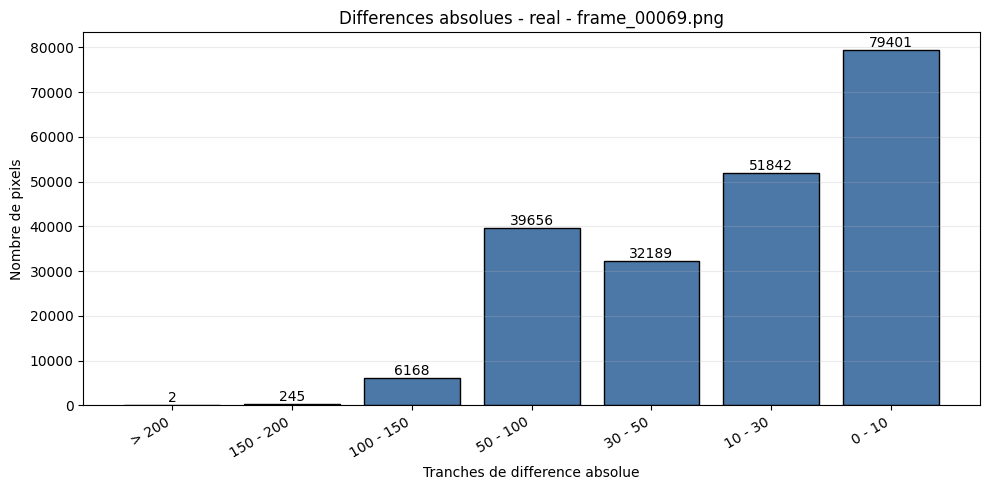

lvl:  4  initial error:  3207.3317490494296
 error improvement too small, level converged! it:  6  error:  1250.2049503654146  lambda:  0.1
lvl:  3  initial error:  1413.827122440702
 error improvement too small, level converged! it:  9  error:  1233.2201005568893  lambda:  0.0
lvl:  2  initial error:  1391.6300998823401
 error improvement too small, level converged! it:  9  error:  1334.7606770038578  lambda:  0.0
[real] frame 70 -> frame_00070.png | sum error = 352048864.00 | mean abs error = 27.3790 | valid pixels = 219293


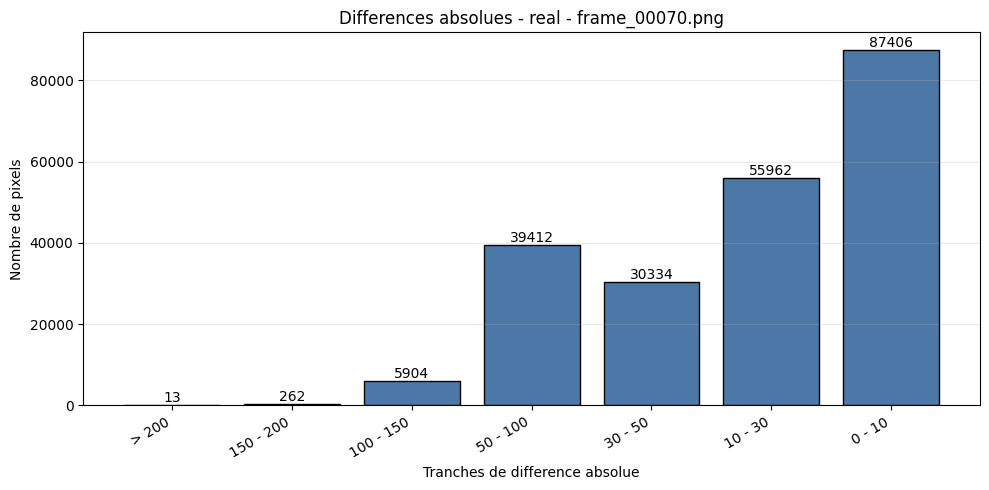

lvl:  4  initial error:  3222.649239543726
 error improvement too small, level converged! it:  5  error:  994.9186033064605  lambda:  0.1
lvl:  3  initial error:  1225.5183487193378
 error improvement too small, level converged! it:  6  error:  1161.105008141676  lambda:  0.0
lvl:  2  initial error:  1248.5925718449487
 error improvement too small, level converged! it:  12  error:  1190.9401983680125  lambda:  3.2
[real] frame 71 -> frame_00071.png | sum error = 345127456.00 | mean abs error = 25.1862 | valid pixels = 238602


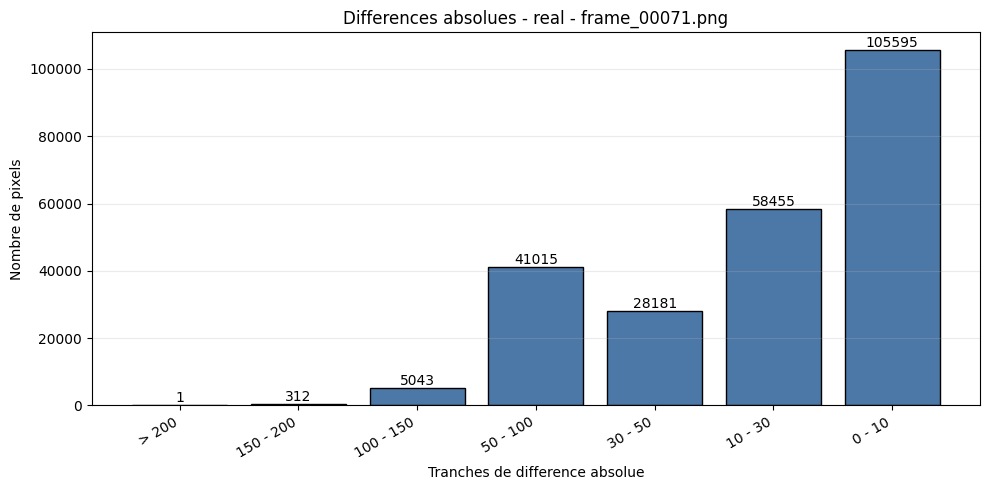

lvl:  4  initial error:  2930.000950570342
 error improvement too small, level converged! it:  4  error:  1039.2220998064104  lambda:  0.0
lvl:  3  initial error:  1191.8962642906467
 error improvement too small, level converged! it:  4  error:  1056.4325903517138  lambda:  0.4
lvl:  2  initial error:  1150.18771855356
 error improvement too small, level converged! it:  8  error:  1127.4410049210467  lambda:  3.2
[real] frame 72 -> frame_00072.png | sum error = 342570976.00 | mean abs error = 24.0096 | valid pixels = 250355


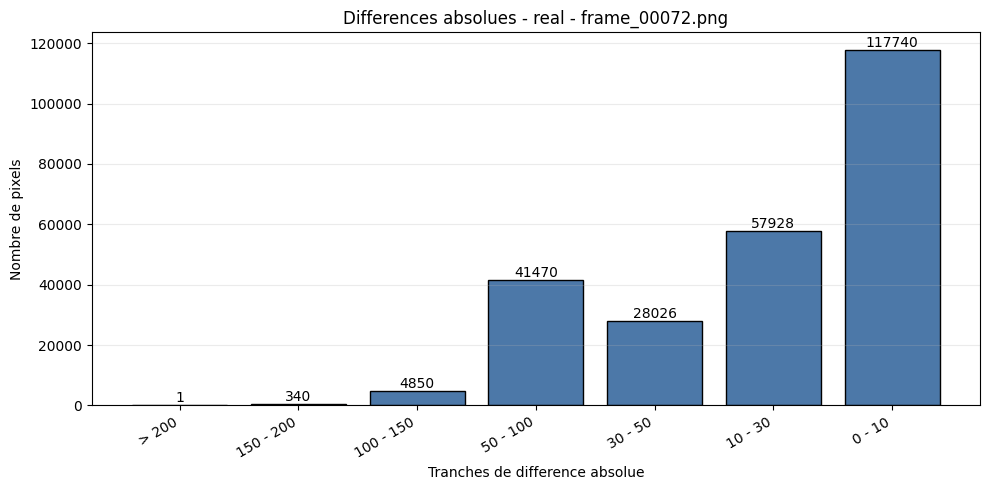

lvl:  4  initial error:  2524.5408745247146
 error improvement too small, level converged! it:  15  error:  774.4995903015332  lambda:  0.0
lvl:  3  initial error:  863.1950162288744
update too small, level converged! it:  5  error:  738.0000481150447  lambda:  56294995342131.2
lvl:  2  initial error:  875.051442011767
 error improvement too small, level converged! it:  11  error:  821.3512244590213  lambda:  0.0
[real] frame 73 -> frame_00073.png | sum error = 300036128.00 | mean abs error = 19.1550 | valid pixels = 277266


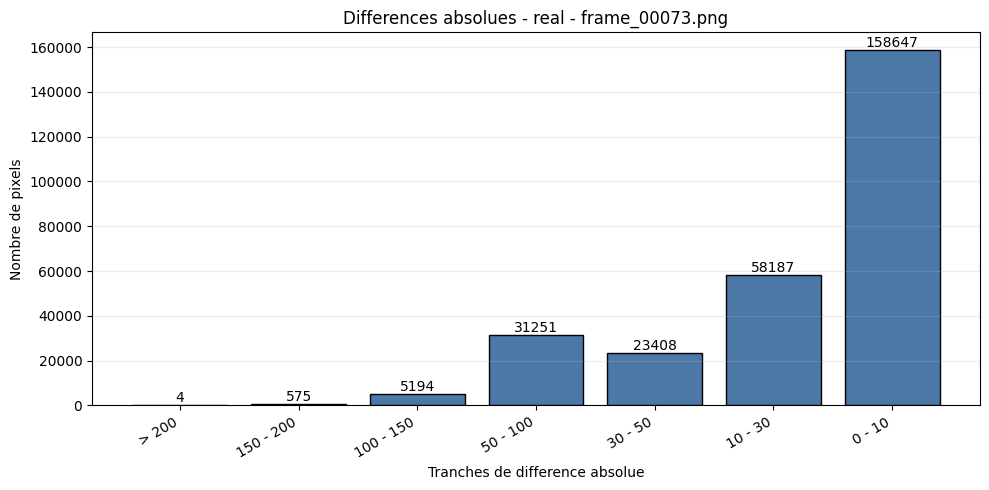

lvl:  4  initial error:  2025.3051330798476
update too small, level converged! it:  6  error:  683.1309815742364  lambda:  450359962737049.6
lvl:  3  initial error:  808.1557379319515
 error improvement too small, level converged! it:  5  error:  566.2989088891368  lambda:  439804651110.4
lvl:  2  initial error:  651.5313316583205
 error improvement too small, level converged! it:  4  error:  633.1140188890049  lambda:  0.0
[real] frame 74 -> frame_00074.png | sum error = 243475376.00 | mean abs error = 15.6887 | valid pixels = 289481


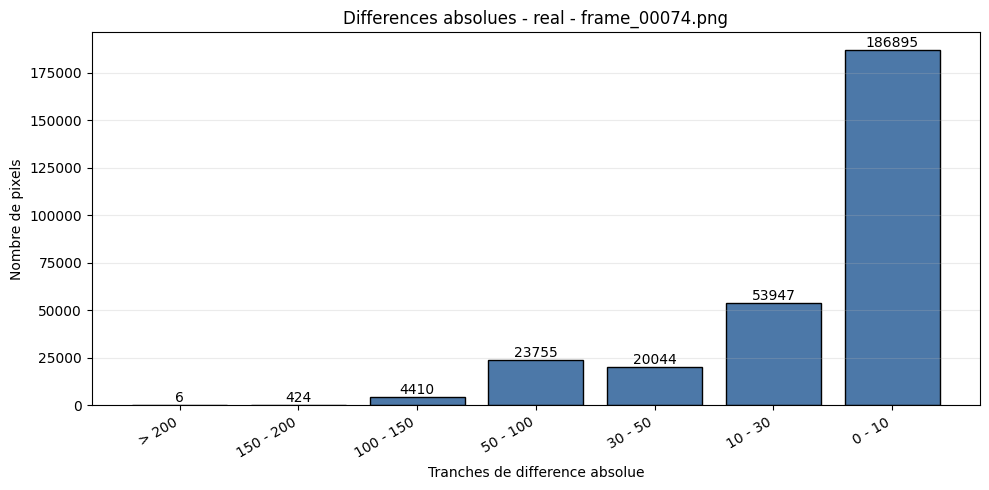

lvl:  4  initial error:  1916.5684410646384
update too small, level converged! it:  4  error:  551.3461712296307  lambda:  450359962737049.6
lvl:  3  initial error:  558.7457279715574
update too small, level converged! it:  4  error:  408.7311393851207  lambda:  450359962737049.6
lvl:  2  initial error:  409.82602073199826
 error improvement too small, level converged! it:  3  error:  395.69419974285995  lambda:  1.6
[real] frame 75 -> frame_00075.png | sum error = 162849760.00 | mean abs error = 11.8079 | valid pixels = 286650


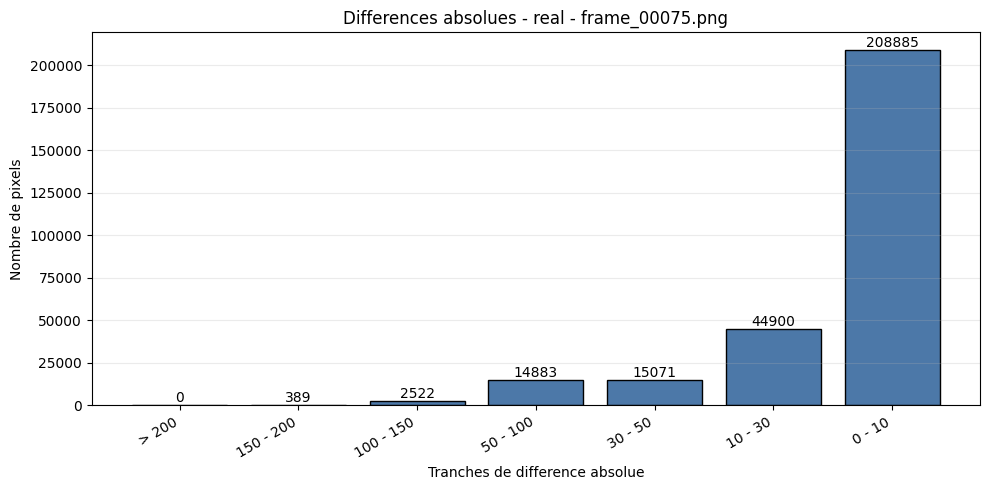

lvl:  4  initial error:  2156.4724334600755
 error improvement too small, level converged! it:  4  error:  566.1786146757406  lambda:  3.2
lvl:  3  initial error:  558.6543910669297
update too small, level converged! it:  4  error:  463.9403149486244  lambda:  112589990684262.4
lvl:  2  initial error:  472.76067970088786
 error improvement too small, level converged! it:  2  error:  468.5062908757492  lambda:  6.4
[real] frame 76 -> frame_00076.png | sum error = 180784720.00 | mean abs error = 12.9707 | valid pixels = 279492


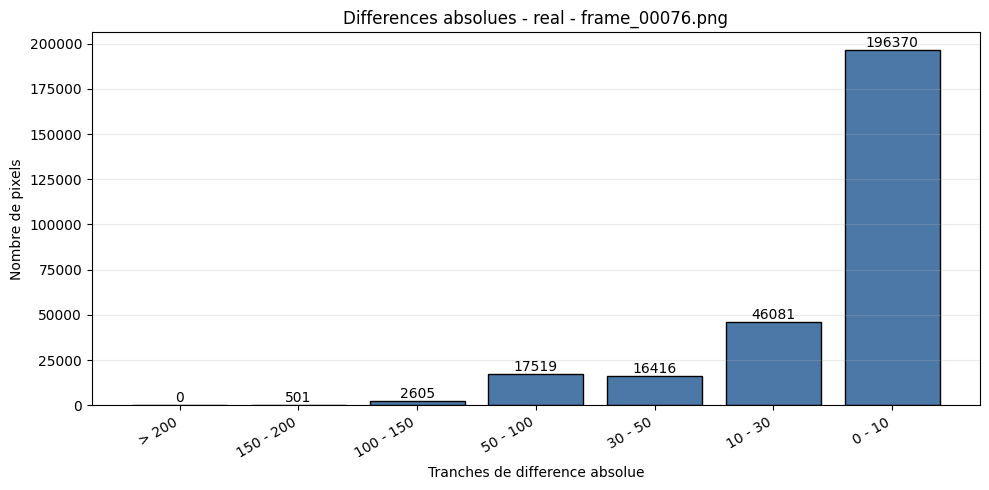

lvl:  4  initial error:  2397.389733840304
update too small, level converged! it:  4  error:  653.7235076325356  lambda:  900719925474099.2
lvl:  3  initial error:  662.5034773804127
 error improvement too small, level converged! it:  5  error:  542.4508615227649  lambda:  0.0
lvl:  2  initial error:  580.2815632544192
 error improvement too small, level converged! it:  7  error:  535.5663603614154  lambda:  0.0
[real] frame 77 -> frame_00077.png | sum error = 197842368.00 | mean abs error = 14.0773 | valid pixels = 273880


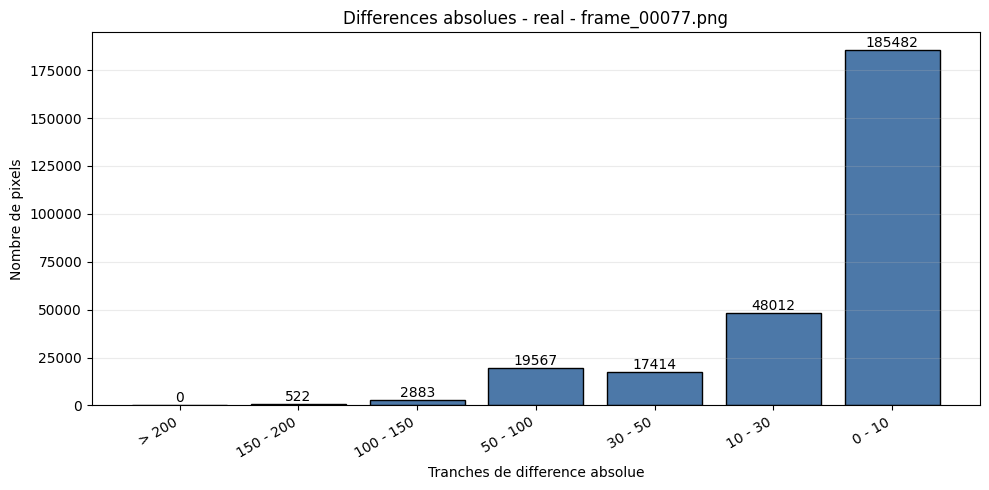

lvl:  4  initial error:  2645.509505703422
 error improvement too small, level converged! it:  4  error:  728.8939470054449  lambda:  12.8
lvl:  3  initial error:  812.0782415270322
 error improvement too small, level converged! it:  9  error:  631.9540603923036  lambda:  0.0
lvl:  2  initial error:  709.0477418889926
 error improvement too small, level converged! it:  6  error:  666.9305711988036  lambda:  0.0
[real] frame 78 -> frame_00078.png | sum error = 231108512.00 | mean abs error = 15.7694 | valid pixels = 268010


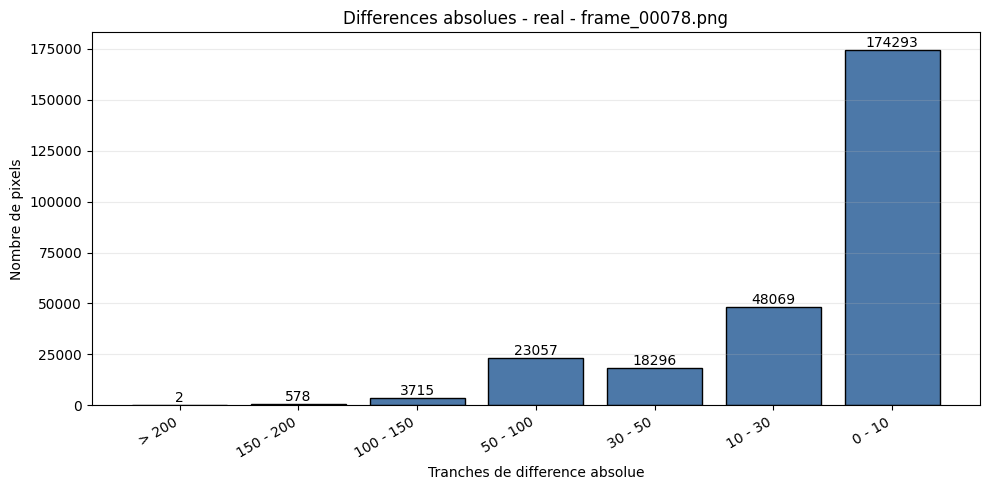

lvl:  4  initial error:  2606.5532319391627
 error improvement too small, level converged! it:  5  error:  757.9649552721733  lambda:  0.4
lvl:  3  initial error:  866.3594843844637
 error improvement too small, level converged! it:  11  error:  635.9488179876221  lambda:  0.0
lvl:  2  initial error:  711.8369544646498
 error improvement too small, level converged! it:  4  error:  689.7289124939447  lambda:  0.0
[real] frame 79 -> frame_00079.png | sum error = 234110960.00 | mean abs error = 16.0116 | valid pixels = 266801


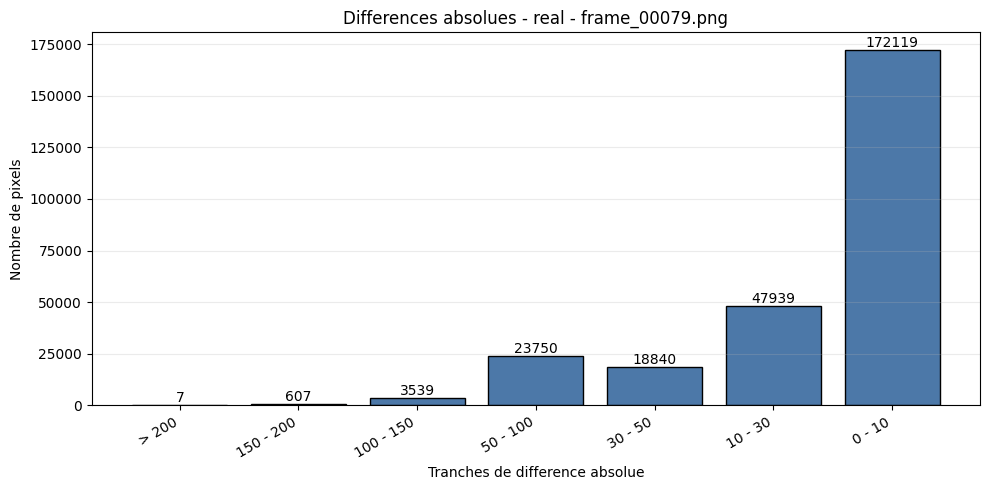

lvl:  4  initial error:  2598.054182509505
 error improvement too small, level converged! it:  3  error:  779.5702327643645  lambda:  56294995342131.2
lvl:  3  initial error:  846.2500892280678
 error improvement too small, level converged! it:  8  error:  666.5759847782556  lambda:  0.0
lvl:  2  initial error:  720.2419688931741
 error improvement too small, level converged! it:  10  error:  655.1503578698955  lambda:  0.0
[real] frame 80 -> frame_00080.png | sum error = 227305248.00 | mean abs error = 15.4453 | valid pixels = 268817


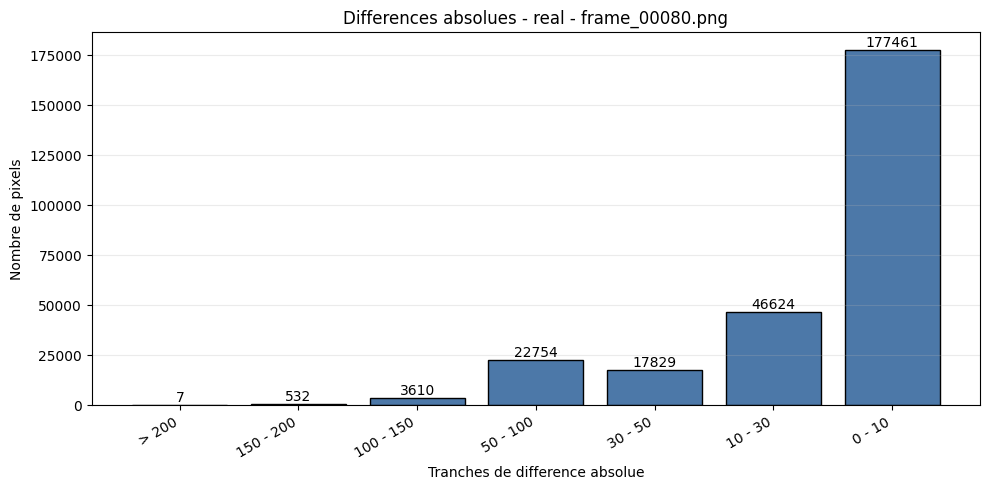

lvl:  4  initial error:  2568.4201520912543
 error improvement too small, level converged! it:  5  error:  700.1740363871966  lambda:  0.4
lvl:  3  initial error:  771.4778778868408
 error improvement too small, level converged! it:  3  error:  629.0076598161567  lambda:  0.0
lvl:  2  initial error:  636.4732642158892
 error improvement too small, level converged! it:  4  error:  612.6276836709789  lambda:  0.0
[real] frame 81 -> frame_00081.png | sum error = 214114464.00 | mean abs error = 14.9524 | valid pixels = 269677


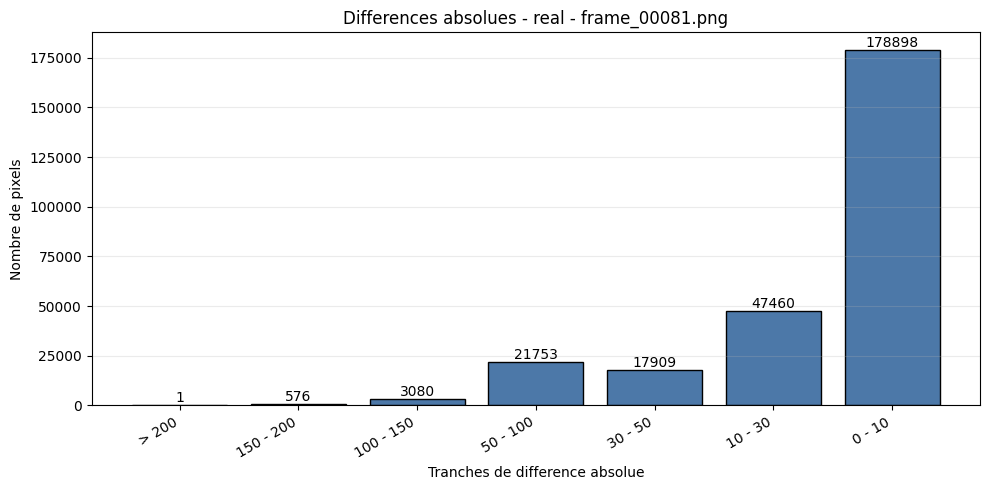

lvl:  4  initial error:  2340.815589353612
 error improvement too small, level converged! it:  5  error:  545.6465357529593  lambda:  0.8
lvl:  3  initial error:  473.31362574313454
 error improvement too small, level converged! it:  6  error:  406.97660375865524  lambda:  3.2
lvl:  2  initial error:  440.97771434356775
 error improvement too small, level converged! it:  3  error:  430.6167013924694  lambda:  6.4
[real] frame 82 -> frame_00082.png | sum error = 171946176.00 | mean abs error = 12.7708 | valid pixels = 276187


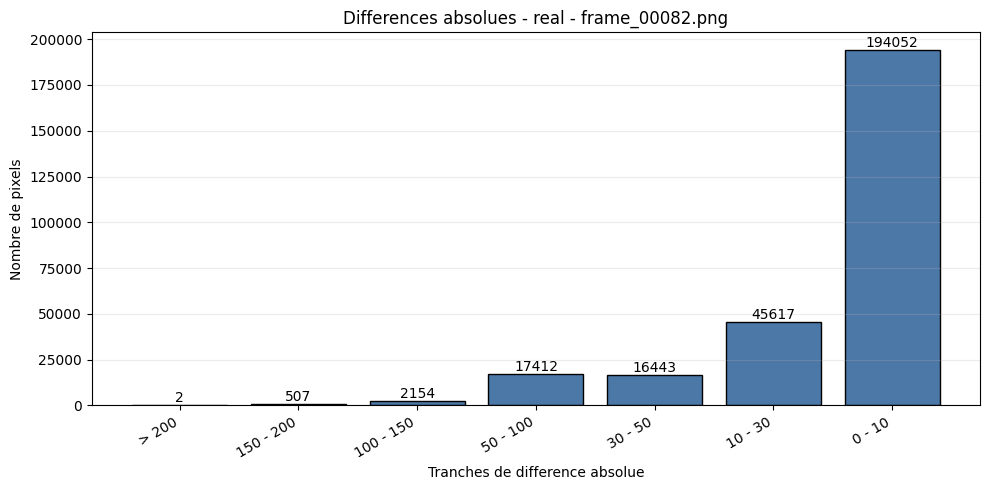

lvl:  4  initial error:  2247.4572243345997
 error improvement too small, level converged! it:  6  error:  474.48682521722094  lambda:  0.8
lvl:  3  initial error:  367.77583472105584
 error improvement too small, level converged! it:  2  error:  348.0042828267125  lambda:  0.4
lvl:  2  initial error:  362.0279573894674
 error improvement too small, level converged! it:  4  error:  345.8764506951044  lambda:  219902325555.2
[real] frame 83 -> frame_00083.png | sum error = 147120816.00 | mean abs error = 11.4055 | valid pixels = 280253


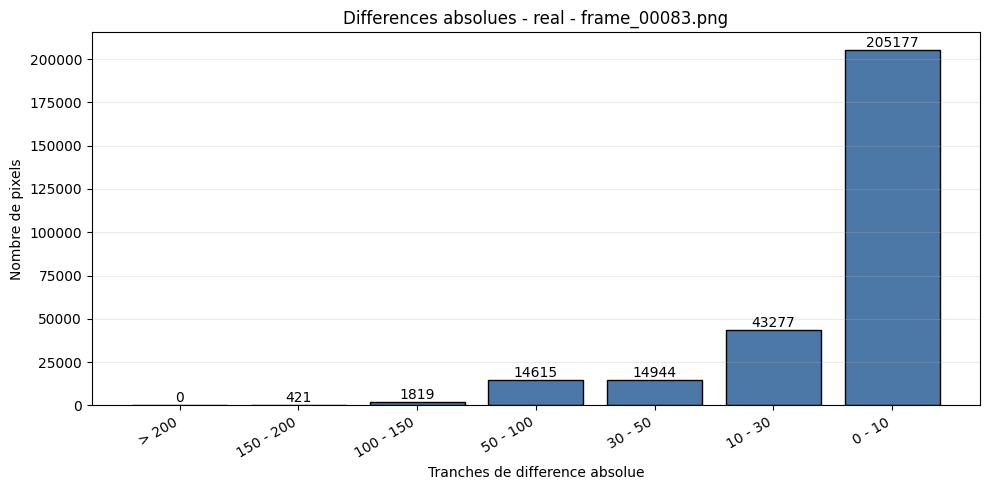

lvl:  4  initial error:  2038.268060836501
 error improvement too small, level converged! it:  5  error:  593.249218563588  lambda:  7036874417766.4
lvl:  3  initial error:  569.1781638183676
 error improvement too small, level converged! it:  4  error:  534.7578019788135  lambda:  0.0
lvl:  2  initial error:  543.9770207629983
 error improvement too small, level converged! it:  4  error:  532.4110072598363  lambda:  0.0
[real] frame 84 -> frame_00084.png | sum error = 210194080.00 | mean abs error = 14.6008 | valid pixels = 282638


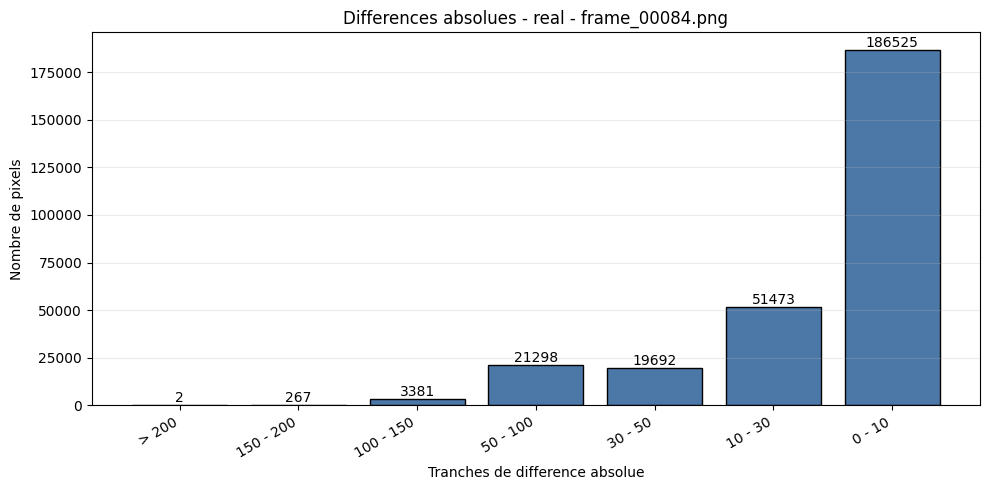

lvl:  4  initial error:  2469.8678707224335
 error improvement too small, level converged! it:  3  error:  703.8970363786075  lambda:  0.0
lvl:  3  initial error:  842.2996874155093
 error improvement too small, level converged! it:  3  error:  709.2068108761273  lambda:  12.8
lvl:  2  initial error:  759.5674853872326
 error improvement too small, level converged! it:  4  error:  745.0734566009727  lambda:  0.0
[real] frame 85 -> frame_00085.png | sum error = 270228576.00 | mean abs error = 18.1772 | valid pixels = 272745


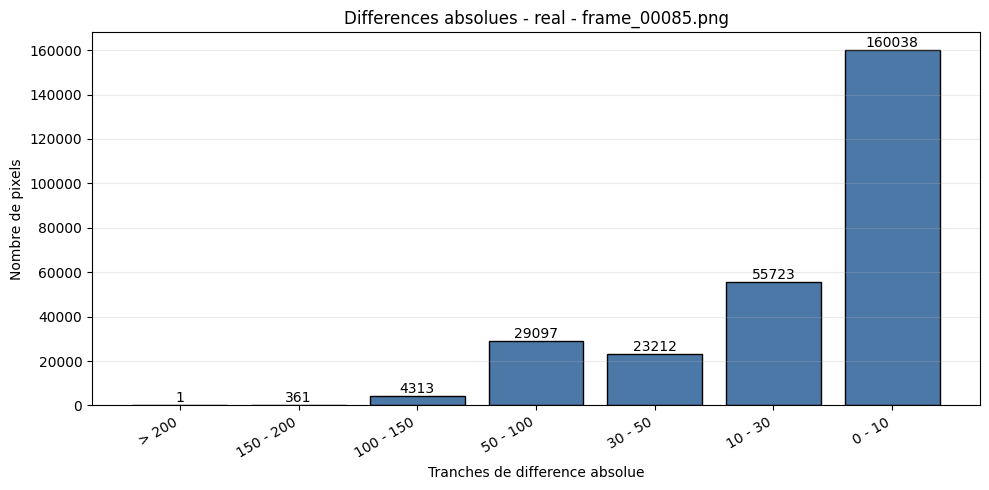

lvl:  4  initial error:  3023.2091254752845
 error improvement too small, level converged! it:  9  error:  1168.1386256835917  lambda:  1.6
lvl:  3  initial error:  1165.8949819598806
 error improvement too small, level converged! it:  6  error:  1100.6528711260028  lambda:  0.1
lvl:  2  initial error:  1158.6578517947205
 error improvement too small, level converged! it:  7  error:  1127.1402731252074  lambda:  0.0
[real] frame 86 -> frame_00086.png | sum error = 333267232.00 | mean abs error = 24.0857 | valid pixels = 248128


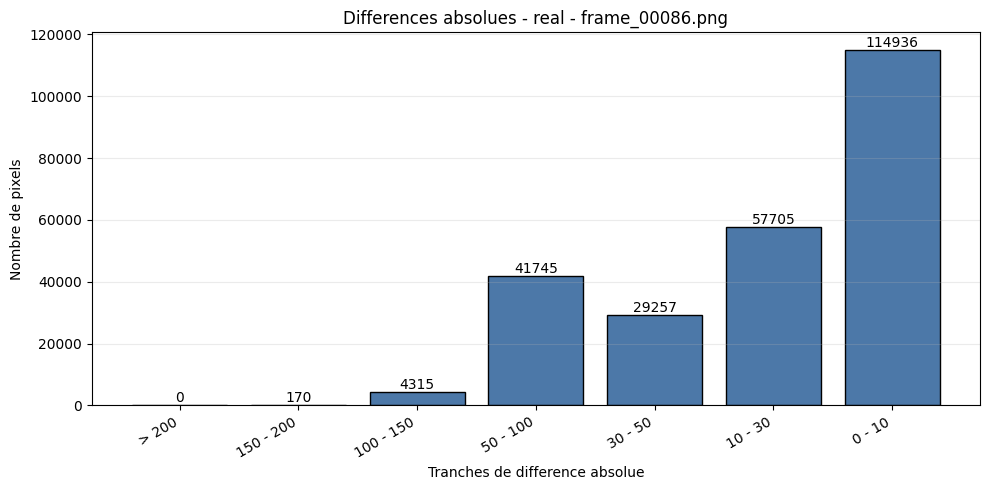

lvl:  4  initial error:  3132.2519011406844
 error improvement too small, level converged! it:  8  error:  1344.0364655570288  lambda:  0.4
lvl:  3  initial error:  1470.3170465862206
 error improvement too small, level converged! it:  12  error:  1203.132709716611  lambda:  0.0
lvl:  2  initial error:  1323.5098712061301
 error improvement too small, level converged! it:  6  error:  1302.2728078777234  lambda:  0.0
[real] frame 87 -> frame_00087.png | sum error = 370048768.00 | mean abs error = 26.7236 | valid pixels = 238953


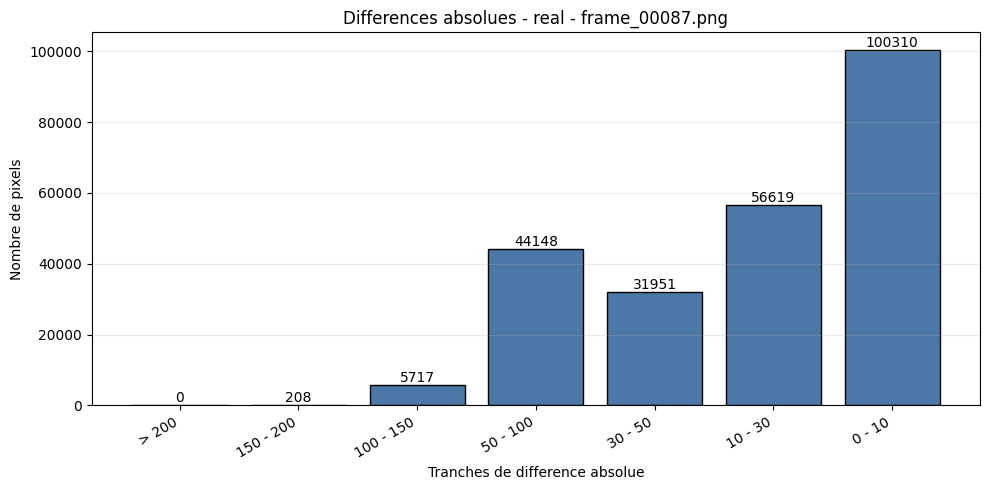

lvl:  4  initial error:  3177.6416349809883
update too small, level converged! it:  11  error:  1408.3215848761238  lambda:  225179981368524.8
lvl:  3  initial error:  1363.1986445516309
 error improvement too small, level converged! it:  8  error:  1254.9563818054053  lambda:  0.0
lvl:  2  initial error:  1423.1986953279986
 error improvement too small, level converged! it:  11  error:  1361.834118177978  lambda:  0.0
[real] frame 88 -> frame_00088.png | sum error = 365594880.00 | mean abs error = 27.7303 | valid pixels = 225608


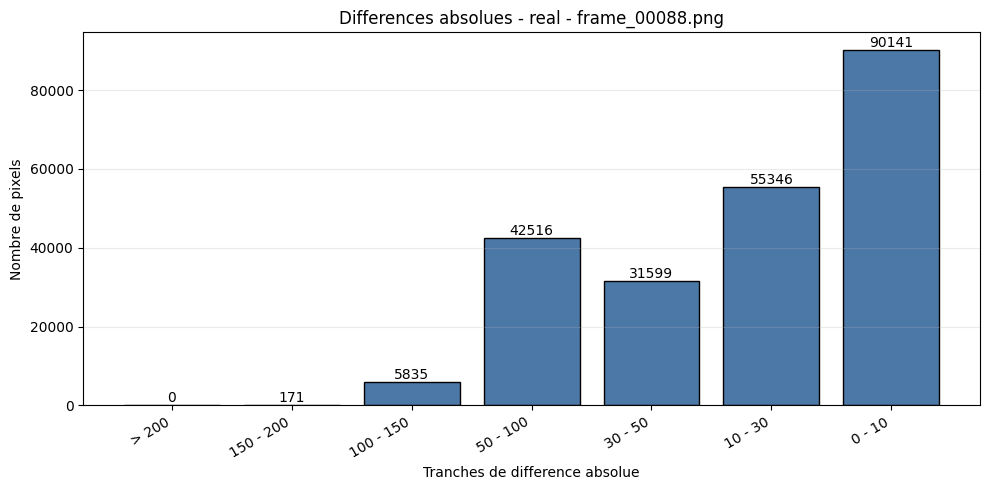

lvl:  4  initial error:  3128.154942965779
 error improvement too small, level converged! it:  7  error:  1836.4952472006573  lambda:  3.2
lvl:  3  initial error:  1906.4868913823375
 error improvement too small, level converged! it:  3  error:  1777.1053539255884  lambda:  0.2
lvl:  2  initial error:  1834.3683232493859
 error improvement too small, level converged! it:  1  error:  1834.2052224951929  lambda:  1.6
[real] frame 89 -> frame_00089.png | sum error = 454093120.00 | mean abs error = 31.0330 | valid pixels = 218971


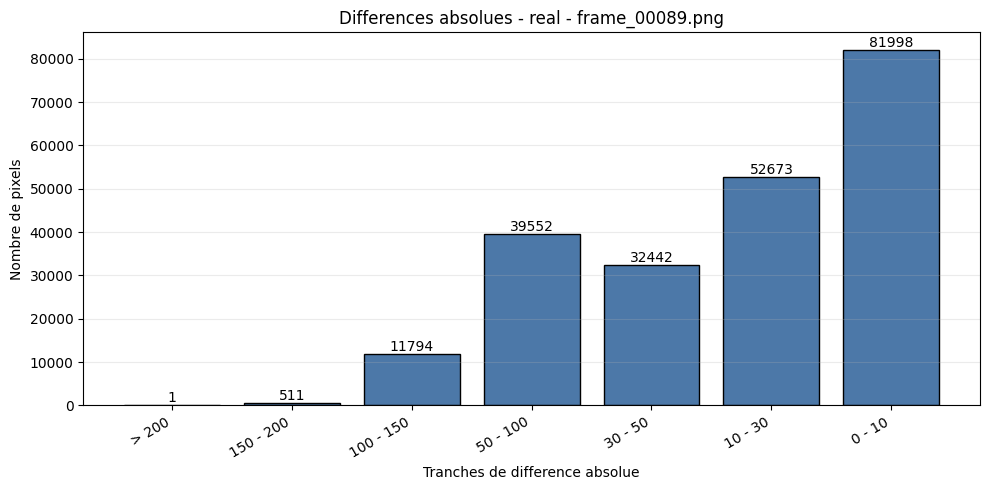

lvl:  4  initial error:  3084.5446768060833
 error improvement too small, level converged! it:  7  error:  1800.7535906801043  lambda:  0.0
lvl:  3  initial error:  2048.2071542441126
 error improvement too small, level converged! it:  4  error:  1919.1982764759935  lambda:  1.6
lvl:  2  initial error:  1905.4351111934425
 error improvement too small, level converged! it:  1  error:  1905.138167024679  lambda:  0.0
[real] frame 90 -> frame_00090.png | sum error = 455951008.00 | mean abs error = 31.7011 | valid pixels = 212052


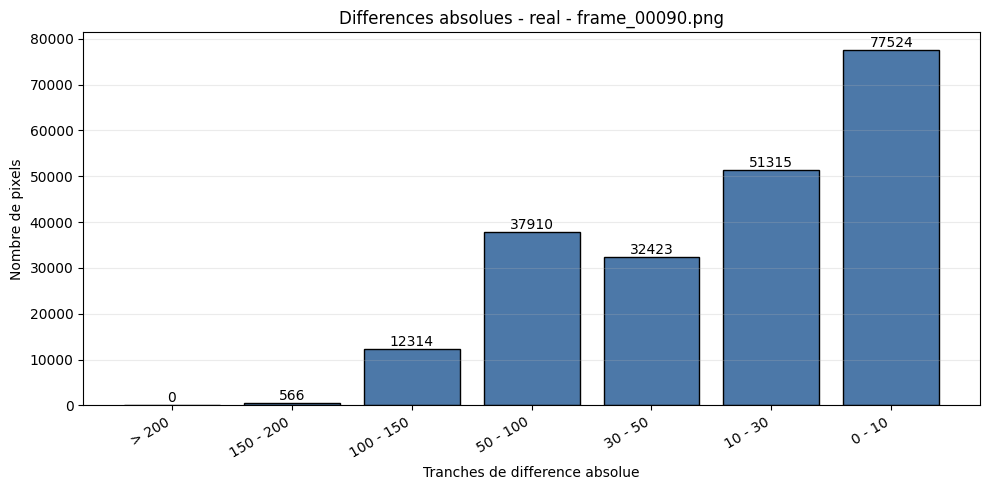

lvl:  4  initial error:  3389.734790874524
 error improvement too small, level converged! it:  10  error:  1907.3480190774067  lambda:  0.0
lvl:  3  initial error:  1879.172711584536
 error improvement too small, level converged! it:  8  error:  1817.1853652394911  lambda:  0.0
lvl:  2  initial error:  1977.8339943804776
 error improvement too small, level converged! it:  6  error:  1947.0038468800549  lambda:  0.0
[real] frame 91 -> frame_00091.png | sum error = 474023360.00 | mean abs error = 30.9671 | valid pixels = 214896


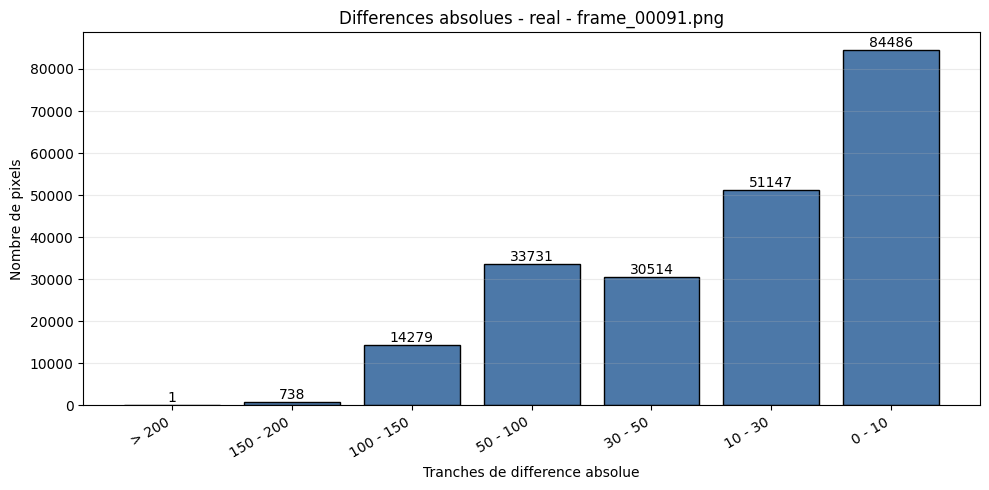

lvl:  4  initial error:  3457.1939163498096
 error improvement too small, level converged! it:  4  error:  1970.134442817623  lambda:  0.0
lvl:  3  initial error:  1956.8101675040202
 error improvement too small, level converged! it:  12  error:  1889.1439599826042  lambda:  0.0
lvl:  2  initial error:  1962.589617668091
 error improvement too small, level converged! it:  2  error:  1958.9858874425292  lambda:  0.0
[real] frame 92 -> frame_00092.png | sum error = 476324096.00 | mean abs error = 31.1577 | valid pixels = 213925


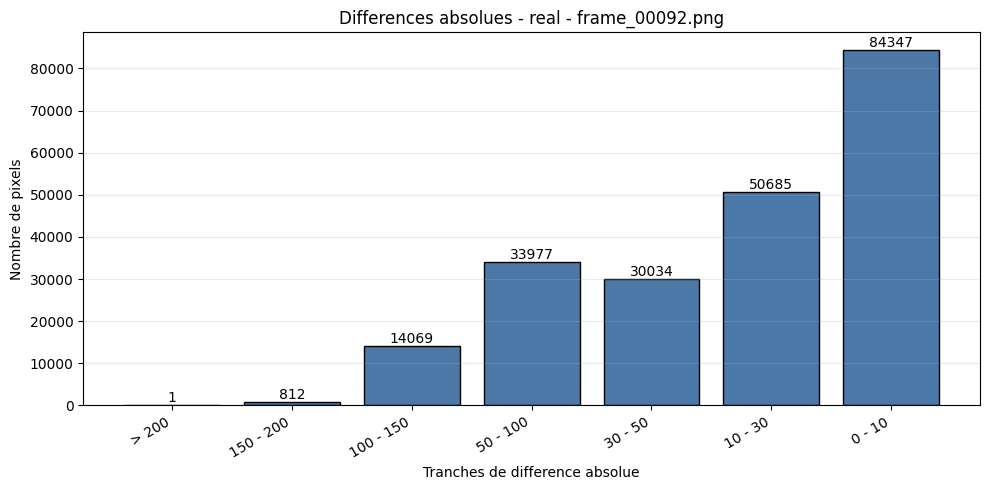

lvl:  4  initial error:  3522.8621673003804
 error improvement too small, level converged! it:  6  error:  1954.7627299603369  lambda:  0.2
lvl:  3  initial error:  1943.0301590757858
 error improvement too small, level converged! it:  7  error:  1838.1524553264064  lambda:  0.0
lvl:  2  initial error:  1998.5351272755695
 error improvement too small, level converged! it:  1  error:  1998.0099661312447  lambda:  0.0
[real] frame 93 -> frame_00093.png | sum error = 486174944.00 | mean abs error = 31.3125 | valid pixels = 212997


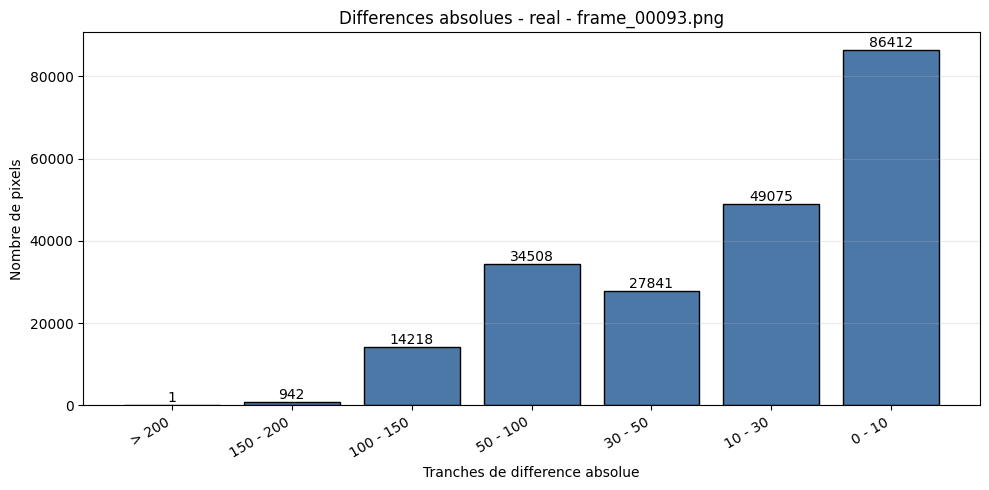

lvl:  4  initial error:  3492.4182509505704
update too small, level converged! it:  3  error:  1902.8396456004418  lambda:  450359962737049.6
lvl:  3  initial error:  1880.5208654331482
update too small, level converged! it:  2  error:  1846.9810352807906  lambda:  225179981368524.8
lvl:  2  initial error:  1961.975059870251
 error improvement too small, level converged! it:  1  error:  1960.5552399994963  lambda:  0.0
[real] frame 94 -> frame_00094.png | sum error = 473906624.00 | mean abs error = 30.8675 | valid pixels = 212567


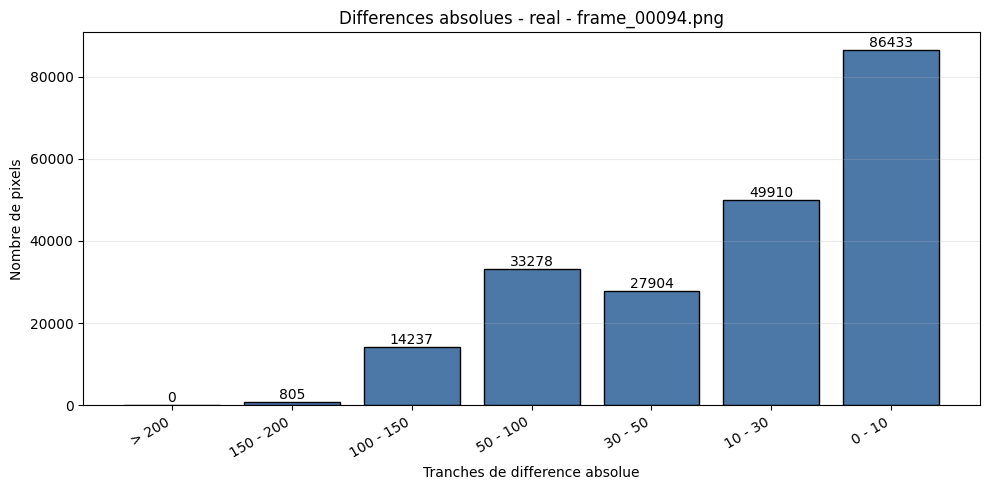

lvl:  4  initial error:  3524.3479087452465
 error improvement too small, level converged! it:  2  error:  1877.4647549559686  lambda:  0.1
lvl:  3  initial error:  1923.564018965702
 error improvement too small, level converged! it:  4  error:  1808.1815835416821  lambda:  0.0
lvl:  2  initial error:  1948.7228255370053
 error improvement too small, level converged! it:  2  error:  1939.1224297703914  lambda:  0.0
[real] frame 95 -> frame_00095.png | sum error = 469971776.00 | mean abs error = 30.9269 | valid pixels = 212977


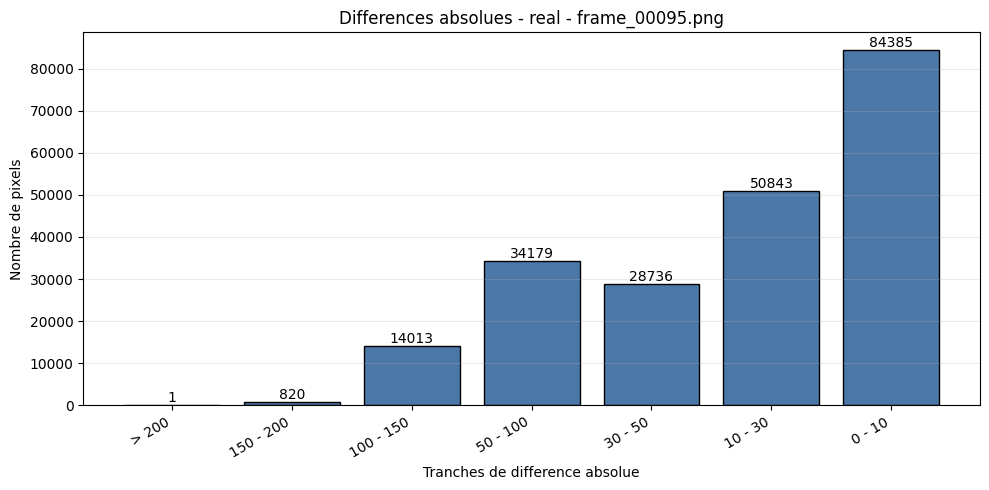

lvl:  4  initial error:  3478.8498098859313
 error improvement too small, level converged! it:  5  error:  1830.7876540476336  lambda:  0.4
lvl:  3  initial error:  1866.2670580605406
 error improvement too small, level converged! it:  4  error:  1836.7917100929246  lambda:  6.4
lvl:  2  initial error:  1927.6640792183389
 error improvement too small, level converged! it:  1  error:  1927.0527225410613  lambda:  0.0
[real] frame 96 -> frame_00096.png | sum error = 473058400.00 | mean abs error = 31.8321 | valid pixels = 214824


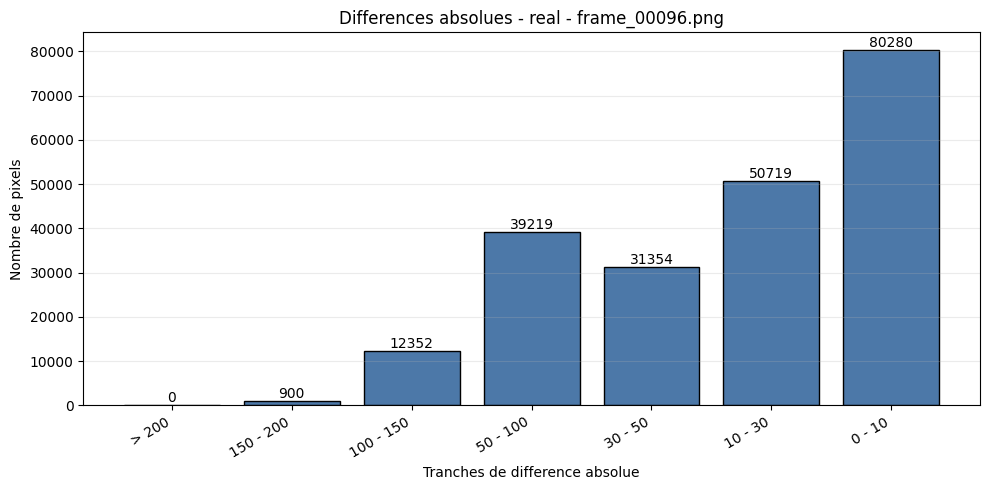

lvl:  4  initial error:  3303.4553231939162
update too small, level converged! it:  5  error:  1678.4338841655815  lambda:  900719925474099.2
lvl:  3  initial error:  1942.3038306464655
 error improvement too small, level converged! it:  14  error:  1653.2789365006815  lambda:  0.0
lvl:  2  initial error:  1752.2917701687584
 error improvement too small, level converged! it:  13  error:  1681.5283131450085  lambda:  0.0
[real] frame 97 -> frame_00097.png | sum error = 415165600.00 | mean abs error = 31.3119 | valid pixels = 211692


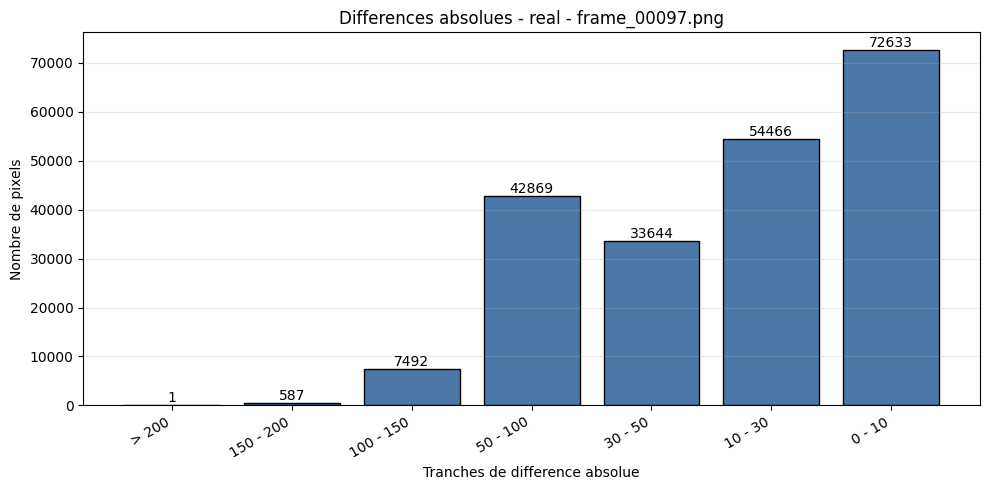

lvl:  4  initial error:  3034.630228136882
 error improvement too small, level converged! it:  9  error:  1299.933860619115  lambda:  0.0
lvl:  3  initial error:  1557.0850170697838
 error improvement too small, level converged! it:  12  error:  1367.911559473533  lambda:  0.0
lvl:  2  initial error:  1524.828958278369
 error improvement too small, level converged! it:  9  error:  1477.5095413746828  lambda:  0.0
[real] frame 98 -> frame_00098.png | sum error = 407416096.00 | mean abs error = 28.6872 | valid pixels = 231266


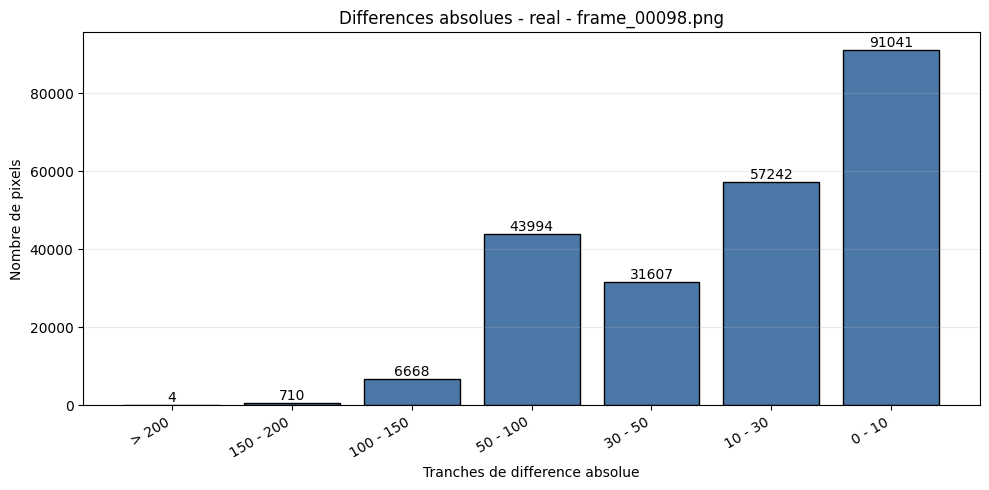

lvl:  4  initial error:  3169.984790874524
 error improvement too small, level converged! it:  6  error:  1150.8870787523842  lambda:  0.0
lvl:  3  initial error:  1307.6071496007344
 error improvement too small, level converged! it:  9  error:  1242.453171073793  lambda:  1.6
lvl:  2  initial error:  1407.0269851566943
 error improvement too small, level converged! it:  10  error:  1370.5323815490576  lambda:  0.0
[real] frame 99 -> frame_00099.png | sum error = 402449952.00 | mean abs error = 27.2917 | valid pixels = 244396


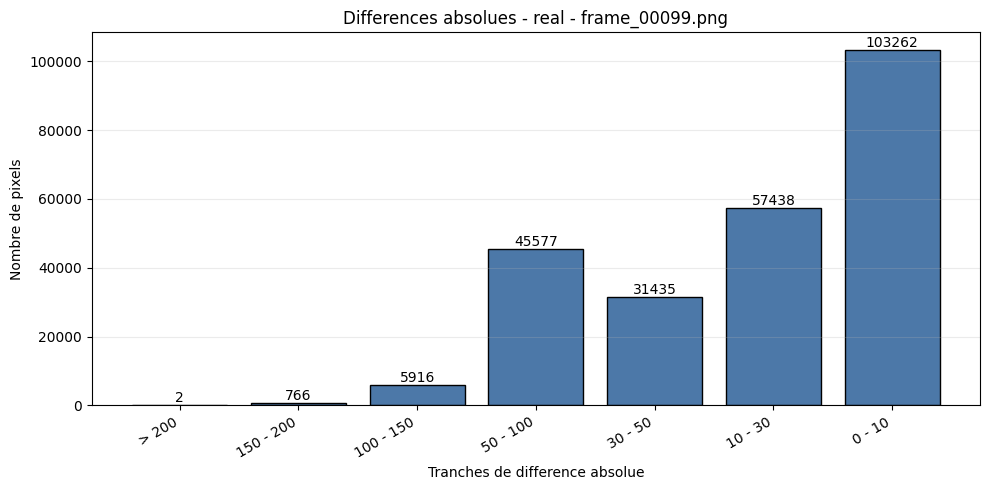

lvl:  4  initial error:  2302.9458174904944
 error improvement too small, level converged! it:  14  error:  845.283297530013  lambda:  204.8
lvl:  3  initial error:  1033.2782976905225
 error improvement too small, level converged! it:  5  error:  981.073697713492  lambda:  0.0
lvl:  2  initial error:  1071.606087386829
 error improvement too small, level converged! it:  11  error:  1018.8789552979799  lambda:  0.0
[real] frame 100 -> frame_00100.png | sum error = 347686752.00 | mean abs error = 22.2435 | valid pixels = 272420


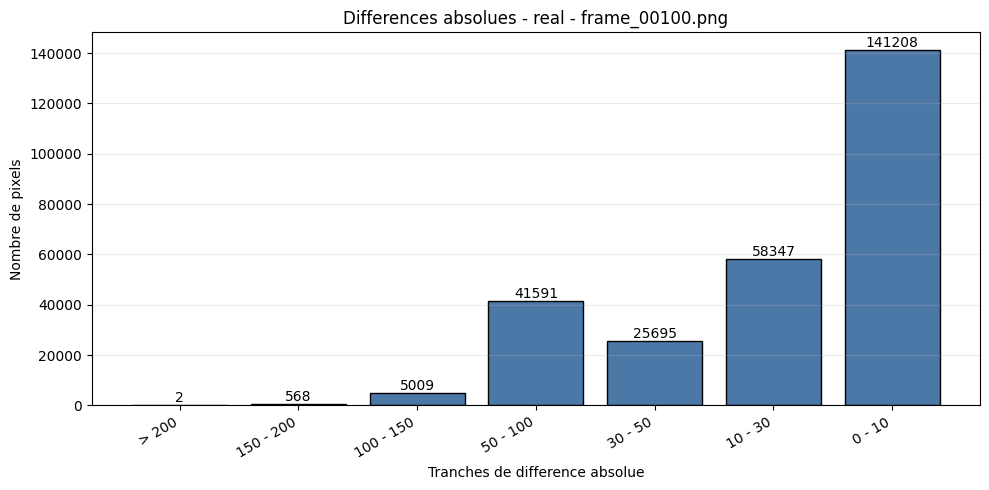

In [66]:
# Boucle simple sur toute la sequence: deth estimation puis pose estimation par frame.
# Cette version reconstruit une camera coherente pour la sequence traitee
# et reinitialise le solveur pour eviter de reutiliser un etat precedent.
frame_paths = real_frame_paths[0:120]  # Remplace par fake_frame_paths[:10] si tu veux traiter la sequence fake.

if len(frame_paths) < 2:
    raise ValueError("Il faut au moins 2 frames pour lancer le pipeline.")

sequence_name = "real"
sequence_keyframe = None
sequence_results = []

first_image_path = normalize_image_path(frame_paths[0])
first_image = load_gray_image(first_image_path)
sequence_height, sequence_width = first_image.shape[:2]

sequence_cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    sequence_width,
    sequence_height,
)
sequence_pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(sequence_cam, show_debug=False)

print(f"Sequence {sequence_name}:")
print(f"  source size = {sequence_width} x {sequence_height}")
print(f"  working size level-0 = {sequence_cam.width[0]} x {sequence_cam.height[0]}")
print(f"  fx level-0 = {sequence_cam.fx[0]}")
print(f"  fy level-0 = {sequence_cam.fy[0]}")
print()

for step, image_path in enumerate(frame_paths):
    image_path = normalize_image_path(image_path)
    image = load_gray_image(image_path)

    if image.shape[:2] != (sequence_height, sequence_width):
        raise ValueError(
            f"Toutes les images de la sequence {sequence_name} doivent avoir la meme taille. "
            f"Attendu: {(sequence_height, sequence_width)}, obtenu: {image.shape[:2]} pour {image_path.name}"
        )

    depth_map = load_depth_map(image_path)
    inv_depth, inv_depth_var, depth_valid_mask = depth_to_invdepth(depth_map)

    current_frame = frameData.frameData()
    current_frame.setImage(image)
    current_frame.setInvDepth(inv_depth, inv_depth_var)

    if step == 0:
        sequence_keyframe = current_frame
        print(f"[{sequence_name}] frame {step} -> keyframe de reference: {image_path.name}")
        sequence_results.append({
            "index": step,
            "image_path": str(image_path),
            "depth_valid_ratio": float(depth_valid_mask.mean()),
            "pose_matrix": current_frame.pose.as_matrix(),
            "photometric_error": None,
            "photometric_error_mean": None,
            "valid_pixel_count": None,
            "histogram_counts": None,

        })
        continue

    sequence_pose_solver.optPose(current_frame, sequence_keyframe)
    evaluation = compute_photometric_error(current_frame, sequence_keyframe, sequence_cam, lvl=0)

    abs_error_map = np.sqrt(evaluation["squared_error_map"])
    valid_mask = evaluation["valid_mask"]
    valid_abs_errors = abs_error_map[valid_mask]
    valid_pixel_count = int(valid_abs_errors.size)
    photometric_error = float(evaluation["photometric_error"])
    photometric_error_mean = float(valid_abs_errors.mean()) if valid_pixel_count > 0 else None
    mean_error_display = f"{photometric_error_mean:.4f}" if photometric_error_mean is not None else "None"

    print(
        f"[{sequence_name}] frame {step} -> {image_path.name} | "
        f"sum error = {photometric_error:.2f} | "
        f"mean abs error = {mean_error_display} | "
        f"valid pixels = {valid_pixel_count}"
    )

    num_gt_200 = int(np.sum(valid_abs_errors > 200))
    num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
    num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
    num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))
    num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))
    num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))
    num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

    range_labels = [
        "> 200",
        "150 - 200",
        "100 - 150",
        "50 - 100",
        "30 - 50",
        "10 - 30",
        "0 - 10",
    ]

    range_counts = [
        num_gt_200,
        num_150_200,
        num_100_150,
        num_50_100,
        num_30_50,
        num_10_30,
        num_0_10,
    ]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
    plt.title(f"Differences absolues - {sequence_name} - {image_path.name}")
    plt.xlabel("Tranches de difference absolue")
    plt.ylabel("Nombre de pixels")
    plt.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=30, ha="right")

    for bar, count in zip(bars, range_counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    sequence_results.append({
        "index": step,
        "image_path": str(image_path),
        "depth_valid_ratio": float(depth_valid_mask.mean()),
        "pose_matrix": current_frame.pose.as_matrix(),
        "photometric_error": photometric_error,
        "photometric_error_mean": photometric_error_mean,
        "valid_pixel_count": valid_pixel_count,
        "histogram_counts": range_counts,
    })


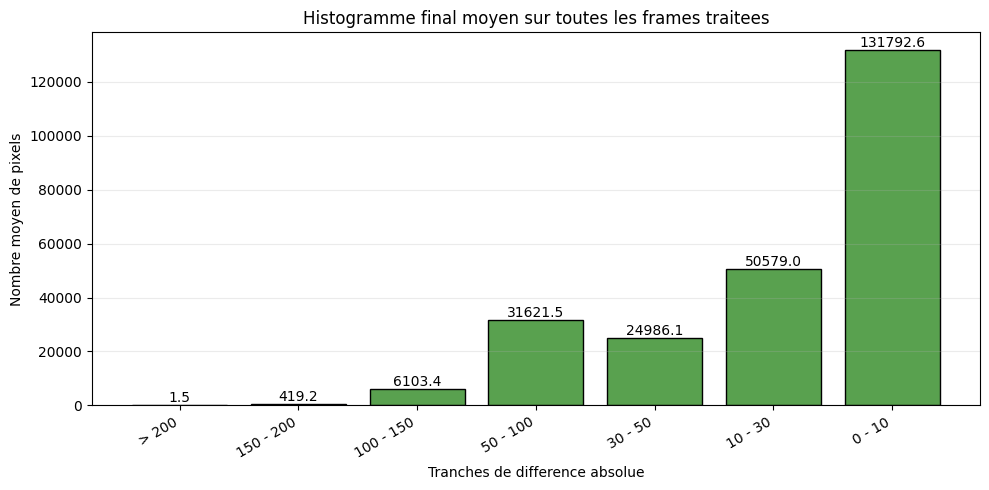

Histogramme final moyen:
     > 200 -> 1.52
  150 - 200 -> 419.16
  100 - 150 -> 6103.39
  50 - 100 -> 31621.55
   30 - 50 -> 24986.14
   10 - 30 -> 50579.03
    0 - 10 -> 131792.59


In [67]:
valid_histogram_results = [
    item for item in sequence_results
    if item.get("histogram_counts") is not None
]

if not valid_histogram_results:
    raise ValueError("Aucun histogramme valide disponible pour calculer la moyenne finale.")

histogram_matrix = np.array([item["histogram_counts"] for item in valid_histogram_results], dtype=np.float64)
mean_histogram_counts = histogram_matrix.mean(axis=0)

final_range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

plt.figure(figsize=(10, 5))
bars = plt.bar(final_range_labels, mean_histogram_counts, color="#59A14F", edgecolor="black")
plt.title("Histogramme final moyen sur toutes les frames traitees")
plt.xlabel("Tranches de difference absolue")
plt.ylabel("Nombre moyen de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, mean_histogram_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print("Histogramme final moyen:")
for label, value in zip(final_range_labels, mean_histogram_counts):
    print(f"  {label:>8} -> {value:.2f}")


315396906.16


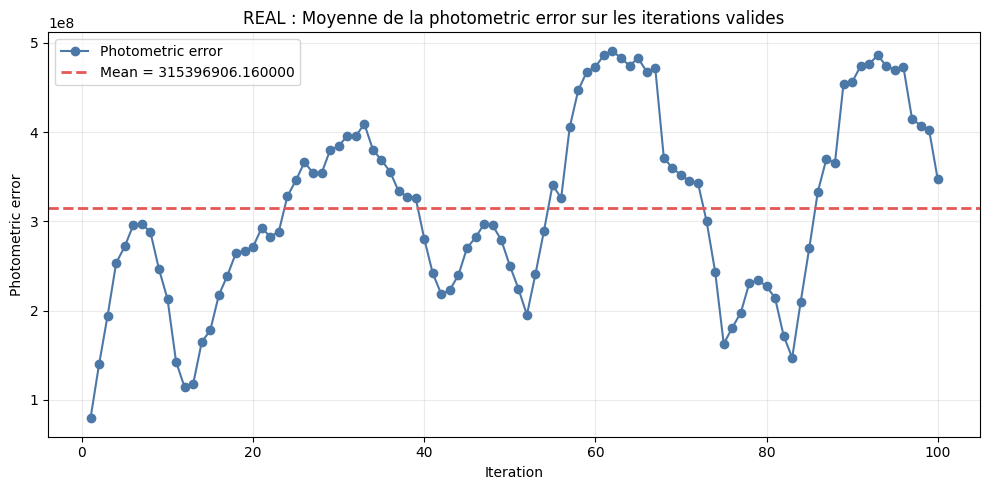

In [69]:
valid_results = [
    item for item in sequence_results
    if item["photometric_error"] is not None
]

if not valid_results:
    raise ValueError("Aucun résultat valide disponible pour calculer la moyenne des erreurs photométriques.")

iteration_indices = [item["index"] for item in valid_results]
photometric_errors = [item["photometric_error"] for item in valid_results]
mean_photometric_error = float(np.mean(photometric_errors))

print(mean_photometric_error)

plt.figure(figsize=(10, 5))
plt.plot(iteration_indices, photometric_errors, marker="o", color="#4C78A8", label="Photometric error")
plt.axhline(
    mean_photometric_error,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_photometric_error:.6f}"
)
plt.title("REAL : Moyenne de la photometric error sur les iterations valides")
plt.xlabel("Iteration")
plt.ylabel("Photometric error")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()